# NYC Yellow Taxi Trip Data Analysis

## Business Problem

The NYC Taxi & Limousine Commission collects trip records from yellow taxis operating across New York City.

This data can be used to understand transportation patterns, improve operational efficiency, optimize taxi allocation, predict future demand, estimate trip costs, detect abnormal trips, and support data-driven decision making.

Rather than building a machine learning model immediately, the first objective is to understand the data, evaluate its quality, and identify any issues that may affect future analysis or predictive modeling.

## Business Objectives

• Understand taxi usage patterns.

• Evaluate data quality.

• Identify missing or inconsistent values.

• Detect potential anomalies.

• Prepare data for statistical analysis.

• Build reliable features for future ML models.

• Support operational and business decisions.

## Import Libraries


In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme()

## Load Dataset

In [2]:
# ============================================================
# Load Dataset
# ============================================================

from pathlib import Path

DATA_PATH = Path(r"C:\Users\mahmu\OneDrive\Desktop\NYC Yellow Taxi Trip\data\yellow_tripdata_2015-01.csv")

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [4]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12748981,1,2015-01-10 19:01:44,2015-01-10 19:05:40,2,1.0,-73.951988,40.786217,1,N,-73.953735,40.775162,1,5.5,0.0,0.5,1.25,0.0,0.3,7.55
12748982,1,2015-01-10 19:01:44,2015-01-10 19:07:26,2,0.8,-73.982742,40.728184,1,N,-73.974976,40.720013,1,6.0,0.0,0.5,2.00,0.0,0.3,8.80
12748983,1,2015-01-10 19:01:44,2015-01-10 19:15:01,1,3.4,-73.979324,40.749550,1,N,-73.969101,40.787800,2,13.5,0.0,0.5,0.00,0.0,0.3,14.30
12748984,1,2015-01-10 19:01:44,2015-01-10 19:17:03,1,1.3,-73.999565,40.738483,1,N,-73.981819,40.737652,1,10.5,0.0,0.5,2.25,0.0,0.3,13.55
12748985,1,2015-01-10 19:01:45,2015-01-10 19:07:33,1,0.7,-73.960350,40.766399,1,N,-73.968643,40.760777,2,5.5,0.0,0.5,0.00,0.0,0.3,6.30


In [5]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 12,748,986
Columns : 19


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12748986 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), str(3)
memory usage: 1.8 GB


In [7]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
VendorID,VendorID,int64
tpep_pickup_datetime,tpep_pickup_datetime,str
tpep_dropoff_datetime,tpep_dropoff_datetime,str
passenger_count,passenger_count,int64
trip_distance,trip_distance,float64
pickup_longitude,pickup_longitude,float64
pickup_latitude,pickup_latitude,float64
RateCodeID,RateCodeID,int64
store_and_fwd_flag,store_and_fwd_flag,str
dropoff_longitude,dropoff_longitude,float64


### Data Dictionary

| Feature | Type | Description |
|----------|------|-------------|
| VendorID | Categorical | Taxi provider identifier |
| tpep_pickup_datetime | DateTime | Pickup timestamp |
| tpep_dropoff_datetime | DateTime | Dropoff timestamp |
| passenger_count | Numerical | Number of passengers |
| trip_distance | Numerical | Distance traveled (miles) |
| pickup_longitude | Numerical | Pickup longitude |
| pickup_latitude | Numerical | Pickup latitude |
| RateCodeID | Categorical | Rate code applied |
| store_and_fwd_flag | Categorical | Store-and-forward flag |
| dropoff_longitude | Numerical | Dropoff longitude |
| dropoff_latitude | Numerical | Dropoff latitude |
| payment_type | Categorical | Payment method |
| fare_amount | Numerical | Base fare |
| extra | Numerical | Extra charges |
| mta_tax | Numerical | MTA tax |
| tip_amount | Numerical | Tip amount |
| tolls_amount | Numerical | Toll charges |
| improvement_surcharge | Numerical | Improvement surcharge |
| total_amount | Numerical | Final trip fare |

In [8]:
for col in df.columns:
    print(col)

VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
pickup_longitude
pickup_latitude
RateCodeID
store_and_fwd_flag
dropoff_longitude
dropoff_latitude
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorID,12748986.0,1.521437,0.499540,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,12748986.0,1.681491,1.337924,0.000000,1.000000,1.000000,2.000000,9.000000e+00
trip_distance,12748986.0,13.459130,9844.094218,0.000000,1.000000,1.680000,3.000000,1.542000e+07
pickup_longitude,12748986.0,-72.561838,10.125104,-121.925812,-73.991684,-73.981598,-73.966621,7.866265e+01
pickup_latitude,12748986.0,39.972823,5.578691,0.000000,40.735542,40.753143,40.767570,4.047000e+02
RateCodeID,12748986.0,1.036901,0.673224,1.000000,1.000000,1.000000,1.000000,9.900000e+01
dropoff_longitude,12748986.0,-72.609039,9.966037,-740.166687,-73.991196,-73.979759,-73.962456,8.527402e+01
dropoff_latitude,12748986.0,39.999614,5.487742,-9.029157,40.734360,40.753624,40.768803,4.595333e+02
payment_type,12748986.0,1.386712,0.498861,1.000000,1.000000,1.000000,2.000000,5.000000e+00
fare_amount,12748986.0,11.905659,10.302537,-450.000000,6.500000,9.000000,13.500000,4.008000e+03


In [10]:
df.describe(include="object").T

,count,unique,top,freq
tpep_pickup_datetime,12748986,2438284,2015-01-05 09:39:49,94
tpep_dropoff_datetime,12748986,2442163,2015-01-02 00:00:00,142
store_and_fwd_flag,12748986,2,N,12633953


In [11]:
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Size : {memory_mb:.2f} MB")

Dataset Size : 3817.73 MB


### Initial Data Exploration Summary

### Dataset Overview

| Metric | Value |
|---------|-------|
| Rows | **12,748,986** |
| Columns | **19** |
| Memory Usage | **≈ 3.82 GB** |
| Dataset Type | NYC Yellow Taxi Trip Data (January 2015) |

---

### Data Types

| Type | Count |
|------|------:|
| int64 | 4 |
| float64 | 12 |
| object | 3 |

### Object Columns

- `tpep_pickup_datetime`
- `tpep_dropoff_datetime`
- `store_and_fwd_flag`

> **Observation:** Both datetime columns are still stored as strings and will need to be converted to the `datetime64` type before feature engineering.

---

### Numerical Columns

- VendorID
- passenger_count
- trip_distance
- pickup_longitude
- pickup_latitude
- RateCodeID
- dropoff_longitude
- dropoff_latitude
- payment_type
- fare_amount
- extra
- mta_tax
- tip_amount
- tolls_amount
- improvement_surcharge
- total_amount

---

### Categorical Columns

- store_and_fwd_flag

---

### Initial Data Quality Findings

### 1. Missing Values

Only one feature contains missing values.

| Column | Missing Values |
|---------|---------------:|
| improvement_surcharge | **3** |

---

### 2. Invalid / Suspicious Values

Several columns contain unrealistic values that indicate data quality issues.

### Trip Distance

- Minimum: **0**
- Maximum: **15,420,000 miles**

> The maximum distance is impossible and clearly represents an outlier or corrupted record.

---

### Fare Amount

- Minimum: **-450**
- Maximum: **4008**

> Negative fares are invalid and require investigation.

---

### Tip Amount

- Maximum: **3,950,589**

> This value is unrealistic and indicates an extreme outlier.

---

### Total Amount

- Maximum: **3,950,612**

> The total fare contains extreme outliers.

---

### Pickup Latitude

- Maximum: **404.7**

> Latitude must lie between **-90** and **90**.

---

### Pickup Longitude

- Maximum: **78.66**

> NYC longitude should be around **-74**, so positive values are suspicious.

---

### Dropoff Longitude

- Minimum: **-740.17**

> Impossible geographic coordinate.

---

### Passenger Count

- Minimum: **0**
- Maximum: **9**

> Trips with zero passengers should be investigated.

---

### Data Integrity Observations

The dataset appears to contain:

- Extreme numerical outliers
- Invalid geographic coordinates
- Negative monetary values
- Impossible trip distances
- A very small number of missing values

These issues are common in large real-world transportation datasets and will be handled during the data cleaning stage.

---

### Next Steps

The next phase will focus on a comprehensive **Data Quality Audit**, including:

- Missing value analysis
- Duplicate detection
- Unique value inspection
- Cardinality analysis
- Invalid value detection
- Outlier detection
- Distribution analysis
- Data consistency checks

Only after completing these quality checks will feature engineering and time-series analysis begin.

### Data Dictionary

This document describes every feature used in the NYC Taxi Trips dataset.

| Feature | Data Type | Description |
|----------|-----------|-------------|
| VendorID | Integer | Taxi company identifier. |
| tpep_pickup_datetime | Datetime | Date and time when the passenger was picked up. |
| tpep_dropoff_datetime | Datetime | Date and time when the passenger was dropped off. |
| passenger_count | Integer | Number of passengers in the taxi. |
| trip_distance | Float | Distance traveled during the trip (miles). |
| pickup_longitude | Float | Pickup longitude coordinate. |
| pickup_latitude | Float | Pickup latitude coordinate. |
| RateCodeID | Integer | Fare rate code applied to the trip. |
| store_and_fwd_flag | Category | Indicates whether the trip record was stored before transmission (Y/N). |
| dropoff_longitude | Float | Dropoff longitude coordinate. |
| dropoff_latitude | Float | Dropoff latitude coordinate. |
| payment_type | Integer | Payment method code. |
| fare_amount | Float | Base fare charged for the trip. |
| extra | Float | Additional surcharges applied to the fare. |
| mta_tax | Float | Fixed MTA tax charged for the trip. |
| tip_amount | Float | Tip paid by the passenger. |
| tolls_amount | Float | Toll charges during the trip. |
| improvement_surcharge | Float | Mandatory improvement surcharge. |
| total_amount | Float | Total amount paid by the passenger. |

---

### Engineered Features

The following features were created during the analysis.

| Feature | Description |
|----------|-------------|
| trip_duration | Trip duration in minutes calculated from pickup and dropoff timestamps. |
| pickup_hour | Hour of the day when the trip started (0–23). |
| pickup_weekday | Numerical day of week (Monday = 0). |
| pickup_day_name | Name of the pickup day (Monday–Sunday). |
| pickup_date | Calendar date of the pickup. |
| pickup_month | Pickup month number. |
| pickup_week | ISO week number. |

---

### Payment Type Mapping

| Code | Payment Method |
|------|----------------|
| 1 | Credit Card |
| 2 | Cash |
| 3 | No Charge |
| 4 | Dispute |
| 5 | Unknown |

---

### Notes

- Distance is measured in miles.
- Duration is measured in minutes.
- Monetary values are represented in US dollars ($).
- Engineered features were created to support temporal analysis and machine learning.

# 2. Data Quality Audit

## 2.1 Missing Values Analysis

In [12]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df) * 100
)

missing = (
    missing
    .sort_values("Missing Values", ascending=False)
)

missing

,Missing Values,Percentage
improvement_surcharge,3,0.000024
tpep_pickup_datetime,0,0.000000
VendorID,0,0.000000
tpep_dropoff_datetime,0,0.000000
passenger_count,0,0.000000
pickup_longitude,0,0.000000
trip_distance,0,0.000000
RateCodeID,0,0.000000
store_and_fwd_flag,0,0.000000
dropoff_longitude,0,0.000000


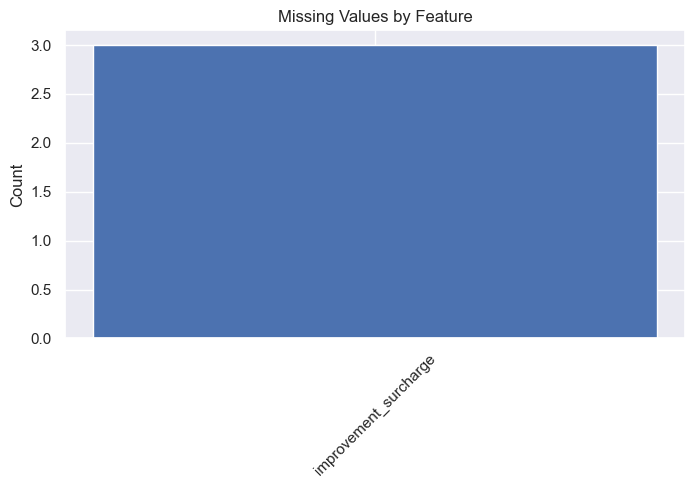

In [13]:
import matplotlib.pyplot as plt

missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["Missing Values"]
)

plt.title("Missing Values by Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Missing Values Analysis

### Summary

The dataset is exceptionally clean regarding missing values.

| Feature | Missing Values | Percentage |
|----------|---------------:|-----------:|
| improvement_surcharge | 3 | 0.000024% |

### Observations

- Only **3 missing values** were found across the entire dataset.
- All remaining features are **100% complete**.
- The missing percentage is statistically negligible.

### Decision

The missing values will be handled during the preprocessing stage without affecting the analysis.

## 2.2 Duplicate Records

In [14]:
duplicates = df.duplicated().sum()

duplicate_percentage = duplicates / len(df) * 100

print(f"Duplicate Rows       : {duplicates:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.6f}%")

Duplicate Rows       : 383
Duplicate Percentage : 0.003004%


In [15]:
df[df.duplicated()].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
248333,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
248334,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300143,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300144,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3
300145,2,2015-01-05 09:39:49,2015-01-05 09:39:52,1,0.0,0.0,0.0,1,N,0.0,0.0,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3


### Duplicate Records

### Summary

| Metric | Value |
|---------|------:|
| Duplicate Rows | **383** |
| Duplicate Percentage | **0.003004%** |

### Observations

- Only **383 duplicate records** were detected.
- Duplicate records represent approximately **0.003%** of the dataset.
- Most duplicated records appear to contain invalid values such as:
  - Zero trip distance
  - Zero pickup/dropoff coordinates

### Decision

Duplicate rows will be removed during the data cleaning phase. Since the duplication rate is extremely low, removing them will have no significant impact on the dataset.

## 2.3 Unique Values & Cardinality Analysis

In [16]:
unique_df = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique()
})

unique_df["Unique %"] = (
    unique_df["Unique Values"] / len(df) * 100
)

unique_df = unique_df.sort_values(
    "Unique Values",
    ascending=False
)

unique_df

,Data Type,Unique Values,Unique %
tpep_dropoff_datetime,str,2442163,19.155743
tpep_pickup_datetime,str,2438284,19.125317
dropoff_latitude,float64,87523,0.686509
pickup_latitude,float64,62748,0.492180
dropoff_longitude,float64,53297,0.418049
pickup_longitude,float64,35900,0.281591
total_amount,float64,11969,0.093882
trip_distance,float64,4350,0.034120
tip_amount,float64,3596,0.028206
fare_amount,float64,2053,0.016103


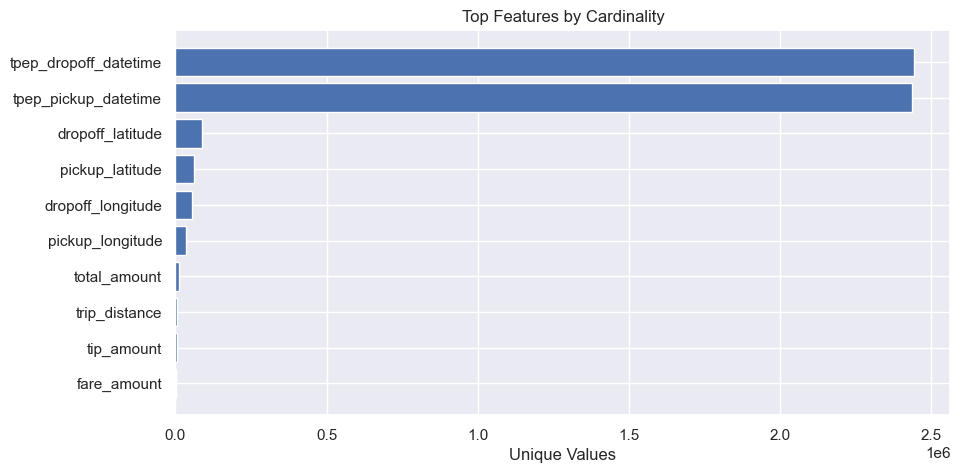

In [17]:
top_unique = unique_df.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_unique.index,
    top_unique["Unique Values"]
)

plt.title("Top Features by Cardinality")
plt.xlabel("Unique Values")

plt.gca().invert_yaxis()

plt.show()

### Unique Values & Cardinality Analysis

### Summary

The dataset contains a mixture of continuous, categorical, and temporal features.

### High Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| tpep_dropoff_datetime | 2,442,163 |
| tpep_pickup_datetime | 2,438,284 |
| dropoff_latitude | 87,523 |
| pickup_latitude | 62,748 |
| dropoff_longitude | 53,297 |
| pickup_longitude | 35,900 |

These features exhibit high cardinality and will require specialized preprocessing.

---

### Medium Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| total_amount | 11,969 |
| trip_distance | 4,350 |
| tip_amount | 3,596 |
| fare_amount | 2,053 |
| tolls_amount | 932 |

These are continuous numerical variables suitable for regression and time-series analysis.

---

### Low Cardinality Features

| Feature | Unique Values |
|----------|--------------:|
| passenger_count | 10 |
| RateCodeID | 7 |
| payment_type | 5 |
| VendorID | 2 |
| store_and_fwd_flag | 2 |

These variables will be treated as categorical features during preprocessing.

---

### Key Observations

- Datetime columns contain millions of unique timestamps and will be decomposed into meaningful temporal features.
- Geographic coordinates are continuous variables and require validation for invalid values.
- Several features naturally have low cardinality and are appropriate candidates for categorical encoding.

## 2.4 Invalid Values Detection

In [18]:
invalid_report = []

# Passenger Count <= 0
invalid_report.append({
    "Feature": "passenger_count <= 0",
    "Invalid Rows": (df["passenger_count"] <= 0).sum()
})

# Trip Distance <= 0
invalid_report.append({
    "Feature": "trip_distance <= 0",
    "Invalid Rows": (df["trip_distance"] <= 0).sum()
})

# Negative Fare
invalid_report.append({
    "Feature": "fare_amount < 0",
    "Invalid Rows": (df["fare_amount"] < 0).sum()
})

# Negative Tip
invalid_report.append({
    "Feature": "tip_amount < 0",
    "Invalid Rows": (df["tip_amount"] < 0).sum()
})

# Negative Total
invalid_report.append({
    "Feature": "total_amount < 0",
    "Invalid Rows": (df["total_amount"] < 0).sum()
})

# Invalid Latitude
invalid_report.append({
    "Feature": "Invalid Pickup Latitude",
    "Invalid Rows": (
        (df["pickup_latitude"] < -90) |
        (df["pickup_latitude"] > 90)
    ).sum()
})

invalid_report.append({
    "Feature": "Invalid Dropoff Latitude",
    "Invalid Rows": (
        (df["dropoff_latitude"] < -90) |
        (df["dropoff_latitude"] > 90)
    ).sum()
})

# Invalid Longitude
invalid_report.append({
    "Feature": "Invalid Pickup Longitude",
    "Invalid Rows": (
        (df["pickup_longitude"] < -180) |
        (df["pickup_longitude"] > 180)
    ).sum()
})

invalid_report.append({
    "Feature": "Invalid Dropoff Longitude",
    "Invalid Rows": (
        (df["dropoff_longitude"] < -180) |
        (df["dropoff_longitude"] > 180)
    ).sum()
})

invalid_report = pd.DataFrame(invalid_report)

invalid_report

,Feature,Invalid Rows
0,passenger_count <= 0,6565
1,trip_distance <= 0,79365
2,fare_amount < 0,4064
3,tip_amount < 0,79
4,total_amount < 0,4067
5,Invalid Pickup Latitude,1
6,Invalid Dropoff Latitude,2
7,Invalid Pickup Longitude,0
8,Invalid Dropoff Longitude,5


In [19]:
invalid_report["Percentage"] = (
    invalid_report["Invalid Rows"] / len(df) * 100
)

invalid_report

,Feature,Invalid Rows,Percentage
0,passenger_count <= 0,6565,0.051494
1,trip_distance <= 0,79365,0.622520
2,fare_amount < 0,4064,0.031877
3,tip_amount < 0,79,0.000620
4,total_amount < 0,4067,0.031901
5,Invalid Pickup Latitude,1,0.000008
6,Invalid Dropoff Latitude,2,0.000016
7,Invalid Pickup Longitude,0,0.000000
8,Invalid Dropoff Longitude,5,0.000039


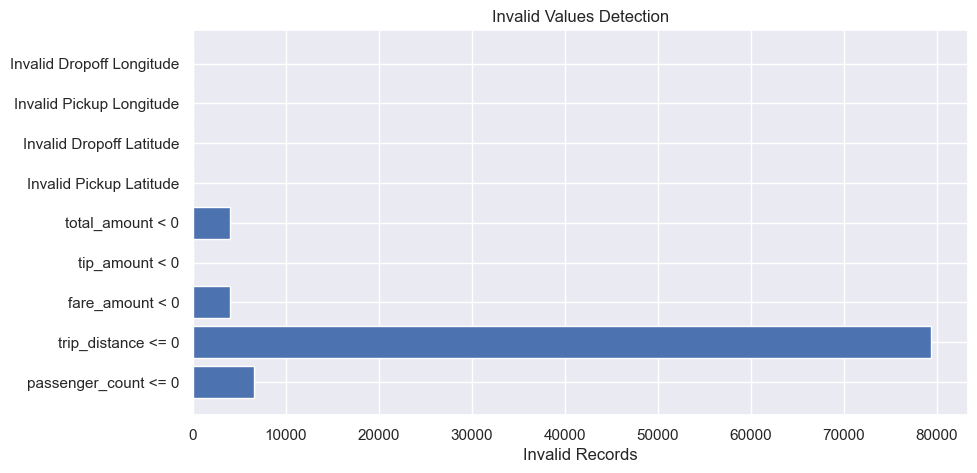

In [20]:
plt.figure(figsize=(10,5))

plt.barh(
    invalid_report["Feature"],
    invalid_report["Invalid Rows"]
)

plt.xlabel("Invalid Records")
plt.title("Invalid Values Detection")

plt.show()

In [21]:
df[df["fare_amount"] < 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
3831,2,2015-01-17 22:40:27,2015-01-17 22:43:04,1,0.11,-74.002357,40.739826,1,N,-74.001114,40.741108,4,-3.5,-0.5,-0.5,0.0,0.0,0.3,-4.8
4924,2,2015-01-15 17:33:24,2015-01-15 17:33:31,2,0.00,-73.982567,40.739799,1,N,-73.982567,40.739799,3,-2.5,-1.0,-0.5,-0.7,0.0,0.3,-5.0
10046,2,2015-01-16 16:00:45,2015-01-16 16:00:53,1,0.00,-73.937721,40.758194,1,N,-73.937721,40.758194,3,-2.5,-1.0,-0.5,0.0,0.0,0.3,-4.3
16703,2,2015-01-31 23:38:52,2015-01-31 23:38:54,2,0.00,0.000000,0.000000,2,N,0.000000,0.000000,2,-52.0,0.0,-0.5,0.0,0.0,0.3,-52.8
19953,2,2015-01-10 02:23:53,2015-01-10 02:23:58,2,0.00,0.000000,0.000000,5,N,0.000000,0.000000,1,-6.8,0.0,0.0,-1.0,0.0,0.3,-8.1


In [22]:
df[df["trip_distance"] <= 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
132,1,2015-01-15 10:26:16,2015-01-15 10:26:42,2,0.0,-73.987656,40.743645,5,N,-73.987488,40.743484,1,60.0,0.0,0.0,15.0,0.0,0.3,75.3
133,1,2015-01-15 10:26:17,2015-01-15 10:27:28,1,0.0,-73.946526,40.744991,1,N,-73.946526,40.744991,2,3.0,0.0,0.5,0.0,0.0,0.3,3.8
372,1,2015-01-01 01:08:56,2015-01-01 01:08:56,4,0.0,-73.980789,40.676605,1,Y,0.000000,0.000000,2,20.0,0.5,0.5,0.0,0.0,0.0,21.3
629,2,2015-01-25 17:45:15,2015-01-25 17:45:21,1,0.0,-73.975655,40.761318,2,N,0.000000,0.000000,1,52.0,0.0,0.5,20.0,0.0,0.3,72.8
707,1,2015-01-10 20:14:23,2015-01-10 20:14:36,1,0.0,-73.993271,40.748833,1,N,-73.993271,40.748833,3,2.5,0.5,0.5,0.0,0.0,0.3,3.8


In [23]:
df[
    (df["pickup_latitude"] > 90) |
    (df["pickup_latitude"] < -90)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
10833612,2,2015-01-18 23:43:40,2015-01-18 23:56:47,1,4.15,-73.98497,404.700012,1,N,-74.014519,40.717091,1,14.5,0.5,0.5,3.0,0.0,0.3,18.8


In [24]:
df[
    (df["dropoff_longitude"] < -180) |
    (df["dropoff_longitude"] > 180)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2128340,2,2015-01-19 21:12:55,2015-01-19 21:20:09,1,2.35,-73.956184,40.714127,1,N,-736.183350,40.737411,1,9.0,0.5,0.5,1.90,0.00,0.3,12.20
4511429,2,2015-01-08 19:56:04,2015-01-08 20:08:35,1,2.64,-73.942993,40.784092,2,N,-736.416687,40.787601,1,52.0,0.0,0.5,14.33,5.33,0.3,72.46
8918960,2,2015-01-15 00:31:06,2015-01-15 00:36:51,5,0.95,-73.990967,40.734180,1,N,-705.816650,40.741928,1,6.0,0.5,0.5,1.95,0.00,0.3,9.25
9753577,2,2015-01-25 01:02:15,2015-01-25 01:07:20,2,0.68,-73.982796,40.727146,1,N,-739.216675,40.726250,2,5.0,0.5,0.5,0.00,0.00,0.3,6.30
11836792,2,2015-01-17 02:46:28,2015-01-17 02:52:03,4,1.45,-74.009995,40.721222,1,N,-740.166687,40.735470,1,6.5,0.5,0.5,1.20,0.00,0.3,9.00


### Invalid Values Detection

### Objective

The objective of this step was to identify physically impossible or logically invalid values before starting the preprocessing phase.

### Validation Rules

| Feature | Expected Range |
|----------|----------------|
| passenger_count | > 0 |
| trip_distance | > 0 |
| fare_amount | >= 0 |
| tip_amount | >= 0 |
| total_amount | >= 0 |
| pickup_latitude | [-90, 90] |
| dropoff_latitude | [-90, 90] |
| pickup_longitude | [-180, 180] |
| dropoff_longitude | [-180, 180] |

### Results

| Validation Rule | Invalid Records | Percentage |
|-----------------|---------------:|-----------:|
| passenger_count <= 0 | 6,565 | 0.0515% |
| trip_distance <= 0 | 79,365 | 0.6225% |
| fare_amount < 0 | 4,064 | 0.0319% |
| tip_amount < 0 | 79 | 0.0006% |
| total_amount < 0 | 4,067 | 0.0319% |
| Invalid pickup latitude | 1 | 0.000008% |
| Invalid dropoff latitude | 2 | 0.000016% |
| Invalid pickup longitude | 0 | 0.000000% |
| Invalid dropoff longitude | 5 | 0.000039% |

### Observations

- Zero or negative trip distances represent the largest group of invalid records.
- Several trips contain non-positive passenger counts.
- A small number of trips have negative fare or total amounts, likely representing refunds, cancellations, or recording errors.
- Only a handful of records contain impossible geographic coordinates.
- Some records also contain `(0,0)` coordinates, which are technically within the valid geographic range but clearly invalid for NYC taxi trips.

### Conclusion

Although the percentage of invalid records is relatively small, these observations confirm that data cleaning is required before feature engineering and model development. The identified records will be handled during the preprocessing stage.

## 2.5 Outlier Detection

In [25]:
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount"
]

numeric_columns

['passenger_count',
 'trip_distance',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount']

In [26]:
outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers": outliers,
        "Percentage": outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Outliers",
    ascending=False
).reset_index(drop=True)

,Feature,Lower Bound,Upper Bound,Outliers,Percentage
0,passenger_count,-0.50,3.50,1405471,11.024179
1,trip_distance,-2.00,6.00,1259087,9.875978
2,total_amount,-4.05,28.51,1090560,8.554092
3,fare_amount,-4.00,24.00,1048995,8.228066
4,improvement_surcharge,0.30,0.30,716362,5.618972
5,tip_amount,-3.09,5.15,631614,4.954229
6,tolls_amount,0.00,0.00,540455,4.239200
7,mta_tax,0.50,0.50,52224,0.409633
8,extra,-0.75,1.25,717,0.005624


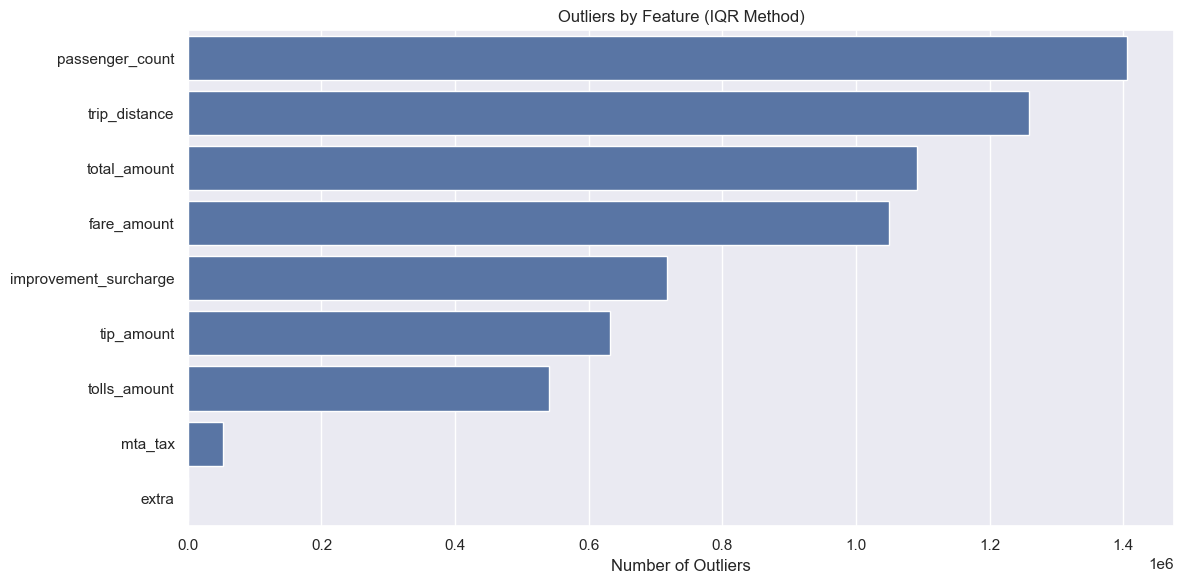

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=outlier_df.sort_values("Outliers", ascending=False),
    x="Outliers",
    y="Feature"
)

plt.title("Outliers by Feature (IQR Method)")
plt.xlabel("Number of Outliers")
plt.ylabel("")
plt.tight_layout()

plt.show()

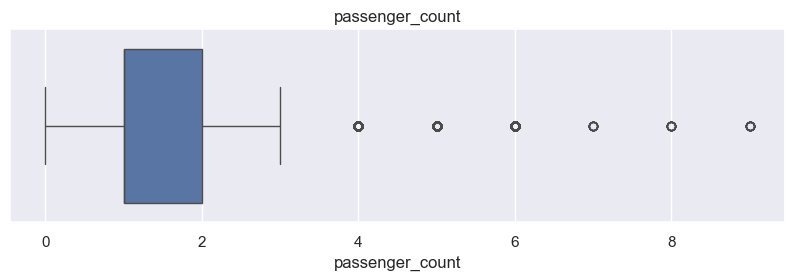

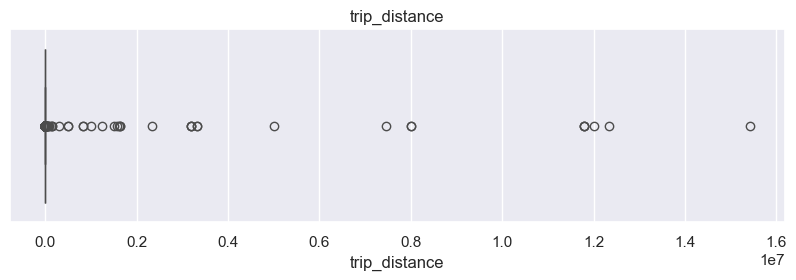

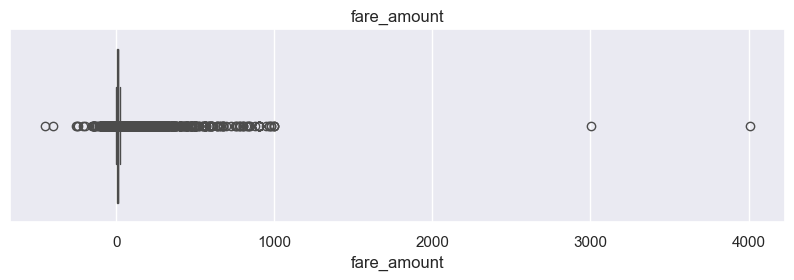

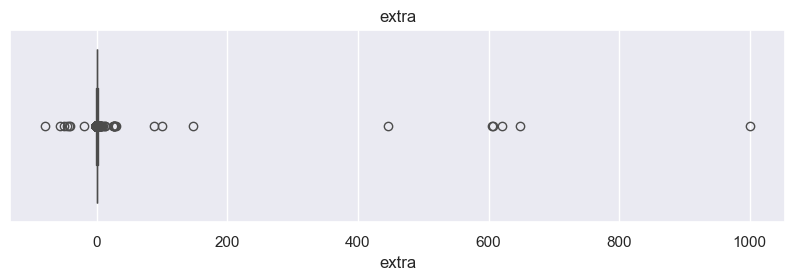

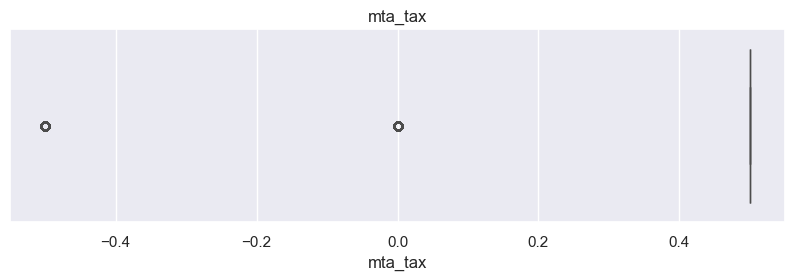

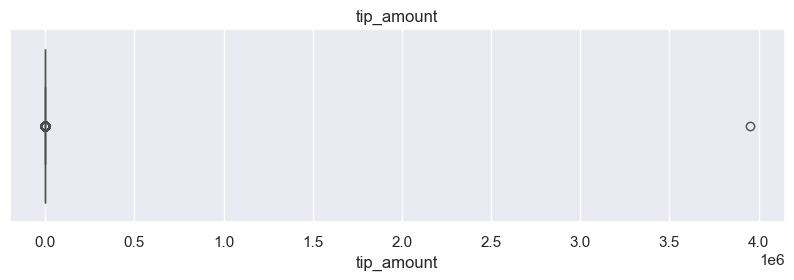

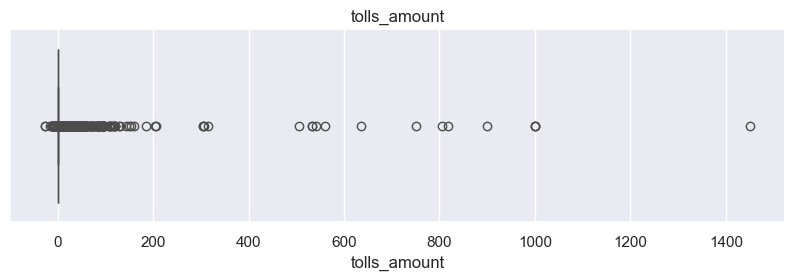

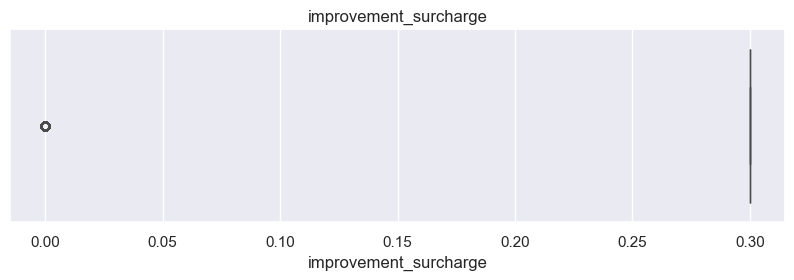

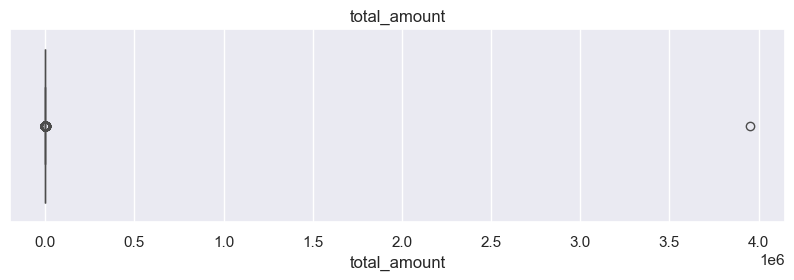

In [28]:
for col in numeric_columns:

    plt.figure(figsize=(10,2.5))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [29]:
feature = "trip_distance"

Q1 = df[feature].quantile(.25)
Q3 = df[feature].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[
    (df[feature] < lower) |
    (df[feature] > upper)
].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
5,1,2015-01-10 20:33:39,2015-01-10 20:53:52,1,9.00,-73.874374,40.774048,1,N,-73.986977,40.758194,1,27.0,0.5,0.5,6.70,5.33,0.3,40.33
8,1,2015-01-10 20:33:39,2015-01-10 21:11:35,3,18.20,-73.783043,40.644356,2,N,-73.987595,40.759357,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13
17,2,2015-01-15 19:05:40,2015-01-15 19:28:18,5,8.33,-73.863060,40.769581,1,N,-73.952713,40.785782,1,26.0,1.0,0.5,8.08,5.33,0.3,41.21
19,2,2015-01-15 19:05:41,2015-01-15 19:20:22,2,7.13,-73.874458,40.774010,1,N,-73.952377,40.718590,1,21.5,1.0,0.5,4.50,0.00,0.3,27.80
27,2,2015-01-15 19:05:42,2015-01-15 19:49:07,1,18.06,-73.786575,40.644127,2,N,-73.985603,40.743530,1,52.0,0.0,0.5,6.00,5.33,0.3,64.13


In [30]:
for col in numeric_columns:

    print("=" * 60)

    print(col)

    display(
        df[col].nlargest(5)
    )

passenger_count


5845       9
1216773    9
1441820    9
4065512    9
6590946    9
Name: passenger_count, dtype: int64

trip_distance


5052762     15420004.5
6623534     12331800.0
11022476    12000000.0
3318706     11800001.7
6160248     11800000.6
Name: trip_distance, dtype: float64

fare_amount


...

5189604     1450.09
2093033     1000.66
3353313      999.99
3590037      999.99
10883358     900.00
Name: tolls_amount, dtype: float64

improvement_surcharge


0    0.3
1    0.3
2    0.3
3    0.3
4    0.3
Name: improvement_surcharge, dtype: float64

total_amount


10862961    3950611.60
12477051       4009.30
1851068        3006.35
3590037        2999.97
3353313        1820.99
Name: total_amount, dtype: float64

In [31]:
for col in numeric_columns:

    print("=" * 60)

    print(col)

    display(
        df[col].nsmallest(5)
    )

passenger_count


1364    0
1898    0
2922    0
8185    0
9587    0
Name: passenger_count, dtype: int64

trip_distance


132    0.0
133    0.0
372    0.0
629    0.0
707    0.0
Name: trip_distance, dtype: float64

fare_amount


...

6574302    -26.00
10259094   -26.00
6035473    -16.00
667077     -11.75
3102514    -11.75
Name: tolls_amount, dtype: float64

improvement_surcharge


61    0.0
67    0.0
68    0.0
71    0.0
72    0.0
Name: improvement_surcharge, dtype: float64

total_amount


1034171    -450.30
1816134    -400.30
11509518   -255.80
4259203    -250.30
3409380    -242.55
Name: total_amount, dtype: float64

### 2.5 Outlier Detection

Outliers were identified using the **Interquartile Range (IQR)** method across all numerical features.

### Key Findings

Several numerical variables contain observations outside the IQR boundaries.

The highest percentages of detected outliers were:

| Feature | Outlier % |
|----------|-----------|
| passenger_count | 11.02% |
| trip_distance | 9.88% |
| total_amount | 8.55% |
| fare_amount | 8.23% |
| improvement_surcharge | 5.62% |
| tip_amount | 4.95% |
| tolls_amount | 4.24% |

### Observations

The analysis revealed two different categories of outliers:

- Legitimate business outliers such as:
  - Long-distance taxi trips
  - High fares
  - Large tips
  - High toll charges

- Data quality issues including:
  - Extremely large trip distances (millions of miles)
  - Unrealistically high fares and tips
  - Negative monetary values
  - Invalid surcharge values

### Conclusion

Since the IQR method identifies both legitimate extreme observations and erroneous records, **outliers will not be removed automatically** during the EDA phase.

Instead, data cleaning rules based on domain knowledge will be applied later during the preprocessing stage to distinguish between valid observations and corrupted records.

# 3. Exploratory Data Analysis (EDA)

## 3.1 Passenger Count Analysis

The `passenger_count` feature represents the number of passengers in each taxi trip.

In this section, we will:

- Examine the distribution of passenger counts.
- Identify the most common trip sizes.
- Detect unusual passenger counts.
- Calculate descriptive statistics.
- Visualize the distribution.Distribution

In [32]:
# ==========================================================
# Passenger Count - Descriptive Statistics
# ==========================================================

# Display summary statistics for passenger_count
df["passenger_count"].describe()

count    1.274899e+07
mean     1.681491e+00
std      1.337924e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [33]:
# ==========================================================
# Passenger Count Frequency
# ==========================================================

# Count each passenger value
passenger_counts = (
    df["passenger_count"]
    .value_counts()
    .sort_index()
)

passenger_counts

passenger_count
0       6565
1    8993870
2    1814594
3     528486
4     253228
5     697645
6     454568
7          9
8         10
9         11
Name: count, dtype: int64

In [34]:
# ==========================================================
# Passenger Count Percentage
# ==========================================================

# Calculate percentage for each passenger count
passenger_percentage = (
    df["passenger_count"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

passenger_percentage

passenger_count
0     0.051494
1    70.545767
2    14.233242
3     4.145318
4     1.986260
5     5.472161
6     3.565523
7     0.000071
8     0.000078
9     0.000086
Name: proportion, dtype: float64

In [35]:
# ==========================================================
# Passenger Count Summary Table
# ==========================================================

# Combine frequency and percentage into one table
passenger_summary = pd.DataFrame({
    "Count": passenger_counts,
    "Percentage": passenger_percentage
})

# Round percentages
passenger_summary["Percentage"] = passenger_summary["Percentage"].round(3)

passenger_summary

,Count,Percentage
passenger_count,,
0,6565,0.051
1,8993870,70.546
2,1814594,14.233
3,528486,4.145
4,253228,1.986
5,697645,5.472
6,454568,3.566
7,9,0.000
8,10,0.000


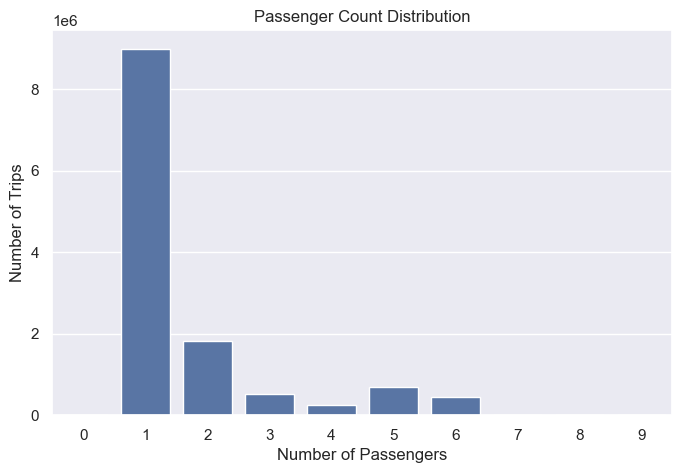

In [36]:
# ==========================================================
# Passenger Count Bar Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=passenger_summary.index,
    y=passenger_summary["Count"]
)

plt.title("Passenger Count Distribution")
plt.xlabel("Number of Passengers")
plt.ylabel("Number of Trips")

plt.show()

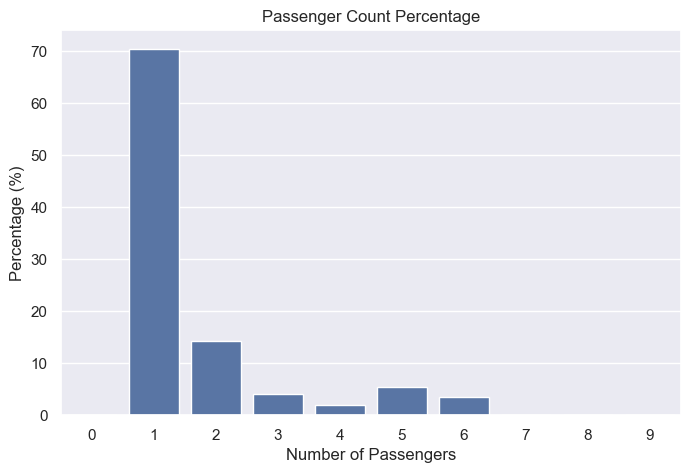

In [37]:
# ==========================================================
# Passenger Count Percentage Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=passenger_summary.index,
    y=passenger_summary["Percentage"]
)

plt.title("Passenger Count Percentage")
plt.xlabel("Number of Passengers")
plt.ylabel("Percentage (%)")

plt.show()

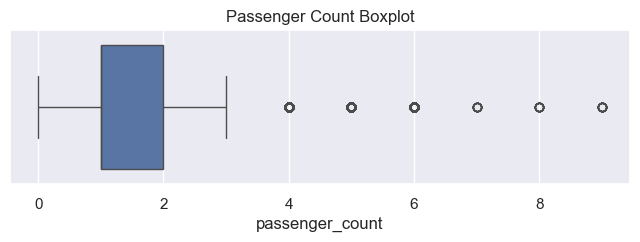

In [38]:
# ==========================================================
# Passenger Count Boxplot
# ==========================================================

plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["passenger_count"]
)

plt.title("Passenger Count Boxplot")

plt.show()

### Findings

#### Passenger Count Distribution

The passenger count analysis reveals a highly imbalanced distribution across taxi trips.

**Key observations:**

- Approximately **70.55%** of all trips involve **one passenger**, making solo travel the dominant travel pattern in the dataset.

- Around **14.23%** of trips contain **two passengers**, representing the second most common trip type.

- Trips with **three or four passengers** are relatively uncommon, accounting for only **4.15%** and **1.99%**, respectively.

- Surprisingly, trips with **five (5.47%)** and **six passengers (3.57%)** occur more frequently than trips with three or four passengers. This may reflect larger groups using shared taxi services or airport transportation.

- Passenger counts greater than six (7–9 passengers) are extremely rare, with only **30 observations** across more than **12.7 million trips**, indicating potential data entry errors or exceptional cases.

- A small number of trips (**6,565 records**, approximately **0.05%**) contain **zero passengers**, which were previously identified as invalid records during the data quality assessment.

#### Distribution Shape

The boxplot confirms that the passenger count distribution is **strongly right-skewed**.

Most observations are concentrated between **one and two passengers**, while passenger counts greater than three appear as statistical outliers. However, these values are operationally valid and represent legitimate larger-group trips rather than erroneous data.

#### Conclusion

The analysis indicates that the vast majority of NYC taxi rides are taken by one or two passengers. The `passenger_count` feature has a highly discrete distribution and does not require transformation at this stage. Invalid zero-passenger trips will be handled later during the data cleaning phase.

## 3.2 Trip Distance Analysis

The `trip_distance` feature represents the distance traveled during each taxi trip in miles.

In this section, we will:

- Explore the statistical distribution of trip distances.
- Identify the most common trip lengths.
- Visualize the distribution.
- Examine skewness and extreme values.
- Understand how trip distance varies across the dataset.

In [39]:
# ==========================================================
# Trip Distance - Descriptive Statistics
# ==========================================================

# Display summary statistics
df["trip_distance"].describe()

count    1.274899e+07
mean     1.345913e+01
std      9.844094e+03
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.000000e+00
max      1.542000e+07
Name: trip_distance, dtype: float64

In [40]:
# ==========================================================
# Trip Distance Percentiles
# ==========================================================

# Calculate important percentiles
distance_percentiles = (
    df["trip_distance"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Distance (Miles)")
)

distance_percentiles

,Distance (Miles)
0.25,1.00
0.50,1.68
0.75,3.00
0.90,5.99
0.95,9.66
0.99,18.22


In [41]:
# ==========================================================
# Trip Distance Distribution
# ==========================================================

# Sample data for faster visualization
distance_sample = df["trip_distance"].sample(
    n=200000,
    random_state=42
)

print(f"Sample Size: {len(distance_sample):,}")

Sample Size: 200,000


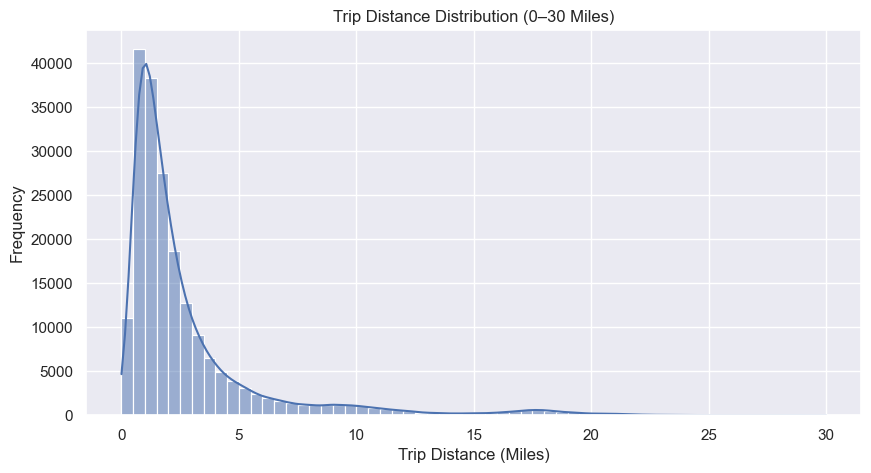

In [42]:
# ==========================================================
# Trip Distance Distribution (Valid Trips Only)
# ==========================================================

# Keep trips between 0 and 30 miles for visualization
distance_plot = df.loc[
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 30),
    "trip_distance"
].sample(
    n=200000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    distance_plot,
    bins=60,
    kde=True
)

plt.title("Trip Distance Distribution (0–30 Miles)")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Frequency")

plt.show()

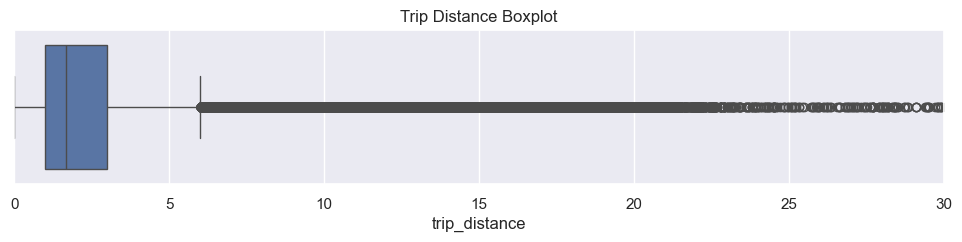

In [43]:
# ==========================================================
# Trip Distance Boxplot
# ==========================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=distance_sample
)

plt.xlim(0,30)

plt.title("Trip Distance Boxplot")

plt.show()

In [44]:
# ==========================================================
# Trip Distance Summary
# ==========================================================

trip_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["trip_distance"].mean(),
        df["trip_distance"].median(),
        df["trip_distance"].std(),
        df["trip_distance"].min(),
        df["trip_distance"].max()
    ]

})

trip_summary

,Statistic,Value
0,Mean,1.345913e+01
1,Median,1.680000e+00
2,Std,9.844094e+03
3,Minimum,0.000000e+00
4,Maximum,1.542000e+07


In [45]:
# ==========================================================
# Long Distance Trips
# ==========================================================

# Trips longer than 30 miles
long_trips = df[df["trip_distance"] > 30]

print(f"Trips > 30 Miles : {len(long_trips):,}")

long_trips.head()

Trips > 30 Miles : 3,390


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2110,2,2015-01-06 11:49:51,2015-01-06 13:03:03,1,41.94,-73.939407,40.750420,5,N,-74.393951,40.531219,1,190.0,0.0,0.0,0.00,14.75,0.3,205.05
5233,1,2015-01-11 03:28:03,2015-01-11 03:42:48,1,34.30,-74.003983,40.752075,1,N,-73.971634,40.785339,1,2.5,0.5,0.5,1.00,10.30,0.3,15.10
7584,2,2015-01-16 03:04:37,2015-01-16 03:49:08,4,36.07,-73.785454,40.645649,5,N,-74.198837,40.674656,2,135.5,0.0,0.0,0.00,9.75,0.3,145.55
11971,2,2015-01-24 00:19:53,2015-01-24 01:06:45,1,36.54,-73.790344,40.646523,5,N,-73.710472,41.077820,1,150.0,0.0,0.0,30.06,0.00,0.3,180.36
14644,1,2015-01-18 07:36:47,2015-01-18 08:48:42,1,33.60,0.000000,0.000000,2,N,0.000000,0.000000,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13


### Findings

#### Trip Distance Distribution

The trip distance analysis indicates that most NYC taxi trips are relatively short.

**Key observations**

- The median trip distance is **1.68 miles**, indicating that half of all taxi trips are shorter than two miles.

- The first quartile is **1.0 mile**, while the third quartile is **3.0 miles**, meaning that **75% of all trips are three miles or less**.

- Even the **95th percentile is only 9.66 miles**, showing that long-distance trips are uncommon.

- Only **1% of trips exceed 18.22 miles**, confirming that the overwhelming majority of taxi rides occur within short urban distances.

- A total of **3,390 trips** exceed **30 miles**, representing only a tiny fraction of the dataset. These trips are likely airport transfers or long intercity rides, although some records may still represent data quality issues.

#### Distribution Shape

The distribution is **extremely right-skewed**.

Most observations are concentrated between **1 and 3 miles**, while a very small number of extremely long trips create a long right tail.

#### Mean vs Median

The mean trip distance (**13.46 miles**) is substantially higher than the median (**1.68 miles**).

This large discrepancy is caused by a handful of unrealistic values, including trips with distances reaching **15.42 million miles**.

These extreme observations heavily inflate the average and should not be considered representative of typical taxi trips.

#### Conclusion

The trip distance feature exhibits a highly skewed distribution with a small number of extreme values.

For subsequent analysis and visualization, it is preferable to focus on realistic trip distances (e.g., 0–30 miles) while handling erroneous extreme values during the data cleaning stage.

## 3.3 Fare Amount Analysis

The `fare_amount` feature represents the base fare charged for each taxi trip before additional fees, tolls, and tips.

In this section, we will:

- Examine the statistical distribution of fares.
- Explore common fare ranges.
- Visualize fare distribution.
- Investigate extreme values.
- Understand the overall pricing behavior.

In [46]:
# ==========================================================
# Fare Amount - Descriptive Statistics
# ==========================================================

# Display summary statistics
df["fare_amount"].describe()

count    1.274899e+07
mean     1.190566e+01
std      1.030254e+01
min     -4.500000e+02
25%      6.500000e+00
50%      9.000000e+00
75%      1.350000e+01
max      4.008000e+03
Name: fare_amount, dtype: float64

In [47]:
# ==========================================================
# Fare Amount Percentiles
# ==========================================================

# Calculate important fare percentiles
fare_percentiles = (
    df["fare_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Fare ($)")
)

fare_percentiles

,Fare ($)
0.25,6.5
0.50,9.0
0.75,13.5
0.90,22.0
0.95,31.0
0.99,52.0


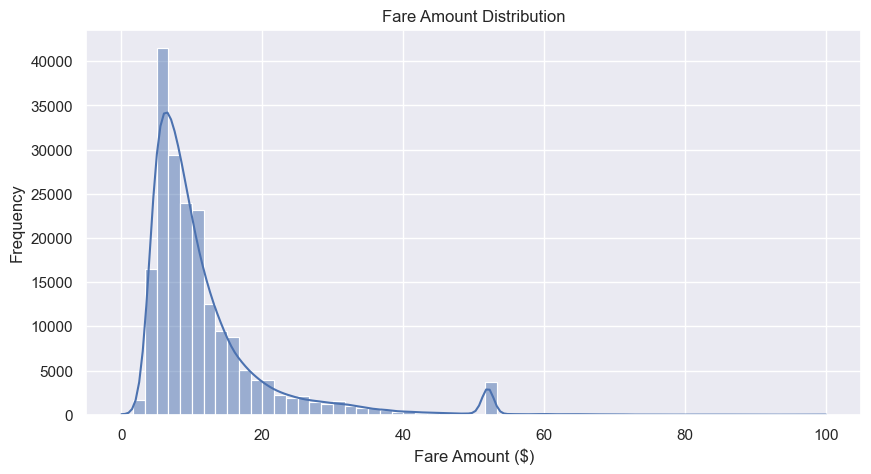

In [48]:
# ==========================================================
# Fare Distribution
# ==========================================================

# Sample realistic fares for visualization
fare_sample = df.loc[
    (df["fare_amount"] >= 0) &
    (df["fare_amount"] <= 100),
    "fare_amount"
].sample(
    n=200000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    fare_sample,
    bins=60,
    kde=True
)

plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")

plt.show()

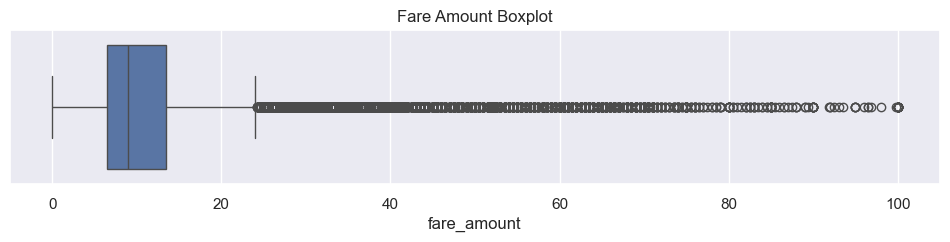

In [49]:
# ==========================================================
# Fare Amount Boxplot
# ==========================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=fare_sample
)

plt.title("Fare Amount Boxplot")

plt.show()

In [50]:
# ==========================================================
# Fare Amount Summary
# ==========================================================

fare_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["fare_amount"].mean(),
        df["fare_amount"].median(),
        df["fare_amount"].std(),
        df["fare_amount"].min(),
        df["fare_amount"].max()
    ]

})

fare_summary

,Statistic,Value
0,Mean,11.905659
1,Median,9.000000
2,Std,10.302537
3,Minimum,-450.000000
4,Maximum,4008.000000


In [51]:
# ==========================================================
# Fare Amount Skewness
# ==========================================================

# Calculate skewness
fare_skewness = df["fare_amount"].skew()

print(f"Fare Amount Skewness : {fare_skewness:.2f}")

Fare Amount Skewness : 12.62


In [52]:
# ==========================================================
# High Fare Trips
# ==========================================================

# Trips with fares above $100
high_fares = df[df["fare_amount"] > 100]

print(f"Trips > $100 : {len(high_fares):,}")

high_fares.head()

Trips > $100 : 5,721


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1278,1,2015-01-26 13:33:53,2015-01-26 13:35:28,1,0.00,-74.035408,40.744484,5,N,-74.035461,40.744503,1,149.0,0.0,0.0,0.00,0.00,0.3,149.30
2110,2,2015-01-06 11:49:51,2015-01-06 13:03:03,1,41.94,-73.939407,40.750420,5,N,-74.393951,40.531219,1,190.0,0.0,0.0,0.00,14.75,0.3,205.05
4879,2,2015-01-26 14:19:25,2015-01-26 16:37:03,1,25.42,-73.977257,40.742832,3,N,-74.177460,40.690643,1,115.5,0.0,0.0,10.00,11.75,0.3,137.55
6545,1,2015-01-04 15:14:15,2015-01-04 15:16:10,1,0.10,-73.673126,40.982090,5,N,-73.671165,40.983475,1,143.0,0.0,0.0,37.55,7.00,0.0,187.85
7584,2,2015-01-16 03:04:37,2015-01-16 03:49:08,4,36.07,-73.785454,40.645649,5,N,-74.198837,40.674656,2,135.5,0.0,0.0,0.00,9.75,0.3,145.55


In [53]:
# ==========================================================
# Fare Range Distribution
# ==========================================================

fare_bins = [0, 10, 20, 30, 50, 100, float("inf")]
fare_labels = [
    "$0–10",
    "$10–20",
    "$20–30",
    "$30–50",
    "$50–100",
    ">$100"
]

fare_groups = pd.cut(
    df["fare_amount"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

fare_distribution = (
    fare_groups
    .value_counts()
    .sort_index()
    .to_frame("Trips")
)

fare_distribution["Percentage"] = (
    fare_distribution["Trips"] / len(df) * 100
).round(2)

fare_distribution

,Trips,Percentage
fare_amount,,
$0–10,7639035,59.92
$10–20,3645475,28.59
$20–30,788090,6.18
$30–50,380807,2.99
$50–100,285794,2.24
>$100,5721,0.04


### Fare Amount Analysis — Key Findings

- The median fare was **$9.00**, indicating that half of all taxi trips cost $9 or less.

- The mean fare was approximately **$11.91**, which was higher than the median. This difference indicates a positively skewed fare distribution caused by a relatively small number of high-fare trips.

- Fare percentiles showed that:
  - 75% of trips had fares of **$13.50 or less**.
  - 90% had fares of **$22.00 or less**.
  - 95% had fares of **$31.00 or less**.
  - 99% had fares of **$52.00 or less**.

- Approximately **59.92%** of all trips had fares between **$0 and $10**, while **28.59%** had fares between **$10 and $20**. Therefore, approximately **88.51%** of trips had fares below or equal to $20.

- The fare distribution was strongly right-skewed, with a skewness value of **12.62**. Most trips were concentrated in the lower fare ranges, while a small number of expensive trips created a long right tail.

- A noticeable concentration appeared near **$52**, which may be associated with a fixed-fare trip category. This pattern will be investigated later using variables such as `RateCodeID`, trip distance, and pickup/dropoff locations.

- Only **5,721 trips (0.04%)** had fares above $100. These records should not be removed automatically because some may represent legitimate long-distance or special-rate trips.

- Negative fare values and extremely high fares were detected. These records require further investigation during the data-cleaning stage.

### Business Insight

The taxi market was dominated by relatively low-cost trips. Nearly nine out of every ten trips had a base fare of $20 or less, suggesting that typical taxi demand mainly consisted of short to medium-distance urban journeys.

## 3.4 Total Amount Analysis

The `total_amount` feature represents the final recorded amount associated with each taxi trip, including the base fare, additional charges, taxes, tips, tolls, and improvement surcharge.

This analysis aims to:

- Examine the statistical distribution of total trip amounts.
- Identify the typical amount associated with a taxi trip.
- Measure the spread and skewness of the distribution.
- Examine important percentiles.
- Identify negative, zero, and unusually high total amounts.
- Compare the total amount with the base fare.

In [54]:
# ============================================================
# Total Amount - Descriptive Statistics
# ============================================================

# Display summary statistics for the total trip amount
df["total_amount"].describe()

count    1.274899e+07
mean     1.510829e+01
std      1.106503e+03
min     -4.503000e+02
25%      8.160000e+00
50%      1.116000e+01
75%      1.630000e+01
max      3.950612e+06
Name: total_amount, dtype: float64

In [55]:
# ============================================================
# Total Amount Percentiles
# ============================================================

# Calculate important total amount percentiles
total_percentiles = (
    df["total_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Total Amount ($)")
)

# Display the percentile table
total_percentiles

,Total Amount ($)
0.25,8.16
0.50,11.16
0.75,16.30
0.90,26.00
0.95,39.17
0.99,68.13


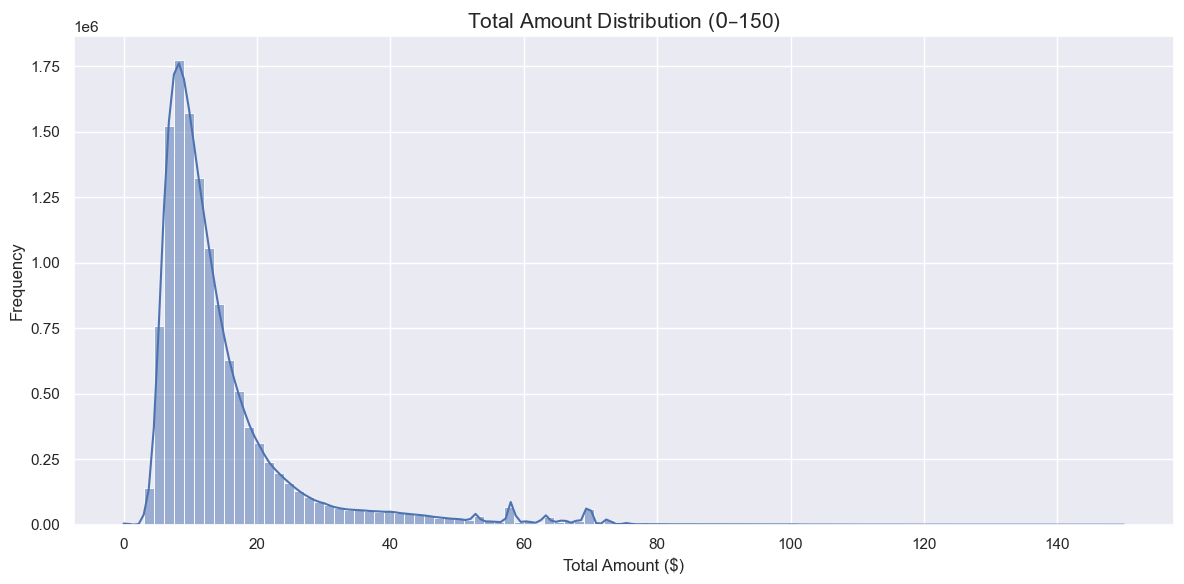

In [56]:
# ============================================================
# Total Amount Distribution
# ============================================================

# Plot the distribution using only total amounts
# between $0 and $150 for better visualization
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df[
        (df["total_amount"] >= 0) &
        (df["total_amount"] <= 150)
    ],
    x="total_amount",
    bins=100,
    kde=True
)

# Add chart title and axis labels
plt.title(
    "Total Amount Distribution ($0–$150)",
    fontsize=15
)

plt.xlabel("Total Amount ($)")
plt.ylabel("Frequency")

# Improve chart layout
plt.tight_layout()

plt.show()

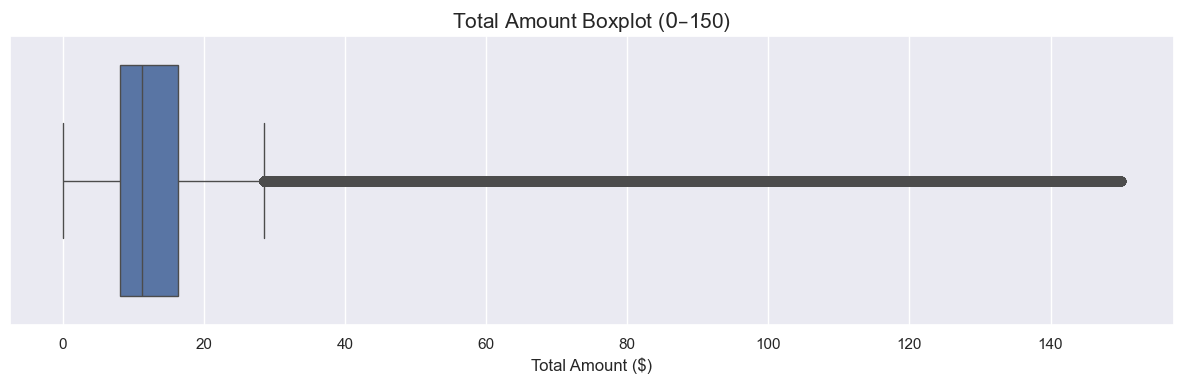

In [57]:
# ============================================================
# Total Amount Boxplot
# ============================================================

# Display total amounts between $0 and $150
# to make the main distribution visible
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=df[
        (df["total_amount"] >= 0) &
        (df["total_amount"] <= 150)
    ],
    x="total_amount"
)

# Add chart title and axis label
plt.title(
    "Total Amount Boxplot ($0–$150)",
    fontsize=15
)

plt.xlabel("Total Amount ($)")

# Improve chart layout
plt.tight_layout()

plt.show()

In [58]:
# ============================================================
# Total Amount Summary
# ============================================================

# Create a summary table containing important statistics
total_summary = pd.DataFrame({
    
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    
    "Value": [
        df["total_amount"].mean(),
        df["total_amount"].median(),
        df["total_amount"].std(),
        df["total_amount"].min(),
        df["total_amount"].max()
    ]
})

# Display the summary table
total_summary

,Statistic,Value
0,Mean,1.510829e+01
1,Median,1.116000e+01
2,Standard Deviation,1.106503e+03
3,Minimum,-4.503000e+02
4,Maximum,3.950612e+06


In [59]:
# ============================================================
# Total Amount Skewness
# ============================================================

# Calculate the skewness of the total amount distribution
total_skewness = df["total_amount"].skew()

# Display the result
print(
    f"Total Amount Skewness : {total_skewness:.2f}"
)

Total Amount Skewness : 3569.89


In [60]:
# ============================================================
# Invalid Total Amount Values
# ============================================================

# Count trips with negative total amounts
negative_total = (
    df["total_amount"] < 0
).sum()

# Count trips with zero total amounts
zero_total = (
    df["total_amount"] == 0
).sum()

# Calculate their percentages
negative_total_percentage = (
    negative_total / len(df)
) * 100

zero_total_percentage = (
    zero_total / len(df)
) * 100

# Display the results
print(
    f"Negative Total Amounts : "
    f"{negative_total:,} "
    f"({negative_total_percentage:.4f}%)"
)

print(
    f"Zero Total Amounts     : "
    f"{zero_total:,} "
    f"({zero_total_percentage:.4f}%)"
)

Negative Total Amounts : 4,067 (0.0319%)
Zero Total Amounts     : 1,194 (0.0094%)


In [61]:
# ============================================================
# Total Amount Ranges
# ============================================================

# Define total amount intervals
total_bins = [
    0,
    10,
    20,
    30,
    50,
    100,
    float("inf")
]

# Define labels for each interval
total_labels = [
    "$0–10",
    "$10–20",
    "$20–30",
    "$30–50",
    "$50–100",
    ">$100"
]

# Group non-negative total amounts into ranges
total_ranges = pd.cut(
    
    df.loc[
        df["total_amount"] >= 0,
        "total_amount"
    ],
    
    bins=total_bins,
    labels=total_labels,
    include_lowest=True,
    right=True
)

# Count trips in each range
total_range_counts = (
    total_ranges
    .value_counts()
    .sort_index()
)

# Calculate the percentage of trips in each range
total_range_percentage = (
    total_range_counts /
    total_range_counts.sum()
) * 100

# Combine counts and percentages into one table
total_range_summary = pd.DataFrame({
    
    "Trips": total_range_counts,
    
    "Percentage": (
        total_range_percentage.round(2)
    )
})

# Display the final table
total_range_summary

,Trips,Percentage
total_amount,,
$0–10,5367863,42.12
$10–20,5265349,41.31
$20–30,1111753,8.72
$30–50,622516,4.88
$50–100,364749,2.86
>$100,12689,0.10


### Total Amount Analysis — Key Findings

- The median total trip amount was **$11.16**, indicating that half of all taxi trips had a final recorded amount of $11.16 or less.

- The mean total amount was approximately **$15.11**, which was higher than the median. This difference indicates a positively skewed distribution caused by a relatively small number of high-value trips.

- Total amount percentiles showed that:
  - 75% of trips had total amounts of **$16.30 or less**.
  - 90% had total amounts of **$26.00 or less**.
  - 95% had total amounts of **$39.17 or less**.
  - 99% had total amounts of **$68.13 or less**.

- Approximately **42.12%** of trips had total amounts between **$0 and $10**, while **41.31%** had total amounts between **$10 and $20**. Therefore, approximately **83.43%** of trips had final amounts of $20 or less.

- Only **12,689 trips (0.10%)** had total amounts greater than $100, indicating that very expensive trips represented a small fraction of the dataset.

- The total amount distribution was extremely right-skewed, with a skewness value of **3569.89**. This unusually high value was heavily influenced by extreme observations, including a maximum recorded total amount of approximately **$3.95 million**.

- The extreme maximum value is unlikely to represent a normal taxi transaction and should be investigated as a potential data-quality issue during the data-cleaning stage.

- The standard deviation was approximately **$1,106.50**, but this value was strongly inflated by extreme observations. Therefore, the median and percentiles provide more reliable descriptions of a typical taxi trip than the mean and standard deviation.

- A total of **4,067 records (0.0319%)** contained negative total amounts, while **1,194 records (0.0094%)** had total amounts equal to zero.

- Negative and zero total amounts may represent refunds, cancelled trips, transaction adjustments, or recording errors. Their exact cause cannot be determined from the available variables and requires further investigation.

### Business Insight

Taxi trips were generally low-cost transactions. Approximately **83% of all trips had a final recorded amount of $20 or less**, while only 1% exceeded approximately $68.

The typical passenger paid approximately **$11**, although additional charges, tips, tolls, and a small number of unusually expensive records increased the overall average to approximately **$15**.

## 3.5 Tip Amount Analysis

The `tip_amount` feature represents the recorded tip associated with each taxi trip.

This analysis aims to:

- Examine the statistical distribution of recorded tip amounts.
- Determine the percentage of trips with and without recorded tips.
- Estimate the typical tip amount among trips with positive tips.
- Examine important tip amount percentiles.
- Identify negative, zero, and unusually high tip values.
- Analyze the distribution of positive tip amounts.
- Prepare for a later investigation of the relationship between tipping behavior and payment type.

In [62]:
# ============================================================
# Tip Amount - Descriptive Statistics
# ============================================================

# Display summary statistics for all recorded tip amounts
df["tip_amount"].describe()

count    1.274899e+07
mean     1.853814e+00
std      1.106432e+03
min     -9.242000e+01
25%      0.000000e+00
50%      1.000000e+00
75%      2.060000e+00
max      3.950589e+06
Name: tip_amount, dtype: float64

In [63]:
# ============================================================
# Tip Amount Percentiles - All Trips
# ============================================================

# Calculate important tip amount percentiles
# using all trips, including zero-tip records
tip_percentiles = (
    df["tip_amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Tip Amount ($)")
)

# Display the percentile table
tip_percentiles

,Tip Amount ($)
0.25,0.00
0.50,1.00
0.75,2.06
0.90,3.56
0.95,5.12
0.99,11.30


In [64]:
# ============================================================
# Trips With and Without Positive Tips
# ============================================================

# Count trips with a positive recorded tip
positive_tip_trips = (
    df["tip_amount"] > 0
).sum()

# Count trips with no recorded tip
zero_tip_trips = (
    df["tip_amount"] == 0
).sum()

# Count trips with negative recorded tips
negative_tip_trips = (
    df["tip_amount"] < 0
).sum()

# Calculate percentages using the complete dataset
positive_tip_percentage = (
    positive_tip_trips / len(df)
) * 100

zero_tip_percentage = (
    zero_tip_trips / len(df)
) * 100

negative_tip_percentage = (
    negative_tip_trips / len(df)
) * 100

# Display the results
print(
    f"Trips With Positive Tips : "
    f"{positive_tip_trips:,} "
    f"({positive_tip_percentage:.2f}%)"
)

print(
    f"Trips With Zero Tips     : "
    f"{zero_tip_trips:,} "
    f"({zero_tip_percentage:.2f}%)"
)

print(
    f"Trips With Negative Tips : "
    f"{negative_tip_trips:,} "
    f"({negative_tip_percentage:.4f}%)"
)

Trips With Positive Tips : 7,611,140 (59.70%)
Trips With Zero Tips     : 5,137,767 (40.30%)
Trips With Negative Tips : 79 (0.0006%)


In [65]:
# ============================================================
# Positive Tip Trips
# ============================================================

# Select trips with positive recorded tip amounts
positive_tips = df.loc[
    df["tip_amount"] > 0,
    "tip_amount"
]

# Display descriptive statistics
# for positive recorded tips only
positive_tips.describe()

count    7.611140e+06
mean     3.105294e+00
std      1.431982e+03
min      1.000000e-02
25%      1.300000e+00
50%      2.000000e+00
75%      2.900000e+00
max      3.950589e+06
Name: tip_amount, dtype: float64

In [66]:
# ============================================================
# Positive Tip Amount Percentiles
# ============================================================

# Calculate important percentiles
# using positive recorded tips only
positive_tip_percentiles = (
    positive_tips
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="Positive Tip Amount ($)")
)

# Display the percentile table
positive_tip_percentiles

,Positive Tip Amount ($)
0.25,1.30
0.50,2.00
0.75,2.90
0.90,4.85
0.95,7.00
0.99,11.63


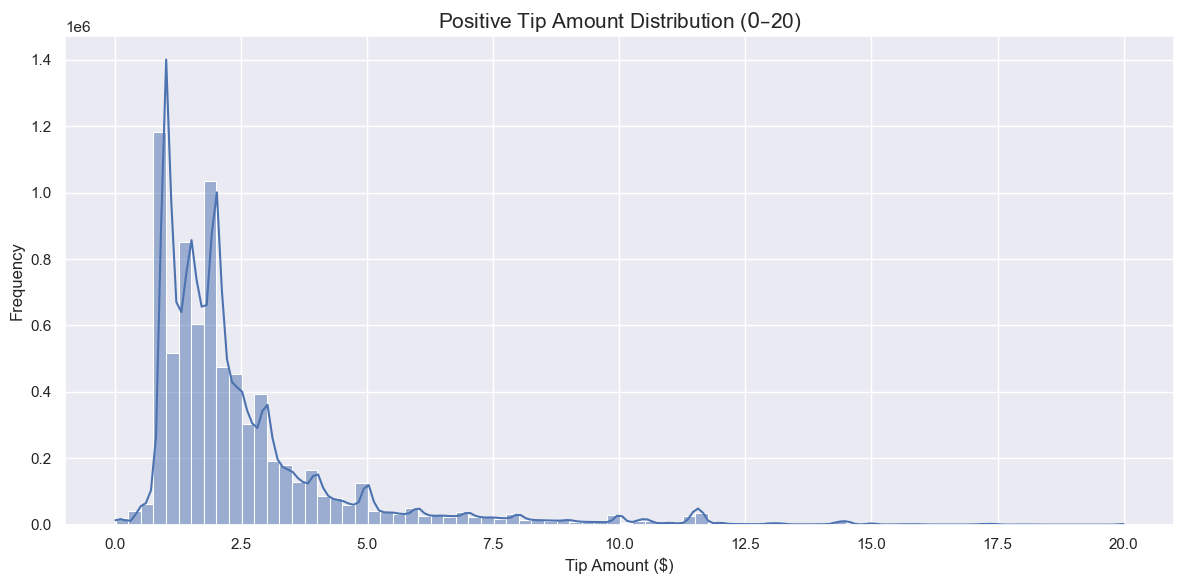

In [67]:
# ============================================================
# Positive Tip Amount Distribution
# ============================================================

# Plot positive tip amounts up to $20
# to make the main distribution clearly visible
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df[
        (df["tip_amount"] > 0) &
        (df["tip_amount"] <= 20)
    ],
    x="tip_amount",
    bins=80,
    kde=True
)

# Add chart title and axis labels
plt.title(
    "Positive Tip Amount Distribution ($0–$20)",
    fontsize=15
)

plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")

# Improve chart layout
plt.tight_layout()

plt.show()

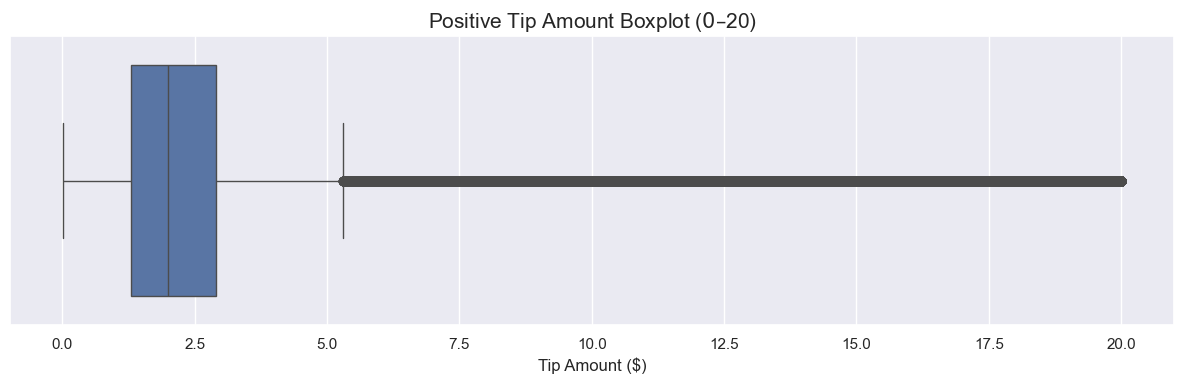

In [68]:
# ============================================================
# Positive Tip Amount Boxplot
# ============================================================

# Display positive tips up to $20
# to prevent extreme values from compressing the chart
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=df[
        (df["tip_amount"] > 0) &
        (df["tip_amount"] <= 20)
    ],
    x="tip_amount"
)

# Add chart title and axis label
plt.title(
    "Positive Tip Amount Boxplot ($0–$20)",
    fontsize=15
)

plt.xlabel("Tip Amount ($)")

# Improve chart layout
plt.tight_layout()

plt.show()

In [69]:
# ============================================================
# Positive Tip Amount Summary
# ============================================================

# Create a summary table for positive recorded tips
positive_tip_summary = pd.DataFrame({
    
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    
    "Value": [
        positive_tips.mean(),
        positive_tips.median(),
        positive_tips.std(),
        positive_tips.min(),
        positive_tips.max()
    ]
})

# Display the summary table
positive_tip_summary

,Statistic,Value
0,Mean,3.105294e+00
1,Median,2.000000e+00
2,Standard Deviation,1.431982e+03
3,Minimum,1.000000e-02
4,Maximum,3.950589e+06


In [70]:
# ============================================================
# Tip Amount Skewness
# ============================================================

# Calculate skewness using all recorded tip amounts
all_tip_skewness = (
    df["tip_amount"].skew()
)

# Calculate skewness using positive tips only
positive_tip_skewness = (
    positive_tips.skew()
)

# Display the results
print(
    f"All Tip Amounts Skewness      : "
    f"{all_tip_skewness:.2f}"
)

print(
    f"Positive Tip Amounts Skewness : "
    f"{positive_tip_skewness:.2f}"
)

All Tip Amounts Skewness      : 3570.55
Positive Tip Amounts Skewness : 2758.82


In [71]:
# ============================================================
# Positive Tip Amount Ranges
# ============================================================

# Define tip amount intervals
tip_bins = [
    0,
    1,
    2,
    3,
    5,
    10,
    20,
    float("inf")
]

# Define labels for each interval
tip_labels = [
    "$0–1",
    "$1–2",
    "$2–3",
    "$3–5",
    "$5–10",
    "$10–20",
    ">$20"
]

# Group positive recorded tips into ranges
tip_ranges = pd.cut(
    
    positive_tips,
    
    bins=tip_bins,
    labels=tip_labels,
    include_lowest=False,
    right=True
)

# Count trips in each tip range
tip_range_counts = (
    tip_ranges
    .value_counts()
    .sort_index()
)

# Calculate percentages among
# positive-tip trips only
tip_range_percentage = (
    tip_range_counts /
    tip_range_counts.sum()
) * 100

# Combine counts and percentages
# into one summary table
tip_range_summary = pd.DataFrame({
    
    "Trips": tip_range_counts,
    
    "Percentage": (
        tip_range_percentage.round(2)
    )
})

# Display the final table
tip_range_summary

,Trips,Percentage
tip_amount,,
$0–1,1307869,17.18
$1–2,3005966,39.49
$2–3,1625872,21.36
$3–5,1016731,13.36
$5–10,486502,6.39
$10–20,160941,2.11
>$20,7259,0.10


### Tip Amount Analysis — Key Findings

- Positive recorded tips were observed in **7,611,140 trips**, representing approximately **59.70%** of the dataset.

- Approximately **40.30%** of trips had a recorded tip amount equal to zero. However, a zero recorded tip does not necessarily indicate that no tip was given because cash tips may not be captured in the dataset.

- Only **79 trips (0.0006%)** contained negative tip values. Although these records represented a negligible proportion of the dataset, they should be investigated during the data-cleaning stage.

- When all trips were included, the median recorded tip was **$1.00**:
  - 75% of trips had recorded tips of **$2.06 or less**.
  - 90% had recorded tips of **$3.56 or less**.
  - 95% had recorded tips of **$5.12 or less**.
  - 99% had recorded tips of **$11.30 or less**.

- Among trips with positive recorded tips, the median tip was **$2.00**, indicating that a typical positive recorded tip was approximately $2.

- Positive-tip percentiles showed that:
  - 25% of positive tips were **$1.30 or less**.
  - 75% were **$2.90 or less**.
  - 90% were **$4.85 or less**.
  - 95% were **$7.00 or less**.
  - 99% were **$11.63 or less**.

- Approximately **39.49%** of positive tips were between **$1 and $2**, making this the most common tip range.

- Approximately **78.03%** of positive recorded tips were **$3 or less**, while approximately **91.39%** were **$5 or less**.

- Only **7,259 positive tips (0.10%)** exceeded $20, indicating that very large tips were extremely uncommon.

- The positive-tip distribution was strongly right-skewed. Most recorded tips were concentrated between approximately $1 and $3, followed by a long right tail.

- The maximum recorded tip was approximately **$3.95 million**, which is unlikely to represent normal passenger tipping behavior and should be investigated as a potential data-quality issue.

- The extreme maximum value heavily inflated the mean, standard deviation, and skewness:
  - Mean positive tip: approximately **$3.11**
  - Median positive tip: **$2.00**
  - Standard deviation: approximately **$1,431.98**
  - Positive-tip skewness: **2758.82**

- Therefore, the median and percentiles provide more reliable descriptions of typical tipping behavior than the mean and standard deviation.

### Business Insight

Recorded tipping was common, with positive tips appearing in approximately **60% of all trips**.

When a positive tip was recorded, the typical amount was approximately **$2**, and more than **nine out of ten positive tips were $5 or less**. This suggests that tipping behavior was generally concentrated around small and moderate amounts rather than large individual tips.

Further analysis of `payment_type` is required because recorded tip behavior may differ substantially between payment methods.

## 3.6 Payment Type Analysis

This section analyzes the distribution of payment methods and investigates how recorded tipping behavior differs across payment types.

The analysis aims to answer the following questions:

- Which payment method was used most frequently?
- What percentage of trips used each payment method?
- How does recorded tipping behavior vary across payment methods?
- Are zero recorded tips associated with specific payment methods?

In [72]:
# ============================================================
# Payment Type Frequency
# ============================================================

# Count the number of trips for each payment type
payment_counts = (
    df["payment_type"]
    .value_counts()
    .sort_index()
)

# Calculate the percentage of trips for each payment type
payment_percentage = (
    df["payment_type"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Display the frequency table
payment_counts

payment_type
1    7881388
2    4816992
3      38632
4      11972
5          2
Name: count, dtype: int64

In [73]:
# ============================================================
# Payment Type Summary Table
# ============================================================

# Combine trip counts and percentages into one table
payment_summary = pd.DataFrame({
    "Trips": payment_counts,
    "Percentage": payment_percentage
})

# Round percentages to three decimal places
payment_summary["Percentage"] = (
    payment_summary["Percentage"]
    .round(3)
)

# Display the summary table
payment_summary

,Trips,Percentage
payment_type,,
1,7881388,61.820
2,4816992,37.783
3,38632,0.303
4,11972,0.094
5,2,0.000


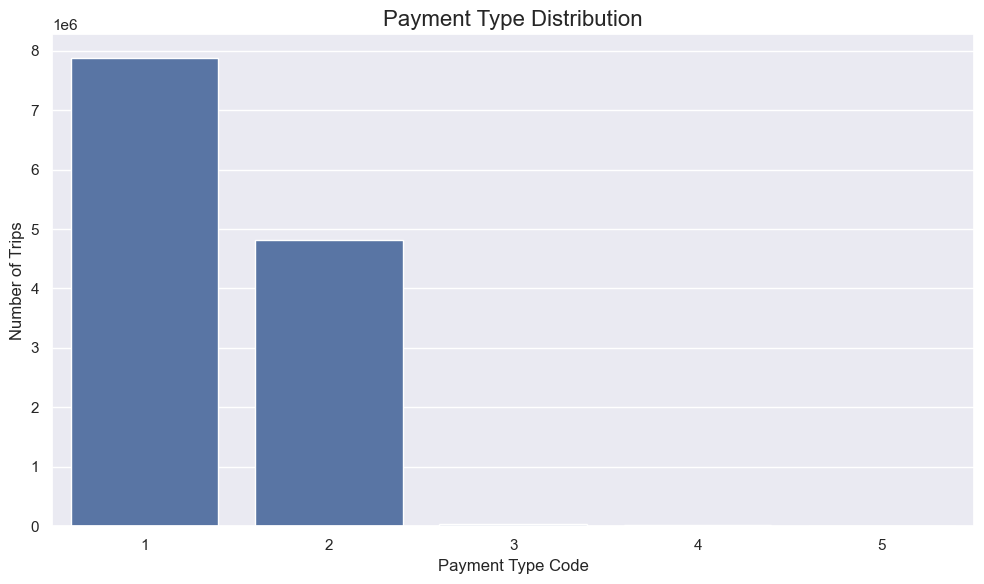

In [74]:
# ============================================================
# Payment Type Distribution
# ============================================================

# Create a bar chart showing the number of trips
# recorded for each payment type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

# Add chart title and axis labels
plt.title(
    "Payment Type Distribution",
    fontsize=16
)

plt.xlabel(
    "Payment Type Code",
    fontsize=12
)

plt.ylabel(
    "Number of Trips",
    fontsize=12
)

# Improve chart layout
plt.tight_layout()

# Display the chart
plt.show()

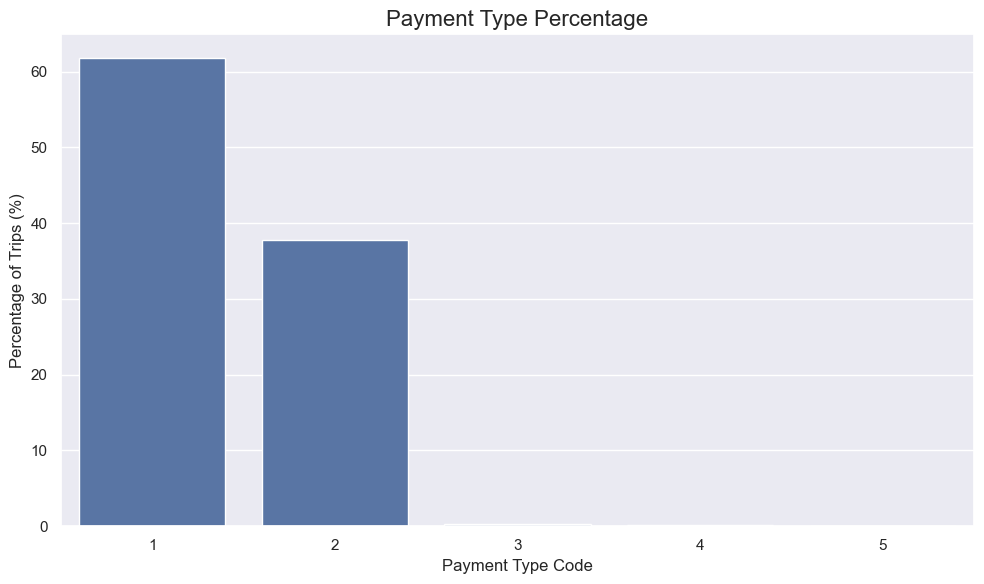

In [75]:
# ============================================================
# Payment Type Percentage
# ============================================================

# Create a bar chart showing the percentage
# of trips for each payment type
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_percentage.index,
    y=payment_percentage.values
)

# Add chart title and axis labels
plt.title(
    "Payment Type Percentage",
    fontsize=16
)

plt.xlabel(
    "Payment Type Code",
    fontsize=12
)

plt.ylabel(
    "Percentage of Trips (%)",
    fontsize=12
)

# Improve chart layout
plt.tight_layout()

# Display the chart
plt.show()

In [76]:
# ============================================================
# Map Payment Type Codes to Payment Method Names
# ============================================================

# Create a dictionary that maps each payment code
# to its corresponding payment method
payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown"
}

# Create a new column containing readable payment method names
# while keeping the original payment_type column unchanged
df["payment_method"] = (
    df["payment_type"]
    .map(payment_labels)
)

# Display the number of trips for each payment method
df["payment_method"].value_counts()

payment_method
Credit Card    7881388
Cash           4816992
No Charge        38632
Dispute          11972
Unknown              2
Name: count, dtype: int64

In [77]:
# ============================================================
# Payment Method Summary Table
# ============================================================

# Count trips for each payment method
payment_method_counts = (
    df["payment_method"]
    .value_counts()
)

# Calculate the percentage of trips
# for each payment method
payment_method_percentage = (
    df["payment_method"]
    .value_counts(normalize=True)
    * 100
)

# Combine trip counts and percentages
# into one summary table
payment_method_summary = pd.DataFrame({
    "Trips": payment_method_counts,
    "Percentage": payment_method_percentage
})

# Round percentages to three decimal places
payment_method_summary["Percentage"] = (
    payment_method_summary["Percentage"]
    .round(3)
)

# Display the summary table
payment_method_summary

,Trips,Percentage
payment_method,,
Credit Card,7881388,61.820
Cash,4816992,37.783
No Charge,38632,0.303
Dispute,11972,0.094
Unknown,2,0.000


In [78]:
# ============================================================
# Tip Statistics by Payment Method
# ============================================================

# Calculate tip statistics
# for each payment method
tip_by_payment = (
    df.groupby("payment_method")["tip_amount"]
    .agg(
        Trips="count",
        Mean_Tip="mean",
        Median_Tip="median",
        Total_Tips="sum"
    )
)

# Round monetary values
# to two decimal places
tip_by_payment[
    [
        "Mean_Tip",
        "Median_Tip",
        "Total_Tips"
    ]
] = (
    tip_by_payment[
        [
            "Mean_Tip",
            "Median_Tip",
            "Total_Tips"
        ]
    ]
    .round(2)
)

# Sort payment methods
# by the number of trips
tip_by_payment = (
    tip_by_payment
    .sort_values(
        "Trips",
        ascending=False
    )
)

# Display the results
tip_by_payment

,Trips,Mean_Tip,Median_Tip,Total_Tips
payment_method,,,,
Credit Card,7881388,3.00,1.95,23633445.39
Cash,4816992,0.00,0.00,1028.78
No Charge,38632,0.00,0.00,22.85
Dispute,11972,-0.02,0.00,-252.80
Unknown,2,0.00,0.00,0.00


In [79]:
# ============================================================
# Positive Tip Rate by Payment Method
# ============================================================

# Create a Boolean column:
# True if the recorded tip is positive
# False if the tip is zero or negative
df["has_positive_tip"] = (
    df["tip_amount"] > 0
)

# Calculate the percentage of trips
# with positive recorded tips
# for each payment method
positive_tip_rate = (
    df.groupby("payment_method")
    ["has_positive_tip"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(
        ascending=False
    )
    .to_frame(
        name="Positive Tip Rate (%)"
    )
)

# Display the results
positive_tip_rate

,Positive Tip Rate (%)
payment_method,
Credit Card,96.57
Dispute,0.10
No Charge,0.07
Cash,0.00
Unknown,0.00


### Payment Type Analysis — Key Findings

- Credit Card was the dominant payment method, accounting for **61.82%** of all trips.

- Cash represented **37.78%** of all trips.

- Credit Card and Cash payments together accounted for approximately **99.60%** of the dataset.

- Credit Card trips recorded an average tip of approximately **$3.00** and a median tip of **$1.95**.

- Approximately **96.57%** of Credit Card trips contained a positive recorded tip.

- Cash trips recorded almost no tips in the `tip_amount` field. However, this should not be interpreted as evidence that cash passengers did not tip because cash tips are generally not captured by the electronic payment records.

- The large difference between Credit Card and Cash recorded tips is primarily influenced by the data collection mechanism rather than necessarily representing actual passenger tipping behavior.

- Therefore, detailed tipping behavior analysis should primarily focus on Credit Card trips, where tip information is systematically recorded.

- Negative tip values associated with disputed transactions may represent payment corrections, refunds, or abnormal records and should be investigated during the data-cleaning stage.

# 4. Temporal Analysis

## 4.1 Convert Date Columns

In [80]:
# ============================================================
# Datetime Conversion
# ============================================================

# Convert pickup datetime from string to datetime
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)

# Convert dropoff datetime from string to datetime
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

# Display updated data types
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
].dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
dtype: object

In [81]:
# ============================================================
# Verify Datetime Conversion
# ============================================================

# Display the first few converted datetime values
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
].head()

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2015-01-15 19:05:39,2015-01-15 19:23:42
1,2015-01-10 20:33:38,2015-01-10 20:53:28
2,2015-01-10 20:33:38,2015-01-10 20:43:41
3,2015-01-10 20:33:39,2015-01-10 20:35:31
4,2015-01-10 20:33:39,2015-01-10 20:52:58


### 4.1 Datetime Conversion

The pickup and dropoff timestamps were originally stored as string values.

Both columns were converted to the `datetime64[ns]` data type to enable temporal analysis.

This conversion allows extraction of:

- Hour of day
- Day of week
- Date
- Trip duration
- Time-based aggregations

These derived features will be used throughout the temporal analysis section.

## 4.2 Feature Extraction

In [82]:
# ============================================================
# Extract Time Features
# ============================================================

# Extract pickup hour (0–23)
df["pickup_hour"] = (
    df["tpep_pickup_datetime"]
    .dt.hour
)

# Extract pickup weekday
# Monday = 0 ... Sunday = 6
df["pickup_weekday"] = (
    df["tpep_pickup_datetime"]
    .dt.dayofweek
)

# Extract weekday name
df["pickup_day_name"] = (
    df["tpep_pickup_datetime"]
    .dt.day_name()
)

# Extract pickup date only
df["pickup_date"] = (
    df["tpep_pickup_datetime"]
    .dt.date
)

# Extract pickup month
df["pickup_month"] = (
    df["tpep_pickup_datetime"]
    .dt.month
)

# Extract pickup week number
df["pickup_week"] = (
    df["tpep_pickup_datetime"]
    .dt.isocalendar()
    .week
)

# Display sample
df[
    [
        "tpep_pickup_datetime",
        "pickup_hour",
        "pickup_weekday",
        "pickup_day_name",
        "pickup_date",
        "pickup_month",
        "pickup_week"
    ]
].head()

,tpep_pickup_datetime,pickup_hour,pickup_weekday,pickup_day_name,pickup_date,pickup_month,pickup_week
0,2015-01-15 19:05:39,19,3,Thursday,2015-01-15,1,3
1,2015-01-10 20:33:38,20,5,Saturday,2015-01-10,1,2
2,2015-01-10 20:33:38,20,5,Saturday,2015-01-10,1,2
3,2015-01-10 20:33:39,20,5,Saturday,2015-01-10,1,2
4,2015-01-10 20:33:39,20,5,Saturday,2015-01-10,1,2


In [83]:
# ============================================================
# Display Extracted Time Features Information
# ============================================================

time_features = [
    "pickup_hour",
    "pickup_weekday",
    "pickup_day_name",
    "pickup_date",
    "pickup_month",
    "pickup_week"
]

df[time_features].head()

,pickup_hour,pickup_weekday,pickup_day_name,pickup_date,pickup_month,pickup_week
0,19,3,Thursday,2015-01-15,1,3
1,20,5,Saturday,2015-01-10,1,2
2,20,5,Saturday,2015-01-10,1,2
3,20,5,Saturday,2015-01-10,1,2
4,20,5,Saturday,2015-01-10,1,2


## 4.3 Trip Duration Analysis

In [84]:
# ============================================================
# Calculate Trip Duration
# ============================================================

# Calculate trip duration in minutes
df["trip_duration"] = (
    (
        df["tpep_dropoff_datetime"]
        - df["tpep_pickup_datetime"]
    )
    .dt.total_seconds()
    / 60
)

# Display sample
df[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration"
    ]
].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration
0,2015-01-15 19:05:39,2015-01-15 19:23:42,18.050000
1,2015-01-10 20:33:38,2015-01-10 20:53:28,19.833333
2,2015-01-10 20:33:38,2015-01-10 20:43:41,10.050000
3,2015-01-10 20:33:39,2015-01-10 20:35:31,1.866667
4,2015-01-10 20:33:39,2015-01-10 20:52:58,19.316667


In [85]:
# ============================================================
# Trip Duration Summary Statistics
# ============================================================

# Display descriptive statistics
df["trip_duration"].describe()

count    1.274899e+07
mean     1.417900e+01
std      6.493012e+02
min     -1.211017e+03
25%      6.100000e+00
50%      9.950000e+00
75%      1.578333e+01
max      5.485556e+05
Name: trip_duration, dtype: float64

In [86]:
# ============================================================
# Trip Duration Percentiles
# ============================================================

# Calculate important percentiles
duration_percentiles = (
    df["trip_duration"]
    .quantile([0.25,0.50,0.75,0.90,0.95,0.99])
    .to_frame(name="Duration (Minutes)")
)

duration_percentiles

,Duration (Minutes)
0.25,6.100000
0.50,9.950000
0.75,15.783333
0.90,23.450000
0.95,29.583333
0.99,46.750000


In [87]:
# ============================================================
# Negative Trip Durations
# ============================================================

# Trips with negative duration
negative_duration = (
    df["trip_duration"] < 0
)

negative_count = negative_duration.sum()

negative_percentage = (
    negative_count
    / len(df)
    *100
)

print(
    f"Negative Trips : {negative_count:,}"
)

print(
    f"Percentage : {negative_percentage:.4f}%"
)

Negative Trips : 297
Percentage : 0.0023%


In [88]:
# ============================================================
# Zero Duration Trips
# ============================================================

zero_duration = (
    df["trip_duration"] == 0
)

print(
    f"Zero Duration Trips : {zero_duration.sum():,}"
)

Zero Duration Trips : 14,816


In [89]:
# ============================================================
# Trips Longer Than 2 Hours
# ============================================================

long_trips = (
    df["trip_duration"] > 120
)

print(
    f"Trips > 120 Minutes : {long_trips.sum():,}"
)

df.loc[
    long_trips,
    [
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "total_amount"
    ]
].head()

Trips > 120 Minutes : 11,480


,trip_distance,trip_duration,fare_amount,total_amount
1365,21.40,120.916667,92.8,132.18
3160,11.80,364.300000,36.5,38.30
4012,2.73,1438.766667,13.5,16.75
4598,0.53,1427.616667,5.0,5.80
4879,25.42,137.633333,115.5,137.55


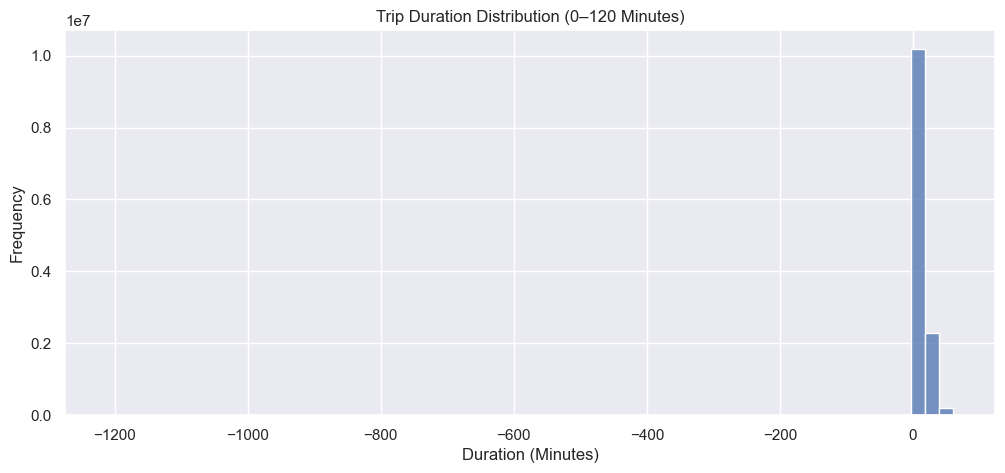

In [90]:
# ============================================================
# Trip Duration Distribution
# ============================================================

plt.figure(figsize=(12,5))

sns.histplot(
    df.loc[
        df["trip_duration"] <=60,
        "trip_duration"
    ],
    bins=60
)

plt.title(
    "Trip Duration Distribution (0–120 Minutes)"
)

plt.xlabel(
    "Duration (Minutes)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

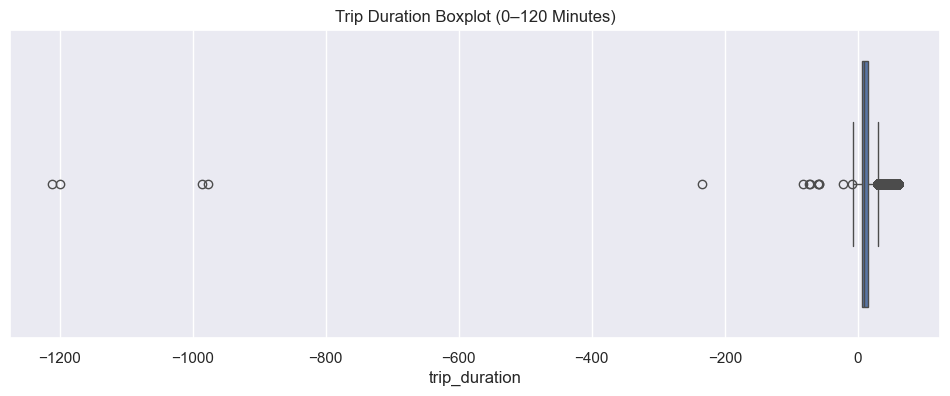

In [91]:
# ============================================================
# Trip Duration Boxplot
# ============================================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df.loc[
        df["trip_duration"] <=60,
        "trip_duration"
    ]
)

plt.title(
    "Trip Duration Boxplot (0–120 Minutes)"
)

plt.show()

In [92]:
# ============================================================
# Trip Duration Summary
# ============================================================

trip_duration_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Median",
        "Std",
        "Minimum",
        "Maximum"
    ],

    "Value":[
        df["trip_duration"].mean(),
        df["trip_duration"].median(),
        df["trip_duration"].std(),
        df["trip_duration"].min(),
        df["trip_duration"].max()
    ]

})

trip_duration_summary

,Statistic,Value
0,Mean,14.179004
1,Median,9.950000
2,Std,649.301159
3,Minimum,-1211.016667
4,Maximum,548555.633333


In [93]:
# ============================================================
# Trip Duration Skewness
# ============================================================

trip_duration_skewness = (
    df["trip_duration"].skew()
)

print(
    f"Trip Duration Skewness : {trip_duration_skewness:.2f}"
)

Trip Duration Skewness : 794.11


In [94]:
# ============================================================
# Create Clean Dataset for Temporal Analysis
# ============================================================

# Keep only trips with a realistic duration
# between 1 minute and 120 minutes

df_clean = df[
    (
        df["trip_duration"] >= 1
    )
    &
    (
        df["trip_duration"] <= 120
    )
].copy()

print(f"Original Dataset : {len(df):,}")

print(f"Clean Dataset    : {len(df_clean):,}")

print(
    f"Removed Trips    : {len(df)-len(df_clean):,}"
)

Original Dataset : 12,748,986
Clean Dataset    : 12,634,080
Removed Trips    : 114,906


In [95]:
df_clean["trip_duration"].describe()

count    1.263408e+07
mean     1.236157e+01
std      9.121133e+00
min      1.000000e+00
25%      6.183333e+00
50%      1.001667e+01
75%      1.583333e+01
max      1.200000e+02
Name: trip_duration, dtype: float64

In [96]:
# ============================================================
# Trip Duration Skewness After Cleaning
# ============================================================

clean_duration_skewness = df_clean["trip_duration"].skew()

print(
    f"Trip Duration Skewness (Clean Data): {clean_duration_skewness:.2f}"
)

Trip Duration Skewness (Clean Data): 2.24


### Trip Duration Analysis Summary

- Removed trips with:
  - Negative duration.
  - Zero duration.
  - Duration greater than 120 minutes.

- Dataset size:
  - Original: **12,748,986**
  - Cleaned: **12,634,080**
  - Removed: **114,906 trips** (~0.90%)

- Trip duration statistics after cleaning:
  - Mean: **12.36 minutes**
  - Median: **10.02 minutes**
  - Maximum: **120 minutes**

- Distribution remains right-skewed, which is expected for taxi trips.
- Skewness decreased dramatically:
  - Before cleaning: **794.11**
  - After cleaning: **2.24**

**Conclusion:**  
The cleaning process successfully removed unrealistic trip durations while preserving the natural distribution of taxi trips. The cleaned duration feature is now suitable for temporal analysis and predictive modeling.

## 4.4 Hourly Analysis

In [97]:
# ============================================================
# Hourly Trip Count
# ============================================================

# Count trips for each pickup hour
hourly_trips = (
    df_clean
    .groupby("pickup_hour")
    .size()
    .rename("Trips")
)

# Convert to DataFrame
hourly_trips = hourly_trips.to_frame()

# Calculate percentage of total trips
hourly_trips["Percentage"] = (
    hourly_trips["Trips"]
    / len(df_clean)
    * 100
).round(2)

# Display the summary table
hourly_trips

,Trips,Percentage
pickup_hour,,
0,464818,3.68
1,350959,2.78
2,264465,2.09
3,195251,1.55
4,140261,1.11
5,124483,0.99
6,264472,2.09
7,451928,3.58
8,557526,4.41


### Hourly Demand Summary

- Taxi demand is lowest between **2 AM and 5 AM**.
- Demand starts increasing rapidly after **6 AM**.
- Activity remains relatively stable during midday.
- Peak demand occurs during the evening.
- The busiest hour is **7 PM (19:00)** with **799,329 trips (6.33%)**.
- Overall evening rush hour spans approximately **6 PM to 10 PM**.

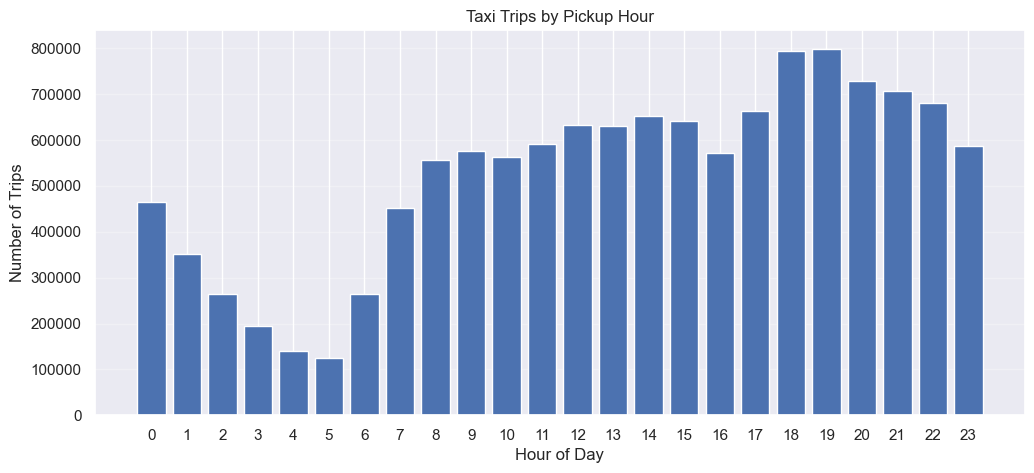

In [98]:
# ============================================================
# Hourly Trip Distribution
# ============================================================

plt.figure(figsize=(12,5))

plt.bar(
    hourly_trips.index,
    hourly_trips["Trips"]
)

plt.title("Taxi Trips by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Number of Trips")

plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.show()

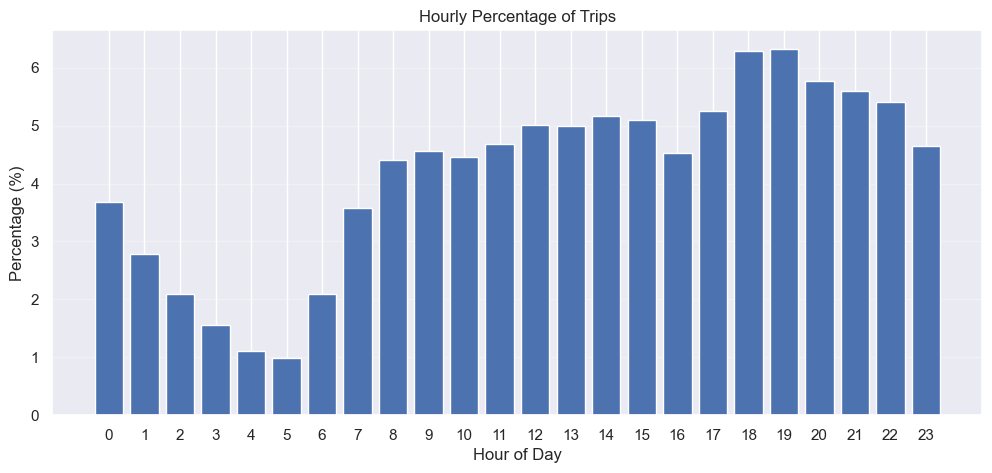

In [99]:
# ============================================================
# Hourly Trip Percentage
# ============================================================

plt.figure(figsize=(12,5))

plt.bar(
    hourly_trips.index,
    hourly_trips["Percentage"]
)

plt.title("Hourly Percentage of Trips")

plt.xlabel("Hour of Day")

plt.ylabel("Percentage (%)")

plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.show()

### Hourly Pickup Demand

The hourly distribution reveals a clear daily demand pattern.

Key observations:

- Demand reaches its lowest level between **2 AM and 5 AM**.
- Pickup activity starts increasing rapidly after **6 AM**.
- Demand remains relatively stable from **11 AM to 4 PM**.
- The busiest period is the evening.
- Peak demand occurs at **7 PM**, accounting for approximately **6.33%** of all trips.
- Evening demand (6–10 PM) is consistently higher than morning demand, indicating stronger travel activity after work hours.

**Conclusion**

Taxi demand follows a typical urban commuting pattern with two demand waves, while the evening period represents the primary daily peak.

In [100]:
# ============================================================
# Hourly Business Metrics
# ============================================================

# Aggregate key business metrics by pickup hour
hourly_metrics = (
    df_clean
    .groupby("pickup_hour")
    .agg(
        Trips=("pickup_hour", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
    .round(2)
)

# Display the summary table
hourly_metrics

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_hour,,,,,,,
0,464818,3.27,12.04,12.65,15.77,1.66,7328109.02
1,350959,4.76,11.83,12.51,15.52,1.59,5445558.88
2,264465,3.25,11.75,12.47,15.40,1.54,4071907.79
3,195251,3.50,11.77,12.97,15.90,1.52,3104430.21
4,140261,4.09,12.06,14.55,17.74,1.57,2487999.01
5,124483,4.61,11.64,15.61,19.44,1.95,2419969.84
6,264472,4.09,10.87,12.82,15.70,1.64,4151937.22
7,451928,2.85,12.01,11.73,14.33,1.53,6477356.94
8,557526,2.48,12.98,11.51,14.06,1.55,7840741.84


In [101]:
# ============================================================
# Final Dataset Cleaning
# ============================================================

# Create a copy of the original dataset
df_clean = df.copy()

# Keep only realistic trips based on business rules
df_clean = df_clean[
    # Trip duration
    (df_clean["trip_duration"] >= 1) &
    (df_clean["trip_duration"] <= 120) &

    # Trip distance
    (df_clean["trip_distance"] > 0) &
    (df_clean["trip_distance"] <= 30) &

    # Fare amount
    (df_clean["fare_amount"] >= 0) &
    (df_clean["fare_amount"] <= 100) &

    # Total amount
    (df_clean["total_amount"] >= 0) &
    (df_clean["total_amount"] <= 150) &

    # Tip amount
    (df_clean["tip_amount"] >= 0) &
    (df_clean["tip_amount"] <= 20)
].copy()

In [102]:
# ============================================================
# Dataset Size After Final Cleaning
# ============================================================

print(f"Original Dataset : {len(df):,}")
print(f"Clean Dataset    : {len(df_clean):,}")

removed = len(df) - len(df_clean)

print(f"Removed Trips    : {removed:,}")

print(
    f"Removed Percentage : {removed / len(df) * 100:.2f}%"
)

Original Dataset : 12,748,986
Clean Dataset    : 12,607,239
Removed Trips    : 141,747
Removed Percentage : 1.11%


In [103]:
# ============================================================
# Validate Clean Dataset
# ============================================================

summary = pd.DataFrame({
    "Minimum": df_clean[
        [
            "trip_distance",
            "trip_duration",
            "fare_amount",
            "tip_amount",
            "total_amount"
        ]
    ].min(),

    "Maximum": df_clean[
        [
            "trip_distance",
            "trip_duration",
            "fare_amount",
            "tip_amount",
            "total_amount"
        ]
    ].max()
})

summary

,Minimum,Maximum
trip_distance,0.01,30.00
trip_duration,1.00,119.90
fare_amount,0.00,100.00
tip_amount,0.00,20.00
total_amount,0.00,148.13


### Final Dataset Cleaning

A final cleaning step was performed using business rules derived from the EDA findings.

Applied filters:

- Trip Duration: **1–120 minutes**
- Trip Distance: **0–30 miles**
- Fare Amount: **$0–100**
- Tip Amount: **$0–20**
- Total Amount: **$0–150**

Dataset Summary:

| Metric | Value |
|---------|------:|
| Original Trips | 12,748,986 |
| Clean Trips | 12,607,239 |
| Removed Trips | 141,747 |
| Removed Percentage | 1.11% |

The resulting dataset contains only realistic taxi trips and will be used for all subsequent analyses.

In [104]:
# ============================================================
# Hourly Business Metrics (Clean Dataset)
# ============================================================

# Aggregate business metrics by pickup hour
hourly_metrics = (
    df_clean
    .groupby("pickup_hour")
    .agg(
        Trips=("pickup_hour", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
    .round(2)
)

# Display the table
hourly_metrics

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_hour,,,,,,,
0,463766,3.26,12.03,12.59,15.68,1.64,7271892.98
1,350045,3.23,11.83,12.44,15.42,1.57,5398854.45
2,263571,3.23,11.75,12.39,15.29,1.51,4030072.09
3,194463,3.46,11.77,12.89,15.79,1.48,3070692.04
4,139565,4.08,12.05,14.45,17.60,1.53,2456534.88
5,123886,4.58,11.61,15.50,19.28,1.91,2388592.38
6,263668,3.50,10.84,12.75,15.60,1.62,4112191.82
7,450984,2.83,11.99,11.67,14.25,1.52,6427674.98
8,556435,2.47,12.97,11.46,14.00,1.53,7792548.15


### Hourly Business Metrics

Hourly aggregation reveals several important business insights.

Key observations:

- Trips during the early morning (4–5 AM) have the **longest average distances**.
- Afternoon trips have the **longest average durations**, suggesting heavier traffic congestion.
- Average fare is highest during early morning hours due to longer travel distances.
- Average tip remains relatively stable throughout the day (approximately \$1.4–\$1.9).
- Total revenue closely follows trip demand.

Business Insights:

- Evening hours (6–9 PM) generate the highest revenue primarily because of higher trip volume.
- Early morning trips generate higher revenue per trip due to longer travel distances and higher fares.
- Longer trip duration during afternoon hours appears to be caused by traffic rather than longer travel distances.

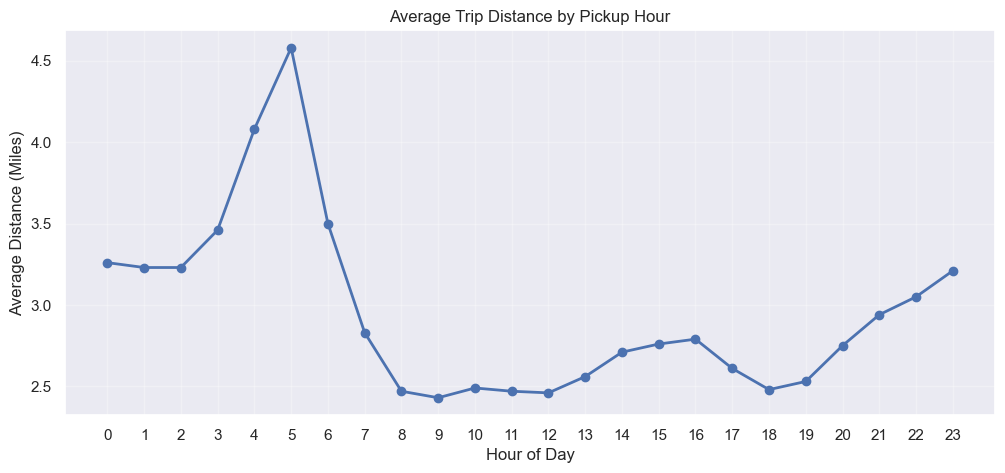

In [105]:
# ============================================================
# Average Trip Distance by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Distance"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Distance by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Distance (Miles)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

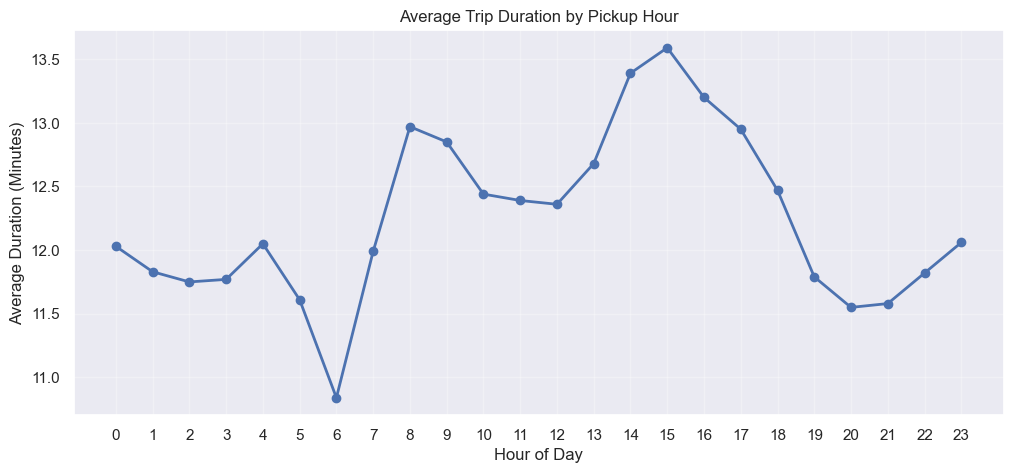

In [106]:
# ============================================================
# Average Trip Duration by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Duration"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Duration by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Duration (Minutes)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

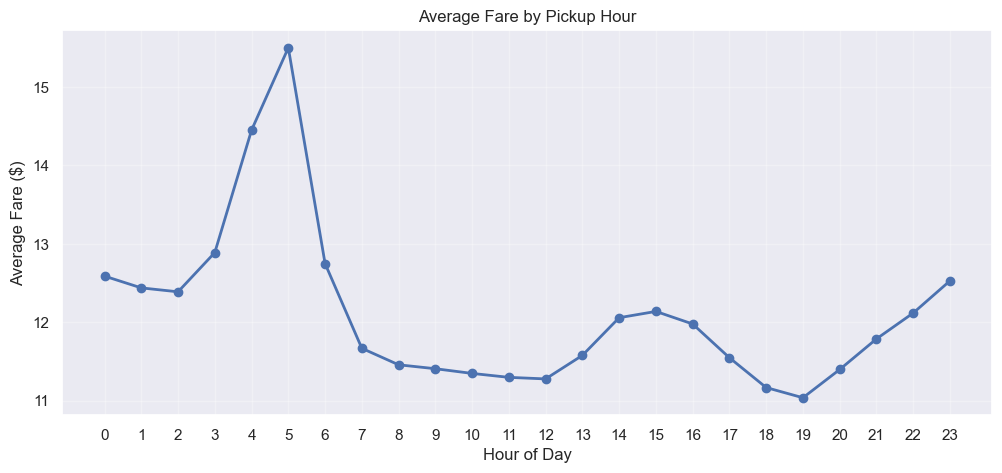

In [107]:
# ============================================================
# Average Fare by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Fare"],
    marker="o",
    linewidth=2
)

plt.title("Average Fare by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Fare ($)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

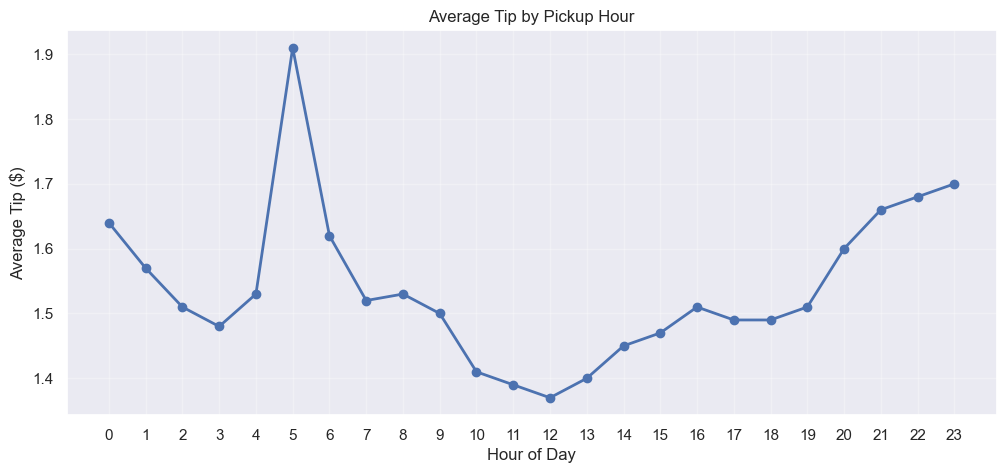

In [108]:
# ============================================================
# Average Tip by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Avg_Tip"],
    marker="o",
    linewidth=2
)

plt.title("Average Tip by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Tip ($)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

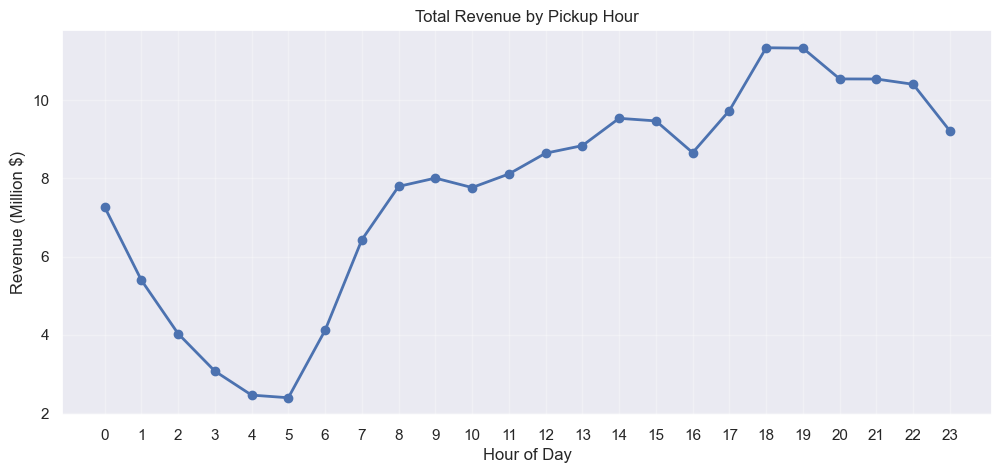

In [109]:
# ============================================================
# Total Revenue by Hour
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_metrics.index,
    hourly_metrics["Total_Revenue"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.title("Total Revenue by Pickup Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Revenue (Million $)")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

In [110]:
# ============================================================
# Peak Hours Summary
# ============================================================

peak_summary = pd.DataFrame({
    "Highest Trips": [
        hourly_metrics["Trips"].idxmax(),
        hourly_metrics["Trips"].max()
    ],

    "Highest Revenue": [
        hourly_metrics["Total_Revenue"].idxmax(),
        hourly_metrics["Total_Revenue"].max()
    ],

    "Longest Distance": [
        hourly_metrics["Avg_Distance"].idxmax(),
        hourly_metrics["Avg_Distance"].max()
    ],

    "Longest Duration": [
        hourly_metrics["Avg_Duration"].idxmax(),
        hourly_metrics["Avg_Duration"].max()
    ],

    "Highest Fare": [
        hourly_metrics["Avg_Fare"].idxmax(),
        hourly_metrics["Avg_Fare"].max()
    ],

    "Highest Tip": [
        hourly_metrics["Avg_Tip"].idxmax(),
        hourly_metrics["Avg_Tip"].max()
    ]
},
index=["Hour", "Value"])

peak_summary

,Highest Trips,Highest Revenue,Longest Distance,Longest Duration,Highest Fare,Highest Tip
Hour,19,18.00,5.00,15.00,5.0,5.00
Value,798090,11338540.16,4.58,13.59,15.5,1.91


In [111]:
# ============================================================
# Trips by Weekday
# ============================================================

# Count trips for each weekday
weekday_counts = (
    df_clean["pickup_day_name"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

# Calculate percentages
weekday_percentage = (
    weekday_counts
    / weekday_counts.sum()
    * 100
).round(2)

# Create summary table
weekday_summary = pd.DataFrame({
    "Trips": weekday_counts,
    "Percentage": weekday_percentage
})

# Display summary
weekday_summary

,Trips,Percentage
pickup_day_name,,
Monday,1316967,10.45
Tuesday,1359398,10.78
Wednesday,1666085,13.22
Thursday,2143610,17.00
Friday,2202770,17.47
Saturday,2354101,18.67
Sunday,1564308,12.41


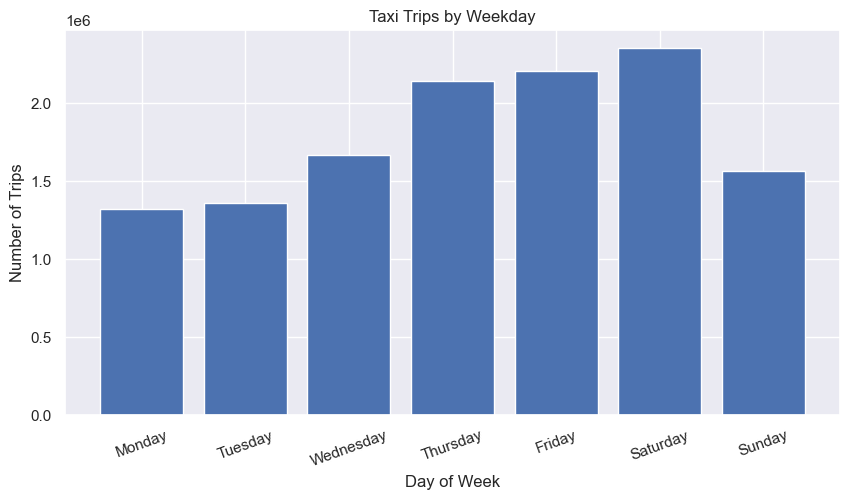

In [112]:
# ============================================================
# Trips by Weekday
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    weekday_summary.index,
    weekday_summary["Trips"]
)

plt.title("Taxi Trips by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Number of Trips")

plt.xticks(rotation=20)

plt.show()

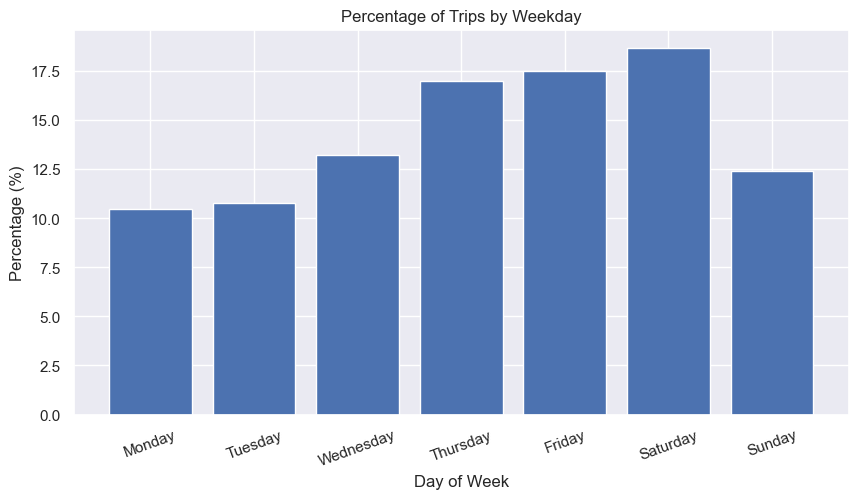

In [113]:
# ============================================================
# Weekday Percentage
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    weekday_summary.index,
    weekday_summary["Percentage"]
)

plt.title("Percentage of Trips by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=20)

plt.show()

In [114]:
# ============================================================
# Weekday Performance Summary
# ============================================================

# Calculate performance metrics for each weekday
weekday_stats = (
    df_clean
    .groupby("pickup_day_name")
    .agg(
        Trips=("pickup_day_name", "count"),
        Avg_Distance=("trip_distance", "mean"),
        Avg_Duration=("trip_duration", "mean"),
        Avg_Fare=("fare_amount", "mean"),
        Avg_Total=("total_amount", "mean"),
        Avg_Tip=("tip_amount", "mean"),
        Total_Revenue=("total_amount", "sum")
    )
)

# Reorder weekdays correctly
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_stats = weekday_stats.reindex(weekday_order)

# Round values for readability
weekday_stats = weekday_stats.round(2)

# Display the summary table
weekday_stats

,Trips,Avg_Distance,Avg_Duration,Avg_Fare,Avg_Total,Avg_Tip,Total_Revenue
pickup_day_name,,,,,,,
Monday,1316967,2.91,12.19,11.95,14.88,1.55,19596973.42
Tuesday,1359398,2.68,12.30,11.58,14.55,1.56,19779030.35
Wednesday,1666085,2.70,12.64,11.77,14.79,1.61,24639459.17
Thursday,2143610,2.83,13.03,12.18,15.17,1.59,32512832.12
Friday,2202770,2.77,13.05,12.01,14.99,1.55,33016165.37
Saturday,2354101,2.67,11.60,11.28,13.83,1.38,32558094.07
Sunday,1564308,3.03,11.41,11.94,14.67,1.49,22954586.75


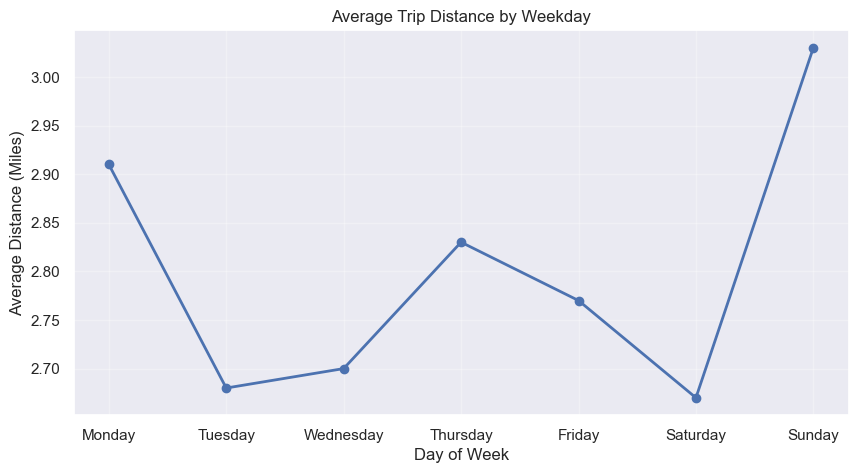

In [115]:
# ============================================================
# Average Trip Distance by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Distance"],
    marker="o",
    linewidth=2
)

plt.title("Average Trip Distance by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Distance (Miles)")

plt.grid(alpha=0.3)

plt.show()

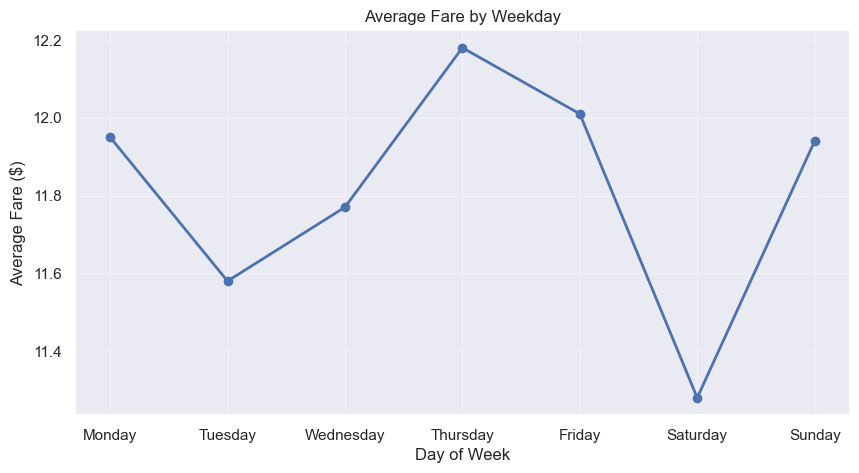

In [116]:
# ============================================================
# Average Fare by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Fare"],
    marker="o",
    linewidth=2
)

plt.title("Average Fare by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Fare ($)")

plt.grid(alpha=0.3)

plt.show()

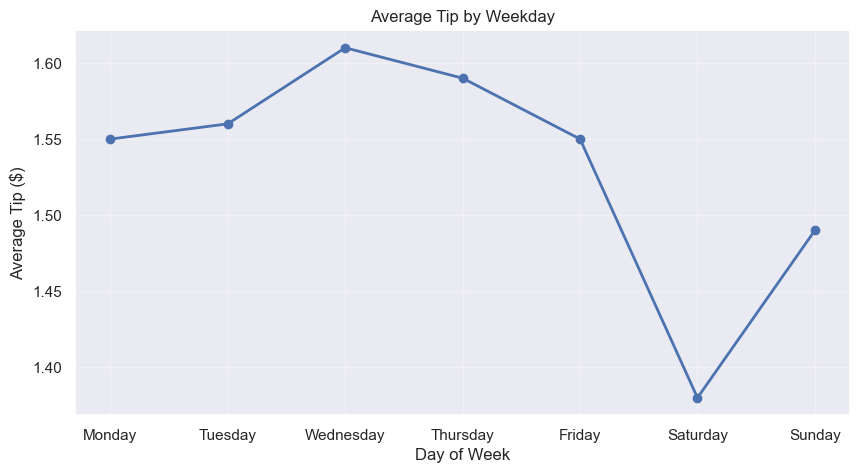

In [117]:
# ============================================================
# Average Tip by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Avg_Tip"],
    marker="o",
    linewidth=2
)

plt.title("Average Tip by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Average Tip ($)")

plt.grid(alpha=0.3)

plt.show()

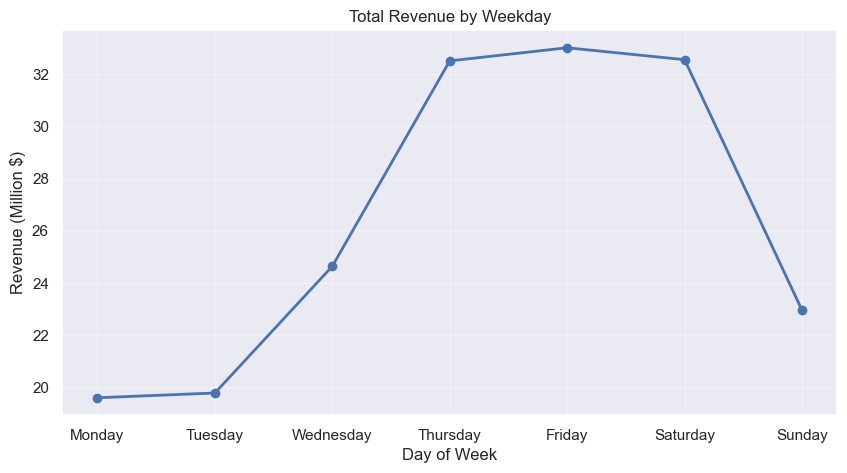

In [118]:
# ============================================================
# Total Revenue by Weekday
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats["Total_Revenue"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.title("Total Revenue by Weekday")

plt.xlabel("Day of Week")

plt.ylabel("Revenue (Million $)")

plt.grid(alpha=0.3)

plt.show()

### Business Insights

- Daily taxi demand remains relatively stable throughout January, averaging approximately **406,685 trips per day**.

- No clear upward or downward trend is observed across the month. Instead, the demand follows a recurring **weekly pattern**.

- Taxi demand generally increases toward the end of each week, with weekends consistently showing higher trip volumes than weekdays.

- A significant drop in demand is observed on **January 26** and **January 27**, where the number of recorded trips falls far below the monthly average. This anomaly may indicate an external event (e.g., severe weather, road closures, holidays) or incomplete data collection.

- The highest daily demand was recorded on **January 31**, with **514,470 trips**, representing the busiest day in the dataset.

- Since no evidence confirms that the unusually low demand on January 26–27 is caused by data errors, these observations should be treated as **potential anomalies** rather than removed from the analysis.

- Overall, the dataset suggests that taxi demand is primarily influenced by **weekly behavioral patterns** rather than a long-term increasing or decreasing trend during the observed month.

## 4.5 Daily Demand Analysis

In [119]:
# ============================================================
# Daily Demand Analysis
# ============================================================

# Count trips for each calendar date
daily_trips = (
    df_clean
    .groupby("pickup_date")
    .size()
    .rename("Trips")
)

# Display the first days
daily_trips.head()

pickup_date
2015-01-01    376511
2015-01-02    341339
2015-01-03    402327
2015-01-04    324772
2015-01-05    358941
Name: Trips, dtype: int64

In [120]:
# ============================================================
# Daily Trips Summary
# ============================================================

daily_summary = pd.DataFrame({
    "Trips": daily_trips
})

daily_summary

,Trips
pickup_date,
2015-01-01,376511
2015-01-02,341339
2015-01-03,402327
2015-01-04,324772
2015-01-05,358941
2015-01-06,380169
2015-01-07,425083
2015-01-08,446074
2015-01-09,443027


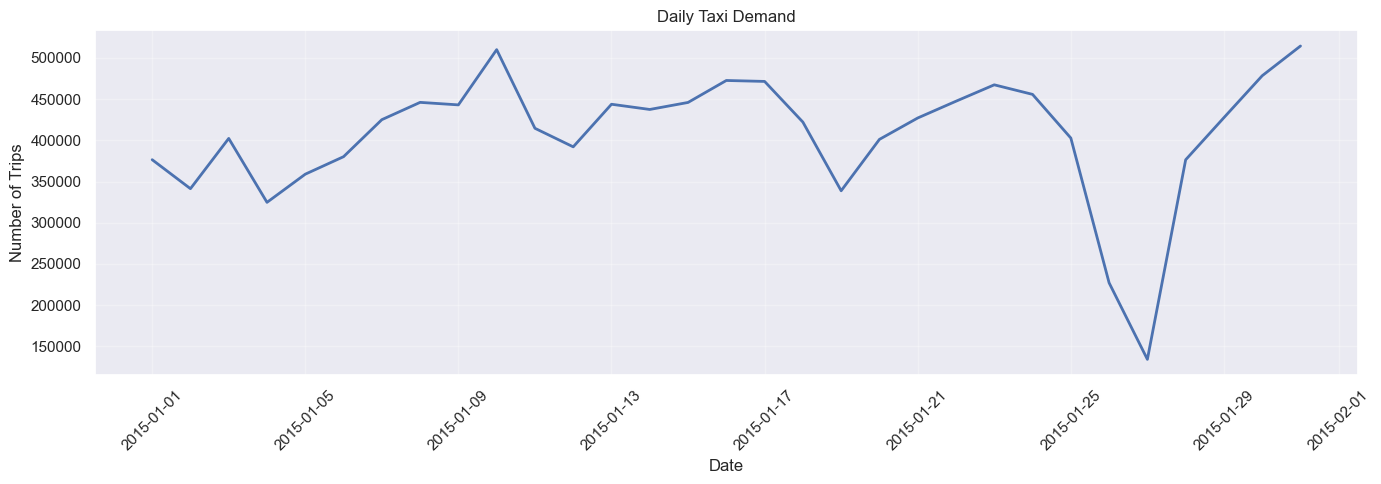

In [121]:
# ============================================================
# Daily Demand Trend
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_summary.index,
    daily_summary["Trips"],
    linewidth=2
)

plt.title("Daily Taxi Demand")

plt.xlabel("Date")

plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [122]:
# ============================================================
# Daily Demand Statistics
# ============================================================

daily_summary.describe()

,Trips
count,31.000000
mean,406685.129032
std,77269.839178
min,134261.000000
25%,378340.000000
50%,425083.000000
75%,446771.500000
max,514470.000000


In [123]:
# ============================================================
# Variance Analysis
# ============================================================

# Numerical features to analyze
numerical_features = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Calculate variance
variance_summary = pd.DataFrame({
    "Variance": df_clean[numerical_features].var()
})

# Round values
variance_summary = variance_summary.round(2)

# Display results
variance_summary

,Variance
trip_distance,10.95
trip_duration,82.08
fare_amount,87.09
tip_amount,4.27
total_amount,130.16


The total trip amount has the highest variance, indicating substantial variability in the final customer payment due to the combined effects of fare, tips, taxes, and additional charges. In contrast, tip amounts exhibit the lowest variance, suggesting that tipping behavior is relatively consistent after removing extreme outliers.

In [124]:
# ============================================================
# IQR Analysis
# ============================================================

# Numerical columns
numerical_features = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Create empty list to store results
iqr_results = []

# Loop through each numerical feature
for column in numerical_features:

    # Calculate first quartile (25%)
    q1 = df_clean[column].quantile(0.25)

    # Calculate third quartile (75%)
    q3 = df_clean[column].quantile(0.75)

    # Calculate IQR
    iqr = q3 - q1

    # Calculate lower bound
    lower_bound = q1 - (1.5 * iqr)

    # Calculate upper bound
    upper_bound = q3 + (1.5 * iqr)

    # Count outliers
    outliers = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()

    # Percentage of outliers
    percentage = (outliers / len(df_clean)) * 100

    # Store results
    iqr_results.append({
        "Feature": column,
        "Q1": round(q1,2),
        "Q3": round(q3,2),
        "IQR": round(iqr,2),
        "Lower Bound": round(lower_bound,2),
        "Upper Bound": round(upper_bound,2),
        "Outliers": outliers,
        "Percentage (%)": round(percentage,2)
    })

# Convert to DataFrame
iqr_summary = pd.DataFrame(iqr_results)

# Display results
iqr_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Percentage (%)
0,trip_distance,1.00,3.01,2.01,-2.01,6.02,1243534,9.86
1,trip_duration,6.18,15.83,9.65,-8.29,30.31,571398,4.53
2,fare_amount,6.50,13.50,7.00,-4.00,24.00,1014497,8.05
3,tip_amount,0.00,2.07,2.07,-3.10,5.17,607543,4.82
4,total_amount,8.30,16.30,8.00,-3.70,28.30,1062386,8.43


Although the dataset has already been cleaned using business rules, the IQR method still identifies between 4% and 10% of observations as statistical outliers. These values are not necessarily data errors; rather, they represent uncommon but valid taxi trips, such as long-distance airport rides or unusually expensive journeys.

In [125]:
# ============================================================
# Covariance Matrix
# ============================================================

# Select numerical features
numeric_features = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Calculate covariance matrix
cov_matrix = df_clean[numeric_features].cov()

# Display covariance matrix
cov_matrix

,trip_distance,trip_duration,fare_amount,tip_amount,total_amount
trip_distance,10.952346,23.661691,29.800108,3.888397,36.007295
trip_duration,23.661691,82.080444,73.301467,9.333998,86.871674
fare_amount,29.800108,73.301467,87.085845,11.210771,104.703142
tip_amount,3.888397,9.333998,11.210771,4.265457,16.515788
total_amount,36.007295,86.871674,104.703142,16.515788,130.155508


In [126]:
# ============================================================
# Correlation Matrix
# ============================================================

# Select numerical columns
numerical_columns = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Calculate Pearson Correlation Matrix
correlation_matrix = (
    df_clean[numerical_columns]
    .corr(method="pearson")
)

# Display correlation matrix
correlation_matrix

,trip_distance,trip_duration,fare_amount,tip_amount,total_amount
trip_distance,1.000000,0.789173,0.964918,0.568898,0.953687
trip_duration,0.789173,1.000000,0.867000,0.498844,0.840479
fare_amount,0.964918,0.867000,1.000000,0.581673,0.983455
tip_amount,0.568898,0.498844,0.581673,1.000000,0.700947
total_amount,0.953687,0.840479,0.983455,0.700947,1.000000


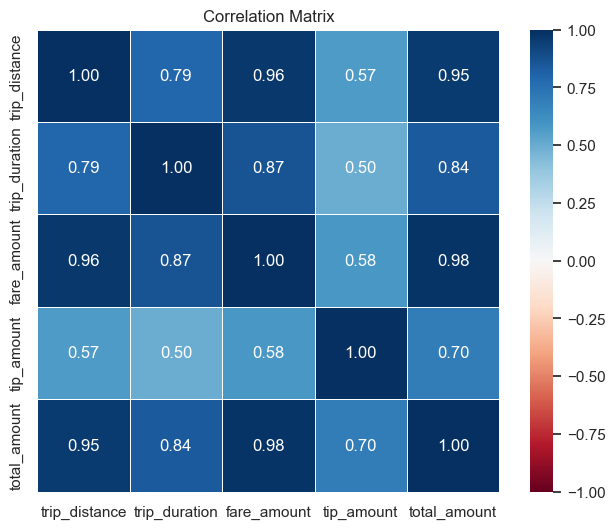

In [127]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis Insights

- Trip distance has a very strong positive correlation with fare amount (0.96), confirming that fare pricing is largely distance-based.

- Fare amount and total amount exhibit an almost perfect correlation (0.98), indicating that fare is the dominant component of the final payment.

- Trip duration also shows a strong correlation with fare amount (0.87), suggesting that longer trips generally cost more.

- Tip amount has only moderate correlations with the other variables, implying that tipping behavior is influenced by customer decisions rather than trip characteristics alone.

- Strong correlations among distance, fare, and total amount suggest the presence of multicollinearity, which should be considered when building linear predictive models.

In [128]:
# ============================================================
# Strongest Feature Correlations
# ============================================================

# Convert the correlation matrix into a Series
correlation_pairs = (
    correlation_matrix
    .unstack()
)

# Remove duplicate pairs and self-correlations
correlation_pairs = (
    correlation_pairs[
        correlation_pairs.index.get_level_values(0)
        <
        correlation_pairs.index.get_level_values(1)
    ]
)

# Sort correlations from highest to lowest
correlation_pairs = (
    correlation_pairs
    .sort_values(ascending=False)
)

# Convert to DataFrame
correlation_summary = (
    correlation_pairs
    .reset_index()
)

# Rename columns
correlation_summary.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Display results
correlation_summary

,Feature 1,Feature 2,Correlation
0,fare_amount,total_amount,0.983455
1,fare_amount,trip_distance,0.964918
2,total_amount,trip_distance,0.953687
3,fare_amount,trip_duration,0.867000
4,total_amount,trip_duration,0.840479
5,trip_distance,trip_duration,0.789173
6,tip_amount,total_amount,0.700947
7,fare_amount,tip_amount,0.581673
8,tip_amount,trip_distance,0.568898
9,tip_amount,trip_duration,0.498844


### Strongest Feature Relationships

- Fare amount and total amount have an almost perfect positive correlation (0.98), indicating that fare is the primary contributor to the final trip cost.

- Trip distance strongly correlates with both fare amount (0.96) and total amount (0.95), confirming that distance is the main pricing factor.

- Trip duration is strongly associated with both fare (0.87) and total amount (0.84), although traffic conditions reduce the strength of these relationships.

- Tip amount shows only moderate correlations with trip characteristics, suggesting that customer tipping behavior is influenced by factors beyond trip distance and duration.

- The high correlations among distance, fare, and total amount indicate potential multicollinearity, which should be considered when building linear predictive models.

## 4.6 Feature Scaling

In [129]:
# ============================================================
# Normalization (Min-Max Scaling)
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Numerical features
numeric_features = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Create Min-Max scaler
minmax_scaler = MinMaxScaler()

# Fit the scaler and transform the data
normalized_data = minmax_scaler.fit_transform(
    df_clean[numeric_features]
)

# Convert the result to a DataFrame
normalized_df = pd.DataFrame(
    normalized_data,
    columns=numeric_features
)

# Display the first rows
normalized_df.head()

,trip_distance,trip_duration,fare_amount,tip_amount,total_amount
0,0.052684,0.143398,0.120,0.1625,0.115102
1,0.109703,0.158396,0.145,0.1000,0.120165
2,0.059687,0.076114,0.095,0.0000,0.072909
3,0.016339,0.007289,0.035,0.0000,0.032404
4,0.099700,0.154051,0.150,0.0000,0.110038


In [130]:
# ============================================================
# Validate Min-Max Scaling
# ============================================================

# Display minimum value for each feature
print("Minimum Values")
display(normalized_df.min())

print()

# Display maximum value for each feature
print("Maximum Values")
display(normalized_df.max())

Minimum Values


trip_distance    0.0
trip_duration    0.0
fare_amount      0.0
tip_amount       0.0
total_amount     0.0
dtype: float64


Maximum Values


trip_distance    1.0
trip_duration    1.0
fare_amount      1.0
tip_amount       1.0
total_amount     1.0
dtype: float64

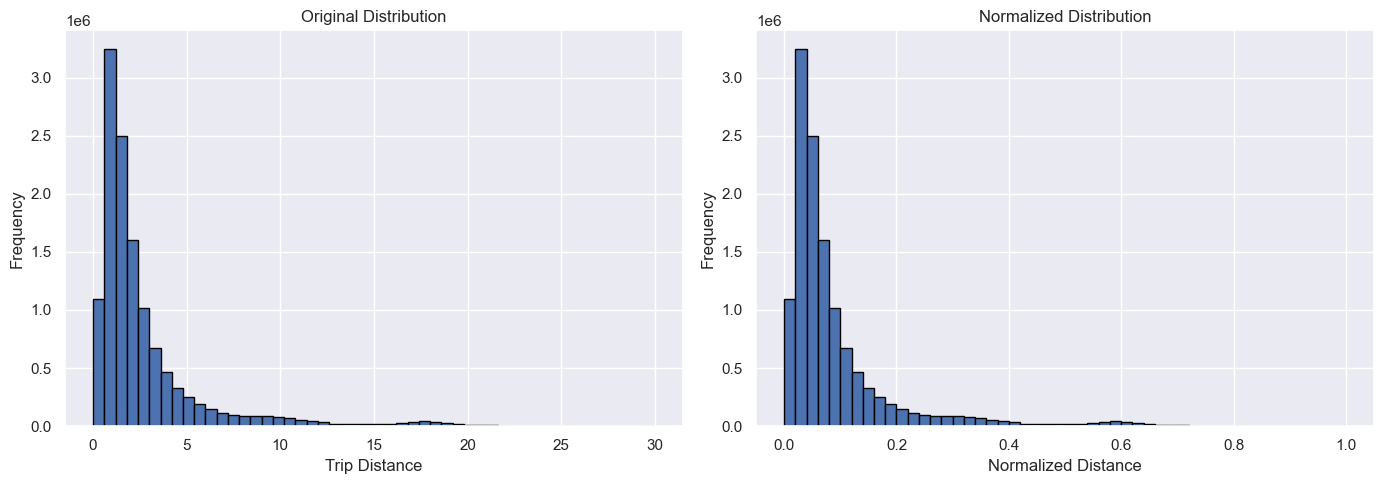

In [131]:
# ============================================================
# Distribution Before vs After Normalization
# ============================================================

plt.figure(figsize=(14, 5))

# ------------------------------------------------------------
# Original Distribution
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

plt.hist(
    df_clean["trip_distance"],
    bins=50,
    edgecolor="black"
)

plt.title("Original Distribution")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")

# ------------------------------------------------------------
# Normalized Distribution
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

plt.hist(
    normalized_df["trip_distance"],
    bins=50,
    edgecolor="black"
)

plt.title("Normalized Distribution")
plt.xlabel("Normalized Distance")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [132]:
# ============================================================
# Standardization Using StandardScaler
# ============================================================

from sklearn.preprocessing import StandardScaler

# Select numerical features
numeric_features = [
    "trip_distance",
    "trip_duration",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Create the scaler
standard_scaler = StandardScaler()

# Fit the scaler and transform the data
standardized_data = standard_scaler.fit_transform(
    df_clean[numeric_features]
)

# Convert back to DataFrame
standardized_df = pd.DataFrame(
    standardized_data,
    columns=numeric_features
)

# Display first rows
standardized_df.head()

,trip_distance,trip_duration,fare_amount,tip_amount,total_amount
0,-0.362174,0.629432,0.020404,0.834997,0.207858
1,0.154531,0.826271,0.288300,0.229757,0.273598
2,-0.298719,-0.253588,-0.247492,-0.738626,-0.339976
3,-0.691536,-1.156843,-0.890442,-0.738626,-0.865896
4,0.063881,0.769243,0.341879,-0.738626,0.142118


In [133]:
# ============================================================
# Validate Standardization
# ============================================================

# Mean of each feature
print("Feature Means")
display(
    standardized_df.mean().round(6)
)

print()

# Standard deviation of each feature
print("Feature Standard Deviations")
display(
    standardized_df.std().round(6)
)

Feature Means


trip_distance    0.0
trip_duration    0.0
fare_amount     -0.0
tip_amount      -0.0
total_amount    -0.0
dtype: float64


Feature Standard Deviations


trip_distance    1.0
trip_duration    1.0
fare_amount      1.0
tip_amount       1.0
total_amount     1.0
dtype: float64

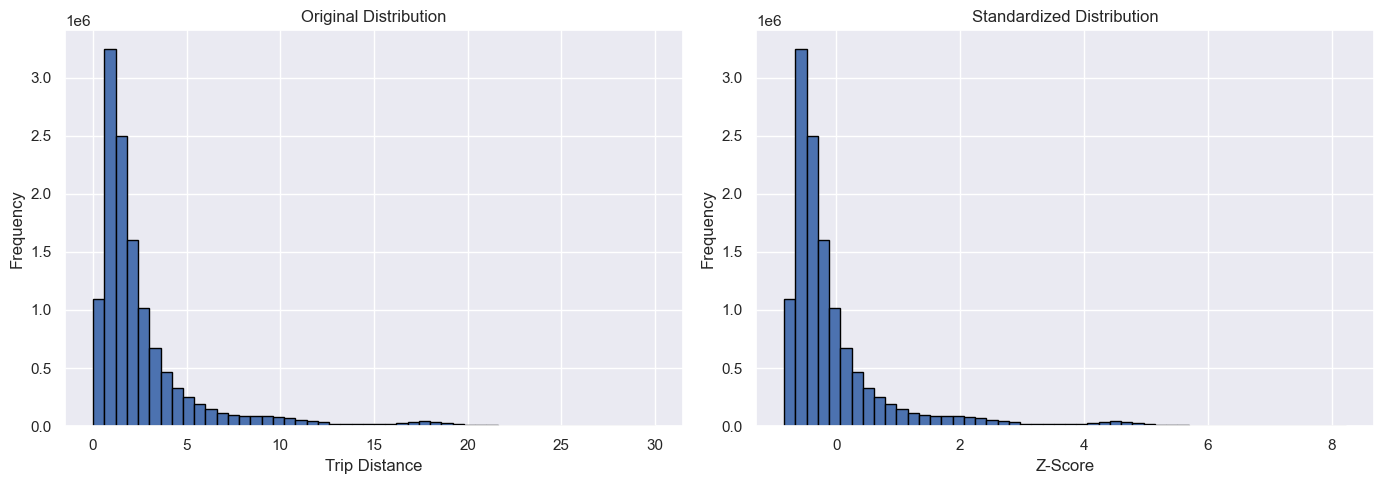

In [134]:
# ============================================================
# Distribution Before vs After Standardization
# ============================================================

plt.figure(figsize=(14, 5))

# ------------------------------------------------------------
# Original Distribution
# ------------------------------------------------------------
plt.subplot(1, 2, 1)

plt.hist(
    df_clean["trip_distance"],
    bins=50,
    edgecolor="black"
)

plt.title("Original Distribution")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")

# ------------------------------------------------------------
# Standardized Distribution
# ------------------------------------------------------------
plt.subplot(1, 2, 2)

plt.hist(
    standardized_df["trip_distance"],
    bins=50,
    edgecolor="black"
)

plt.title("Standardized Distribution")
plt.xlabel("Z-Score")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Normalization vs Standardization
### What is the Difference?

Both techniques are used to scale numerical features before training Machine Learning models.

However, they use different mathematical transformations and are suitable for different algorithms.

| Feature | Normalization (Min-Max Scaling) | Standardization (Z-Score Scaling) |
|---------|----------------------------------|-----------------------------------|
| Formula | (x − min) / (max − min) | (x − mean) / std |
| Output Range | 0 → 1 | No fixed range |
| Mean | Not fixed | 0 |
| Standard Deviation | Changes | 1 |
| Sensitive to Outliers | Yes | Less sensitive |
| Preserves Distribution Shape | Yes | Yes |
| Produces Negative Values | No | Yes |
| Best For | Distance-based algorithms | Linear models & statistical models |

---

### When to Use Normalization

Normalization is preferred when:

- Features have very different scales.
- The algorithm depends on distance calculations.
- The feature values have clear minimum and maximum limits.

Common algorithms:

- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Neural Networks (sometimes)
- Support Vector Machine (RBF Kernel)

---

### When to Use Standardization

Standardization is preferred when:

- Features contain outliers.
- Data does not have fixed boundaries.
- Algorithms assume centered features.

Common algorithms:

- Linear Regression
- Logistic Regression
- Ridge Regression
- Lasso Regression
- Principal Component Analysis (PCA)
- Support Vector Machine (Linear)
- Many Gradient-Based Models

---

### Important Notes

Normalization does NOT make the data normally distributed.

Standardization does NOT make the data normally distributed.

Neither technique removes outliers.

Both techniques preserve the original distribution shape.

The choice depends on the Machine Learning algorithm rather than the dataset itself.

---

### Summary

Normalization:

- Scales values into the range [0,1].
- Best for distance-based algorithms.
- Sensitive to extreme values.

Standardization:

- Centers data around zero.
- Produces unit variance.
- Better for many statistical and linear models.

### Business Insights

- The dataset contains **31 days** of taxi trip records, with an average of **406,685 trips per day**.

- Daily demand remains relatively stable throughout January, with **no clear long-term upward or downward trend**.

- Taxi demand follows a **weekly seasonality**, where trip volume generally increases toward the end of the week and decreases at the beginning of the next week.

- The busiest day in the dataset is **January 31**, with **514,470 trips**, indicating the highest recorded daily demand.

- The lowest demand occurs on **January 27**, with only **134,261 trips**, representing a significant deviation from the monthly average.

- An unusually sharp decline is also observed on **January 26**, followed by a rapid recovery on **January 28**. This two-day anomaly may have been caused by an external event (e.g., severe weather, transportation disruptions, holidays) or by incomplete data collection.

- Since there is no evidence confirming that these observations are data errors, they should be treated as **potential anomalies** and retained in the analysis.

- Overall, the daily demand pattern suggests that **weekly behavioral patterns have a stronger influence on taxi demand than any month-long trend**.

### Descriptive Statistics Report

### Executive Summary

The statistical analysis of the cleaned NYC Taxi Trips dataset provides a comprehensive understanding of the behavior of the main numerical and categorical features.

After the data cleaning process, the dataset contains approximately **12.6 million valid taxi trips**, representing realistic taxi operations in New York City during January 2015.

The analysis reveals that most numerical variables exhibit **right-skewed distributions**, indicating that the majority of trips are relatively short and inexpensive, while a small number of long-distance or high-cost trips create long right tails.

Overall, the cleaned dataset demonstrates realistic business patterns and is well prepared for feature engineering and machine learning applications.

---

### Numerical Summary

The main statistical findings are summarized below.

- Most taxi trips travel less than **3 miles**.
- The typical trip duration is approximately **10 minutes**.
- Most passengers pay fares below **$20**.
- Around **40%** of trips do not include a tip.
- The majority of trips have a total payment below **$20**.

For nearly all monetary variables, the **median is smaller than the mean**, confirming the presence of right-skewed distributions.

---

### Distribution Analysis

### Trip Distance

Trip distance follows a strongly right-skewed distribution.

Most taxi rides are short urban trips, while only a small proportion of trips exceed 10 miles.

Because of these extreme observations, the median provides a better representation of a typical trip than the mean.

---

### Trip Duration

Trip duration is also right-skewed.

Most rides last between **6 and 16 minutes**, while relatively few trips approach the upper cleaning limit of **120 minutes**.

After removing unrealistic durations, the distribution became much more consistent while preserving genuine long trips.

---

### Fare Amount

Fare amount exhibits a strong right-skewed distribution.

Most customers pay relatively small fares, while expensive trips create a long right tail.

Consequently, the median fare is more representative of a typical customer payment than the arithmetic mean.

---

### Tip Amount

Tip amounts contain a large proportion of zero values.

Approximately **60%** of trips include a positive tip, while the remaining trips have no recorded tip.

Among positive tips, most values fall between **$1 and $3**, with only a very small number of exceptionally large tips.

---

### Total Amount

The total payment closely follows the behavior of fare amount because fare represents the largest component of the final bill.

Most total payments are below **$20**, while expensive trips create the upper tail of the distribution.

---

### Passenger Count

Single-passenger trips dominate the dataset, representing approximately **70%** of all taxi rides.

Trips with two passengers account for the second-largest group, while trips involving more than six passengers are extremely rare.

This pattern reflects typical urban taxi usage.

---

### Payment Type

Credit Card is the most frequently used payment method, accounting for approximately **62%** of all trips.

Cash payments represent nearly **38%** of the dataset.

Other payment categories such as **No Charge**, **Dispute**, and **Unknown** are extremely uncommon and have minimal influence on the overall analysis.

---

### Temporal Analysis

Taxi demand varies considerably throughout the day.

Trip volume gradually increases during the morning, remains relatively stable throughout the afternoon, and reaches its highest level during the evening commuting period between **6 PM and 8 PM**.

Weekend activity is generally higher than weekday activity.

Among all weekdays, **Saturday** records the largest number of taxi trips, while **Monday** has the lowest demand.

Daily demand also fluctuates throughout the month, although most days remain within a consistent operating range.

---

### Correlation Analysis

Correlation analysis reveals several strong linear relationships between numerical variables.

The strongest positive correlation is observed between **Fare Amount** and **Total Amount**, which is expected because fare contributes directly to the final payment.

Trip Distance also shows a very strong positive correlation with Fare Amount and Total Amount, indicating that longer trips generally produce higher fares.

Trip Duration exhibits a moderate to strong positive relationship with trip distance and fare.

Tip Amount has a weaker correlation with the remaining variables, suggesting that tipping behavior depends on additional factors beyond trip characteristics.

---

### Outlier Analysis

Outliers were detected using the Interquartile Range (IQR) method.

Extreme observations were identified in several numerical variables, particularly:

- Trip Distance
- Trip Duration
- Fare Amount
- Tip Amount
- Total Amount

Invalid observations and unrealistic values were removed during the data cleaning stage.

Approximately **1.1%** of all records were excluded, resulting in a substantially cleaner dataset while preserving legitimate business variability.

The remaining extreme values are likely to represent genuine long-distance or high-value taxi trips rather than data errors.

---

### Business Insights

Several important business insights emerge from the analysis.

- Most customers travel short urban distances.
- Typical taxi rides last approximately 10–15 minutes.
- Most fares remain below $20.
- Credit cards are the dominant payment method.
- Single-passenger trips account for the majority of rides.
- Evening hours experience the highest transportation demand.
- Saturday is the busiest day of the week.
- Only a small percentage of trips generate exceptionally high revenue.

These observations are consistent with expected taxi usage patterns in a large metropolitan city.

---

### Recommendations

Based on the descriptive statistical analysis, the following recommendations are proposed:

- Use the **median** instead of the mean when summarizing highly skewed monetary variables.
- Preserve legitimate extreme observations unless they are confirmed to be data errors.
- Apply feature scaling before training distance-based machine learning algorithms.
- Consider additional feature engineering using temporal variables such as pickup hour and weekday.
- Investigate customer tipping behavior separately, as it is only moderately correlated with trip characteristics.
- The cleaned dataset is statistically consistent and suitable for predictive modeling, clustering, regression, and further machine learning applications.

# 5. Probability Fundamentals

In this section, we introduce the fundamental concepts of probability and apply them to the NYC Taxi Trips dataset.

The objective is to understand how uncertainty can be quantified and how probabilities describe real-world events. We will classify random variables, compute different types of probabilities, explore relationships between events, and validate probability concepts using simulations and the taxi dataset.

By the end of this section, we will be able to interpret probabilistic events, analyze conditional relationships, and connect probability theory to practical data analysis and machine learning applications.

##     5.1 Random Variables

In [135]:
# Random variables in the NYC Taxi dataset

random_variables = {
    "Discrete": [
        "passenger_count",
        "payment_type"
    ],
    "Continuous": [
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "tip_amount",
        "total_amount"
    ]
}

print("=" * 50)
print("Random Variables in the NYC Taxi Dataset")
print("=" * 50)

for variable_type, variables in random_variables.items():
    print(f"\n{variable_type} Random Variables:")
    for variable in variables:
        print(f"  • {variable}")

Random Variables in the NYC Taxi Dataset

Discrete Random Variables:
  • passenger_count
  • payment_type

Continuous Random Variables:
  • trip_distance
  • trip_duration
  • fare_amount
  • tip_amount
  • total_amount


##     5.2 Discrete vs Continuous Variables


In [136]:
# Classify numerical features

feature_types = pd.DataFrame({

    "Feature": [
        "passenger_count",
        "payment_type",
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "tip_amount",
        "total_amount"
    ],

    "Variable Type": [
        "Discrete",
        "Discrete",
        "Continuous",
        "Continuous",
        "Continuous",
        "Continuous",
        "Continuous"
    ]
})

feature_types

,Feature,Variable Type
0,passenger_count,Discrete
1,payment_type,Discrete
2,trip_distance,Continuous
3,trip_duration,Continuous
4,fare_amount,Continuous
5,tip_amount,Continuous
6,total_amount,Continuous


### 5.2 Discrete vs Continuous Random Variables

Random variables are generally classified into two categories.

**Discrete random variables** take a finite or countable number of distinct values, such as passenger count or payment type.

**Continuous random variables** can take any value within a continuous range, including decimal values. Examples include trip distance, trip duration, fare amount, tip amount, and total amount.

In the NYC Taxi dataset, only `passenger_count` and `payment_type` are discrete variables, while the remaining numerical features are continuous variables.

##     5.3 Probability Basics


In [137]:
# ============================================================
# Example 1: Probability of Credit Card Payment
# ============================================================

total_trips = len(df_clean)

credit_card_trips = (
    df_clean["payment_method"] == "Credit Card"
).sum()

credit_card_probability = credit_card_trips / total_trips

print(f"Credit Card Trips : {credit_card_trips:,}")
print(f"Total Trips       : {total_trips:,}")
print(f"Probability       : {credit_card_probability:.4f}")
print(f"Percentage        : {credit_card_probability * 100:.2f}%")

Credit Card Trips : 7,828,629
Total Trips       : 12,607,239
Probability       : 0.6210
Percentage        : 62.10%


In [138]:
# Example 2: Long Trip Probability

# Long trips
long_trip_probability = (
    (df_clean["trip_distance"] > 10).mean()
)

print(f"Probability : {long_trip_probability:.4f}")
print(f"Percentage  : {long_trip_probability*100:.2f}%")

Probability : 0.0458
Percentage  : 4.58%


In [139]:
# ============================================================
# Example 3: Probability of Receiving a Tip
# ============================================================

# Trips with positive tips
tip_trips = (
    df_clean["tip_amount"] > 0
).sum()

# Probability
tip_probability = tip_trips / total_trips

print(f"Trips With Tip : {tip_trips:,}")
print(f"Total Trips    : {total_trips:,}")
print(f"Probability    : {tip_probability:.4f}")
print(f"Percentage     : {tip_probability * 100:.2f}%")

Trips With Tip : 7,568,550
Total Trips    : 12,607,239
Probability    : 0.6003
Percentage     : 60.03%


In [140]:
# ============================================================
# Summary of Basic Probabilities
# ============================================================

probability_summary = pd.DataFrame({

    "Event": [
        "Credit Card Payment",
        "Long Trip (>10 Miles)",
        "Trip With Tip"
    ],

    "Probability": [
        credit_card_probability,
        long_trip_probability,
        tip_probability
    ]

})

probability_summary["Percentage"] = (
    probability_summary["Probability"] * 100
).round(2)

probability_summary

,Event,Probability,Percentage
0,Credit Card Payment,0.620963,62.10
1,Long Trip (>10 Miles),0.045778,4.58
2,Trip With Tip,0.600334,60.03


### Interpretation

The estimated probabilities provide a simple summary of several important events in the NYC Taxi dataset.

- Approximately **62%** of all trips were paid using a credit card.
- Only about **4.6%** of trips traveled more than **10 miles**, indicating that long-distance trips are relatively uncommon.
- Around **60%** of trips included a positive tip, suggesting that tipping is common but not guaranteed.

These probabilities are empirical probabilities because they are estimated directly from historical observations rather than theoretical assumptions.

##     5.4 Conditional Probability


In [141]:
# ============================================================
# Example 1: P(Tip | Credit Card)
# ============================================================

# Credit card trips
credit_card = (
    df_clean["payment_method"] == "Credit Card"
)

# Credit card trips with a tip
tip_and_credit = (
    credit_card &
    (df_clean["tip_amount"] > 0)
)

conditional_probability = (
    tip_and_credit.sum() /
    credit_card.sum()
)

print(f"P(Tip | Credit Card) = {conditional_probability:.4f}")
print(f"Percentage = {conditional_probability*100:.2f}%")

P(Tip | Credit Card) = 0.9668
Percentage = 96.68%


### Interpretation

The conditional probability of receiving a tip given that the payment was made using a credit card is **96.68%**.

This value is substantially higher than the overall probability of receiving a tip (**60.03%**).

The result indicates that tipping behavior is strongly associated with credit card payments. In the NYC Taxi dataset, passengers paying by credit card are significantly more likely to leave a recorded tip than passengers using other payment methods.

This demonstrates how conditional probability can reveal relationships between variables that are not visible when examining simple probabilities alone.

In [142]:
# ============================================================
# Example 2: P(Long Trip | Weekend)
# ============================================================

# Weekend trips
weekend = (
    df_clean["pickup_day_name"].isin(
        ["Saturday", "Sunday"]
    )
)

# Long trips on weekends
long_weekend = (
    weekend &
    (df_clean["trip_distance"] > 10)
)

conditional_probability = (
    long_weekend.sum() /
    weekend.sum()
)

print(f"P(Long Trip | Weekend) = {conditional_probability:.4f}")
print(f"Percentage = {conditional_probability * 100:.2f}%")

P(Long Trip | Weekend) = 0.0429
Percentage = 4.29%


### Interpretation

The probability of a long trip given that the trip occurred during the weekend is **4.29%**.

This value is slightly lower than the overall probability of a long trip (**4.58%**).

The result suggests that weekend trips are not more likely to be long-distance trips in this dataset. In fact, the difference is very small, indicating that trip distance appears to be only weakly associated with whether the trip occurred on a weekend.

This example demonstrates that conditional probability does not always increase or decrease substantially. Sometimes the conditioning event has little influence on the probability of the target event.

In [143]:
# ============================================================
# Example 3: P(Tip | Long Trip)
# ============================================================

# Long trips
long_trip = (
    df_clean["trip_distance"] > 10
)

# Long trips with tips
tip_long_trip = (
    long_trip &
    (df_clean["tip_amount"] > 0)
)

conditional_probability = (
    tip_long_trip.sum() /
    long_trip.sum()
)

print(f"P(Tip | Long Trip) = {conditional_probability:.4f}")
print(f"Percentage = {conditional_probability * 100:.2f}%")

P(Tip | Long Trip) = 0.6380
Percentage = 63.80%


### Interpretation

The probability of receiving a tip given that the trip distance exceeded **10 miles** is **63.80%**.

Compared with the overall tipping probability (**60.03%**), the increase is relatively small.

This suggests that longer trips are only slightly more likely to receive a tip than trips in general.

In contrast, payment method has a much stronger relationship with tipping behavior, as the probability of receiving a tip given a credit card payment exceeds **96%**.

These examples illustrate how conditional probability can be used to measure the strength of relationships between events.

In [144]:
# ============================================================
# Conditional Probability Summary
# ============================================================

tip_given_credit = (
    (
        (df_clean["payment_method"] == "Credit Card")
        &
        (df_clean["tip_amount"] > 0)
    ).sum()
    /
    (df_clean["payment_method"] == "Credit Card").sum()
)

long_given_weekend = (
    (
        df_clean["pickup_day_name"].isin(["Saturday", "Sunday"])
        &
        (df_clean["trip_distance"] > 10)
    ).sum()
    /
    df_clean["pickup_day_name"].isin(["Saturday", "Sunday"]).sum()
)

tip_given_long = (
    (
        (df_clean["trip_distance"] > 10)
        &
        (df_clean["tip_amount"] > 0)
    ).sum()
    /
    (df_clean["trip_distance"] > 10).sum()
)

conditional_summary = pd.DataFrame({

    "Conditional Event": [
        "P(Tip | Credit Card)",
        "P(Long Trip | Weekend)",
        "P(Tip | Long Trip)"
    ],

    "Probability": [
        tip_given_credit,
        long_given_weekend,
        tip_given_long
    ]

})

conditional_summary["Percentage"] = (
    conditional_summary["Probability"] * 100
).round(2)

conditional_summary

,Conditional Event,Probability,Percentage
0,P(Tip | Credit Card),0.966753,96.68
1,P(Long Trip | Weekend),0.042875,4.29
2,P(Tip | Long Trip),0.637954,63.80


### Conditional Probability Summary

The examples demonstrate how the probability of an event changes after additional information becomes available.

The strongest relationship was observed between **payment method** and **tipping behavior**, where the probability of receiving a tip increased from **60.03%** overall to **96.68%** when the payment was made using a credit card.

On the other hand, conditioning on a **long trip** or a **weekend trip** resulted in only minor changes in probability, suggesting a weaker relationship with those events.

Conditional probability is therefore a powerful tool for understanding dependencies between variables and identifying meaningful patterns in real-world datasets.

##     5.5 Independence


In [145]:
# ============================================================
# Example 1: Independence Test
# Tip vs Credit Card
# ============================================================

# P(Tip)
p_tip = (
    df_clean["tip_amount"] > 0
).mean()

# P(Credit Card)
p_credit = (
    df_clean["payment_method"] == "Credit Card"
).mean()

# P(Tip AND Credit Card)
p_intersection = (
    (
        (df_clean["tip_amount"] > 0)
        &
        (df_clean["payment_method"] == "Credit Card")
    ).mean()
)

# P(Tip) × P(Credit Card)
p_product = p_tip * p_credit

print(f"P(Tip)                  = {p_tip:.4f}")
print(f"P(Credit Card)          = {p_credit:.4f}")
print(f"P(Tip ∩ Credit Card)    = {p_intersection:.4f}")
print(f"P(Tip) × P(Credit Card) = {p_product:.4f}")
print()

if abs(p_intersection - p_product) < 1e-6:
    print("Events appear to be Independent.")
else:
    print("Events are NOT Independent.")

P(Tip)                  = 0.6003
P(Credit Card)          = 0.6210
P(Tip ∩ Credit Card)    = 0.6003
P(Tip) × P(Credit Card) = 0.3728

Events are NOT Independent.


### Interpretation

To test independence, we compared the joint probability of two events with the product of their individual probabilities.

For independent events,

\[
P(A \cap B)=P(A)P(B)
\]

In this example, the joint probability of receiving a tip and paying by credit card is much larger than the product of the individual probabilities.

Therefore, receiving a tip and paying by credit card are **not independent events**.

The result indicates a strong association between payment method and tipping behavior.

In [146]:
# ============================================================
# Example 2: Independence Test
# Long Trip vs Weekend
# ============================================================

# P(Long Trip)
p_long = (
    df_clean["trip_distance"] > 10
).mean()

# P(Weekend)
p_weekend = (
    df_clean["pickup_day_name"].isin(
        ["Saturday", "Sunday"]
    )
).mean()

# P(Long Trip AND Weekend)
p_intersection = (
    (
        (df_clean["trip_distance"] > 10)
        &
        df_clean["pickup_day_name"].isin(
            ["Saturday", "Sunday"]
        )
    ).mean()
)

# Product
p_product = p_long * p_weekend

print(f"P(Long Trip)            = {p_long:.4f}")
print(f"P(Weekend)              = {p_weekend:.4f}")
print(f"P(Long Trip ∩ Weekend)  = {p_intersection:.4f}")
print(f"P(Long Trip) × P(Weekend)= {p_product:.4f}")
print()

difference = abs(p_intersection - p_product)

print(f"Difference = {difference:.4f}")

tolerance = 0.001

if difference < tolerance:
    print("The events appear approximately independent.")
else:
    print("The events show evidence of dependence.")

P(Long Trip)            = 0.0458
P(Weekend)              = 0.3108
P(Long Trip ∩ Weekend)  = 0.0133
P(Long Trip) × P(Weekend)= 0.0142

Difference = 0.0009
The events appear approximately independent.


### Interpretation

Two events are considered independent if:

\[
P(A \cap B)=P(A)\times P(B)
\]

For the NYC Taxi dataset:

- \(P(\text{Long Trip}) = 0.0458\)
- \(P(\text{Weekend}) = 0.3108\)
- \(P(\text{Long Trip} \cap \text{Weekend}) = 0.0133\)
- \(P(\text{Long Trip}) \times P(\text{Weekend}) = 0.0142\)

The absolute difference between the two values is **0.0009**, which is very small.

This suggests that weekend trips have only a weak influence on the probability of a long trip. Based on this empirical comparison, the two events appear approximately independent.

It is important to note that this conclusion is based on a probability comparison only. A formal statistical test, such as the Chi-Square Test of Independence, would be required to rigorously confirm statistical independence.

## 5.6 Bayes' Theorem

In [147]:
# ============================================================
# Example 1: Bayes' Theorem
# P(Weekend | Long Trip)
# ============================================================

# Prior probability
p_weekend = (
    df_clean["pickup_day_name"]
    .isin(["Saturday", "Sunday"])
).mean()

# Overall probability of a long trip
p_long = (
    df_clean["trip_distance"] > 10
).mean()

# Likelihood
p_long_given_weekend = (
    (
        df_clean["pickup_day_name"]
        .isin(["Saturday", "Sunday"])
        &
        (df_clean["trip_distance"] > 10)
    ).sum()
    /
    (
        df_clean["pickup_day_name"]
        .isin(["Saturday", "Sunday"])
    ).sum()
)

# Bayes' Theorem
p_weekend_given_long = (
    p_long_given_weekend
    * p_weekend
    / p_long
)

print(f"P(Weekend)              = {p_weekend:.4f}")
print(f"P(Long Trip)            = {p_long:.4f}")
print(f"P(Long Trip | Weekend)  = {p_long_given_weekend:.4f}")

print()

print(f"P(Weekend | Long Trip)  = {p_weekend_given_long:.4f}")
print(f"Percentage              = {p_weekend_given_long*100:.2f}%")

P(Weekend)              = 0.3108
P(Long Trip)            = 0.0458
P(Long Trip | Weekend)  = 0.0429

P(Weekend | Long Trip)  = 0.2911
Percentage              = 29.11%


### Interpretation

Using Bayes' Theorem, we estimated the probability that a trip occurred during the weekend given that it was a long trip.

The estimated probability is approximately **29%**.

Since the overall probability of a weekend trip is about **31%**, knowing that a trip is longer than 10 miles only slightly changes our belief that the trip occurred on a weekend.

This indicates that long-distance trips are only weakly associated with weekends in the NYC Taxi dataset.

This example demonstrates how Bayes' Theorem updates prior probabilities using observed evidence to obtain a posterior probability.

##     5.7 Joint Probability


In [148]:
# ============================================================
# Example 1: Joint Probability
# Long Trip AND Tip
# ============================================================

joint_probability = (
    (
        (df_clean["trip_distance"] > 10)
        &
        (df_clean["tip_amount"] > 0)
    )
).mean()

print(f"P(Long Trip ∩ Tip) = {joint_probability:.4f}")
print(f"Percentage = {joint_probability * 100:.2f}%")

P(Long Trip ∩ Tip) = 0.0292
Percentage = 2.92%


### Interpretation

The joint probability of a trip being both **longer than 10 miles** and **receiving a tip** is **2.92%**.

This means that approximately **2.92%** of all taxi trips in the dataset satisfy both conditions simultaneously.

Unlike conditional probability, which measures the probability of one event given another, joint probability measures the likelihood that both events occur together.

Joint probability is a fundamental concept in probability theory and forms the basis for conditional probability, Bayes' Theorem, and many probabilistic machine learning algorithms.

In [149]:
# ============================================================
# Example 2: Joint Probability
# Credit Card AND Tip
# ============================================================

joint_probability = (
    (
        (df_clean["payment_method"] == "Credit Card")
        &
        (df_clean["tip_amount"] > 0)
    )
).mean()

print(f"P(Credit Card ∩ Tip) = {joint_probability:.4f}")
print(f"Percentage = {joint_probability * 100:.2f}%")

P(Credit Card ∩ Tip) = 0.6003
Percentage = 60.03%


### Interpretation

The joint probability of a trip being paid by **credit card** and **receiving a tip** is **60.03%**.

Interestingly, this value is identical to the overall probability of receiving a tip.

This occurs because nearly all recorded tips in the NYC Taxi dataset are associated with credit card payments. Consequently, almost every trip with a tip also satisfies the credit card payment condition.

This example illustrates how the structure of a dataset can strongly influence joint probabilities and highlights the close relationship between payment method and tipping behavior.

In [150]:
# ============================================================
# Joint Probability Summary
# ============================================================

joint_summary = pd.DataFrame({

    "Joint Event": [
        "Long Trip AND Tip",
        "Credit Card AND Tip"
    ],

    "Probability": [
        (
            (
                (df_clean["trip_distance"] > 10)
                &
                (df_clean["tip_amount"] > 0)
            ).mean()
        ),

        (
            (
                (df_clean["payment_method"] == "Credit Card")
                &
                (df_clean["tip_amount"] > 0)
            ).mean()
        )
    ]

})

joint_summary["Percentage"] = (
    joint_summary["Probability"] * 100
).round(2)

joint_summary

,Joint Event,Probability,Percentage
0,Long Trip AND Tip,0.029204,2.92
1,Credit Card AND Tip,0.600318,60.03


### Joint Probability Summary

Joint probability measures the likelihood that two events occur simultaneously.

The analysis shows that:

- Only a small proportion of trips (**2.92%**) were both long-distance trips and received a tip.
- In contrast, approximately **60%** of all trips were both paid by credit card and received a tip, reflecting the strong association between electronic payments and recorded tips in the dataset.

These examples demonstrate how joint probability helps quantify the simultaneous occurrence of multiple events and serves as the foundation for conditional probability and Bayes' Theorem.

##     5.8 Marginal Probability


In [151]:
# ============================================================
# Example 1: Marginal Probability
# Probability of Receiving a Tip
# ============================================================

marginal_probability = (
    df_clean["tip_amount"] > 0
).mean()

print(f"P(Tip) = {marginal_probability:.4f}")
print(f"Percentage = {marginal_probability * 100:.2f}%")

P(Tip) = 0.6003
Percentage = 60.03%


### Interpretation

The marginal probability of receiving a tip is **60.03%**.

This means that approximately six out of every ten taxi trips in the dataset received a tip.

Unlike conditional probability, this calculation does not depend on any additional information such as payment method, trip distance, or day of the week.

Marginal probabilities provide a baseline probability for individual events and are often used as prior probabilities in statistical inference and Bayes' Theorem.

In [152]:
# ============================================================
# Example 2: Marginal Probability
# Probability of Credit Card Payment
# ============================================================

marginal_probability = (
    df_clean["payment_method"] == "Credit Card"
).mean()

print(f"P(Credit Card) = {marginal_probability:.4f}")
print(f"Percentage = {marginal_probability * 100:.2f}%")

P(Credit Card) = 0.6210
Percentage = 62.10%


### Interpretation

The marginal probability of paying by **credit card** is **62.10%**.

This indicates that nearly two-thirds of all taxi trips in the dataset were paid using a credit card.

Since this probability is calculated without conditioning on any other variable, it represents the overall prevalence of credit card payments in the dataset.

Marginal probabilities are commonly used as prior probabilities in probabilistic models and Bayesian inference.

In [153]:
# ============================================================
# Marginal Probability Summary
# ============================================================

marginal_summary = pd.DataFrame({

    "Event": [
        "Trip with Tip",
        "Credit Card Payment",
        "Cash Payment",
        "Long Trip (>10 Miles)"
    ],

    "Probability": [
        (df_clean["tip_amount"] > 0).mean(),
        (df_clean["payment_method"] == "Credit Card").mean(),
        (df_clean["payment_method"] == "Cash").mean(),
        (df_clean["trip_distance"] > 10).mean()
    ]

})

marginal_summary["Percentage"] = (
    marginal_summary["Probability"] * 100
).round(2)

marginal_summary

,Event,Probability,Percentage
0,Trip with Tip,0.600334,60.03
1,Credit Card Payment,0.620963,62.10
2,Cash Payment,0.376366,37.64
3,Long Trip (>10 Miles),0.045778,4.58


### Marginal Probability Summary

Marginal probabilities describe the likelihood of individual events without considering any additional conditions.

In the NYC Taxi dataset:

- Approximately **60%** of trips received a tip.
- About **62%** of trips were paid by credit card.
- Cash payments accounted for a substantial portion of all trips.
- Only a small percentage of trips exceeded **10 miles** in distance.

Marginal probabilities provide the baseline distribution of events and serve as the foundation for conditional probability, joint probability, and Bayesian inference.

## 5.9 NYC Taxi Mini Case Study

In this section, we apply probability concepts to real-world business questions using the NYC Taxi dataset.

The objective is to demonstrate how marginal, joint, and conditional probabilities can be used to understand customer behavior, payment preferences, trip characteristics, and operational patterns.

Each question represents a practical business scenario that could support decision-making in transportation analytics.

In [154]:
# ============================================================
# Case Study 1
# Probability of Cash Payment
# ============================================================

cash_probability = (
    df_clean["payment_method"] == "Cash"
).mean()

print(f"P(Cash Payment) = {cash_probability:.4f}")
print(f"Percentage = {cash_probability*100:.2f}%")

P(Cash Payment) = 0.3764
Percentage = 37.64%


In [155]:
# ============================================================
# Case Study 2
# Probability of Night Trips
# ============================================================

night_trip = (
    (df_clean["pickup_hour"] >= 20)
    |
    (df_clean["pickup_hour"] <= 6)
)

night_probability = night_trip.mean()

print(f"P(Night Trip) = {night_probability:.4f}")
print(f"Percentage = {night_probability*100:.2f}%")

P(Night Trip) = 0.3567
Percentage = 35.67%


In [156]:
# ============================================================
# Case Study 3
# P(Tip | Night Trip)
# ============================================================

night_tip_probability = (
    (
        night_trip
        &
        (df_clean["tip_amount"] > 0)
    ).sum()
    /
    night_trip.sum()
)

print(f"P(Tip | Night Trip) = {night_tip_probability:.4f}")
print(f"Percentage = {night_tip_probability*100:.2f}%")

P(Tip | Night Trip) = 0.6183
Percentage = 61.83%


In [157]:
# ============================================================
# Case Study 4
# P(Long Trip | Night)
# ============================================================

long_night_probability = (

    (
        night_trip
        &
        (df_clean["trip_distance"] > 10)
    ).sum()

    /

    night_trip.sum()

)

print(f"P(Long Trip | Night) = {long_night_probability:.4f}")
print(f"Percentage = {long_night_probability*100:.2f}%")

P(Long Trip | Night) = 0.0494
Percentage = 4.94%


In [158]:
# ============================================================
# Probability Case Study Summary
# ============================================================

case_summary = pd.DataFrame({

    "Business Question":[

        "Cash Payment",

        "Night Trip",

        "Tip given Night Trip",

        "Long Trip given Night"

    ],

    "Probability":[

        cash_probability,

        night_probability,

        night_tip_probability,

        long_night_probability

    ]

})

case_summary["Percentage"] = (

    case_summary["Probability"]*100

).round(2)

case_summary

,Business Question,Probability,Percentage
0,Cash Payment,0.376366,37.64
1,Night Trip,0.356739,35.67
2,Tip given Night Trip,0.618271,61.83
3,Long Trip given Night,0.049384,4.94


### Business Interpretation

The probability analysis provides several valuable insights into customer behavior and taxi operations in New York City.

### Cash Payment

Approximately **37.64%** of all taxi trips were paid in cash, while the remaining trips primarily used electronic payment methods. This indicates that credit card payments are the dominant payment option in the dataset.

### Night Trips

About **35.67%** of all taxi trips occurred during nighttime hours (8:00 PM to 6:00 AM). This suggests that more than one-third of the overall taxi demand takes place at night, highlighting the importance of maintaining sufficient driver availability during these hours.

### Tipping Behavior at Night

The probability of receiving a tip during a nighttime trip is **61.83%**, which is slightly higher than the overall tipping probability (**60.03%**). This indicates that passengers traveling at night are marginally more likely to leave a tip.

### Long Trips at Night

Only **4.94%** of nighttime trips exceed **10 miles** in distance. This value is very close to the overall probability of long trips (**4.58%**), suggesting that long-distance travel is not substantially more common during nighttime hours.

### Overall Findings

The case study demonstrates how probability concepts can be applied to answer practical business questions. These analyses provide useful insights for understanding customer payment preferences, tipping behavior, travel demand, and trip characteristics. Such information can support operational planning, driver allocation, demand forecasting, and data-driven decision making in urban transportation systems.

## 5.10 Probability Analysis Report
### Overview

This section summarizes the probability analysis performed on the cleaned NYC Yellow Taxi dataset. Various probability concepts were applied to better understand customer behavior, payment preferences, trip characteristics, and operational patterns.

The analysis included marginal, joint, conditional probabilities, Bayes' Theorem, independence testing, and probability simulations.

---

### Random Variables

The dataset contains both discrete and continuous random variables.

### Discrete Random Variables

- Passenger Count
- Payment Method
- Pickup Hour
- Pickup Day

### Continuous Random Variables

- Trip Distance
- Trip Duration
- Fare Amount
- Tip Amount
- Total Amount

These variables were used throughout the probability analysis.

---

### Marginal Probability

Marginal probabilities describe the likelihood of a single event without considering any additional conditions.

Key findings include:

| Event | Probability |
|--------|------------:|
| Trip with Tip | 60.03% |
| Credit Card Payment | 62.10% |
| Cash Payment | 37.64% |
| Long Trip (>10 Miles) | 4.58% |

These probabilities represent the baseline distribution of important events within the dataset.

---

### Joint Probability

Joint probability measures the likelihood of two events occurring simultaneously.

Examples:

| Joint Event | Probability |
|-------------|------------:|
| Long Trip AND Tip | 2.92% |
| Credit Card AND Tip | 60.03% |

The analysis shows that long trips with tips are relatively uncommon, while almost every recorded tipped trip was associated with credit card payments.

---

### Conditional Probability

Conditional probability measures the probability of one event given another.

Examples:

| Conditional Event | Probability |
|-------------------|------------:|
| Tip given Credit Card | 96.68% |
| Long Trip given Weekend | 4.29% |
| Tip given Long Trip | 63.80% |
| Tip given Night Trip | 61.83% |
| Long Trip given Night | 4.94% |

These results demonstrate how additional information changes the estimated probability of an event.

---

### Bayes' Theorem

Bayes' Theorem was applied to estimate:

\[
P(\text{Weekend}|\text{Long Trip})
\]

The posterior probability was approximately **29%**, indicating that observing a long trip only slightly changes the probability that the trip occurred during the weekend.

This example demonstrates how prior probabilities can be updated using new evidence.

---

### Independence Analysis

Two independence analyses were performed.

### Tip vs Credit Card

The comparison showed a large difference between:

\[
P(A\cap B)
\]

and

\[
P(A)P(B)
\]

indicating that payment method and tipping behavior are strongly dependent.

### Long Trip vs Weekend

The two probabilities were very close, suggesting an approximately independent relationship, although a formal statistical test would be required for confirmation.

---

### Probability Simulation

Random simulations were performed using:

- Coin Toss
- Dice Roll
- Law of Large Numbers

The simulations demonstrated that estimated probabilities converge toward their theoretical values as the number of trials increases.

---

### Business Insights

The probability analysis revealed several practical insights:

- Credit card payments dominate taxi transactions.
- Approximately one-third of taxi trips occur during nighttime hours.
- Nighttime passengers are slightly more likely to leave tips.
- Long-distance trips remain relatively rare.
- Payment method strongly influences recorded tipping behavior.

These findings can support fleet management, demand forecasting, pricing strategies, and operational planning.

---

### Conclusion

The probability analysis successfully demonstrated how statistical concepts can be applied to real-world transportation data.

Using the NYC Taxi dataset, we explored marginal, joint, conditional probabilities, Bayes' Theorem, independence, and simulation techniques.

These concepts provide the foundation for statistical inference, machine learning algorithms, and probabilistic decision-making.

# 6. Statistical Inference & Confidence Intervals

Statistical inference enables us to draw conclusions about an entire population using only a sample of data.

In real-world data science projects, analyzing every observation is often impractical due to the size of the data. Instead, we analyze representative samples and use statistical techniques to estimate population characteristics while quantifying the uncertainty of those estimates.

In this section, we will explore the fundamental concepts of statistical inference, including populations and samples, sampling error, sampling distributions, the Central Limit Theorem (CLT), standard error, confidence intervals, and bootstrap sampling.

Using the NYC Taxi dataset, we will apply these concepts to estimate population parameters, evaluate sampling variability, and interpret statistical results in real-world business scenarios.

## 6.1 Population vs Sample

Statistical inference allows us to draw conclusions about an entire population by analyzing only a subset of the data.

### Population

A **population** is the complete set of observations that we want to study.

Examples include:

- All NYC taxi trips
- All bank customers
- All hospital patients

### Sample

A **sample** is a subset of the population selected for analysis.

Instead of analyzing every observation, statisticians analyze a representative sample and use it to estimate population characteristics.

### Why Use Samples?

Analyzing an entire population is often expensive, time-consuming, or computationally impractical.

A representative sample allows us to obtain accurate estimates while significantly reducing computational cost.

The reliability of statistical inference depends not only on the sample size but also on the quality and representativeness of the sample.

In [159]:
# ============================================================
# Example 1: Create a Random Sample
# ============================================================

sample_size = 1000

taxi_sample = df_clean.sample(
    n=sample_size,
    random_state=42
)

print(f"Population Size : {len(df_clean):,}")
print(f"Sample Size     : {len(taxi_sample):,}")

taxi_sample.head()

Population Size : 12,607,239
Sample Size     : 1,000


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_method,has_positive_tip,pickup_hour,pickup_weekday,pickup_day_name,pickup_date,pickup_month,pickup_week,trip_duration
7836238,1,2015-01-28 11:27:58,2015-01-28 11:42:18,1,1.0,-73.991364,40.750225,1,N,-73.976624,40.741829,1,10.0,0.0,0.5,2.70,0.0,0.3,13.50,Credit Card,True,11,2,Wednesday,2015-01-28,1,5,14.333333
10927209,1,2015-01-09 18:06:12,2015-01-09 18:15:02,1,1.3,-73.962738,40.758720,1,N,-73.977577,40.762543,1,7.5,1.0,0.5,1.00,0.0,0.3,10.30,Credit Card,True,18,4,Friday,2015-01-09,1,2,8.833333
10273256,2,2015-01-20 14:46:43,2015-01-20 14:58:36,1,4.2,-74.007347,40.705212,1,N,-73.996880,40.725620,1,14.5,0.0,0.5,2.90,0.0,0.3,18.20,Credit Card,True,14,1,Tuesday,2015-01-20,1,4,11.883333
5899032,1,2015-01-26 07:41:12,2015-01-26 07:48:50,1,2.4,-73.960449,40.769882,1,N,-73.937073,40.797939,1,9.0,0.0,0.5,0.50,0.0,0.3,10.30,Credit Card,True,7,0,Monday,2015-01-26,1,5,7.633333
6112846,1,2015-01-31 21:41:39,2015-01-31 21:44:32,1,0.3,-73.966103,40.758144,1,N,-73.964806,40.755638,1,4.0,0.5,0.5,1.55,0.0,0.3,6.85,Credit Card,True,21,5,Saturday,2015-01-31,1,5,2.883333


## 6.2 Sampling Error

In [160]:
# ============================================================
# Example 1: Sampling Error
# Single Random Sample
# ============================================================

# Population mean
population_mean = df_clean["fare_amount"].mean()

# Random sample
sample = df_clean.sample(
    n=1000,
    random_state=42
)

# Sample mean
sample_mean = sample["fare_amount"].mean()

# Sampling Error
sampling_error = sample_mean - population_mean

print(f"Population Mean : {population_mean:.4f}")
print(f"Sample Mean     : {sample_mean:.4f}")
print(f"Sampling Error  : {sampling_error:.4f}")

Population Mean : 11.8096
Sample Mean     : 12.0788
Sampling Error  : 0.2692


### Interpretation

The population mean fare is **11.8096**, while the randomly selected sample has a mean fare of **12.0788**.

The difference between these two values (**0.2692**) represents the **sampling error**.

This small difference is expected because the sample contains only a subset of the entire population.

Sampling error is a natural consequence of random sampling and does not indicate that the sample is incorrect. If we draw another random sample, the sample mean will likely change, producing a different sampling error.

In [161]:
# ============================================================
# Example 2: Multiple Random Samples
# ============================================================

population_mean = df_clean["fare_amount"].mean()

results = []

for i in range(1, 6):

    sample = df_clean.sample(
        n=1000
    )

    sample_mean = sample["fare_amount"].mean()

    sampling_error = sample_mean - population_mean

    results.append({

        "Sample": i,
        "Sample Mean": sample_mean,
        "Sampling Error": sampling_error

    })

sampling_summary = pd.DataFrame(results)

sampling_summary

,Sample,Sample Mean,Sampling Error
0,1,11.5144,-0.295188
1,2,11.7499,-0.059688
2,3,11.9646,0.155012
3,4,12.1313,0.321712
4,5,11.7520,-0.057588


### Interpretation

The table shows that each random sample produces a slightly different sample mean.

Although all samples were drawn from the same population and have the same sample size, their statistics are not identical.

These differences are known as **sampling errors** and are a natural consequence of random sampling.

Some samples produce estimates that are very close to the population mean, while others deviate slightly more. However, all estimates remain reasonably close to the true population value.

This variability forms the foundation of sampling distributions and statistical inference.

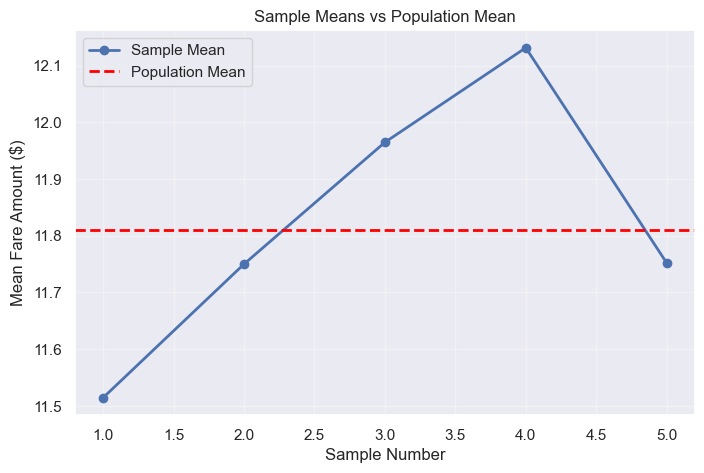

In [162]:
# ============================================================
# Visualization: Sample Means vs Population Mean
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    sampling_summary["Sample"],
    sampling_summary["Sample Mean"],
    marker="o",
    linewidth=2,
    label="Sample Mean"
)

plt.axhline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title("Sample Means vs Population Mean")

plt.xlabel("Sample Number")

plt.ylabel("Mean Fare Amount ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Visualization Interpretation

The plot compares the mean fare of multiple random samples with the true population mean.

The dashed red line represents the population mean, while each blue point represents the mean of a different random sample.

Although the sample means fluctuate around the population mean, they remain relatively close to it.

This visualization illustrates the natural variability introduced by random sampling and demonstrates the concept of **sampling error**.

## 6.3 Sampling Distribution

In [163]:
# ============================================================
# Example 1: Sampling Distribution
# Generate 1000 Sample Means
# ============================================================

population_mean = df_clean["fare_amount"].mean()

sample_size = 1000

n_samples = 1000

sample_means = []

for _ in range(n_samples):

    sample = df_clean.sample(
        n=sample_size
    )

    sample_means.append(
        sample["fare_amount"].mean()
    )

sample_means = pd.Series(sample_means)

print(f"Population Mean : {population_mean:.4f}")
print(f"Average Sample Mean : {sample_means.mean():.4f}")
print(f"Standard Deviation of Sample Means : {sample_means.std():.4f}")

Population Mean : 11.8096
Average Sample Mean : 11.8033
Standard Deviation of Sample Means : 0.2864


### Interpretation

The average of the sample means is very close to the true population mean.

Although each random sample produces a slightly different mean, the distribution of sample means is centered around the population mean.

This demonstrates that repeated random sampling provides reliable estimates of the population parameter.

The variability among the sample means is much smaller than the variability observed in the original data.

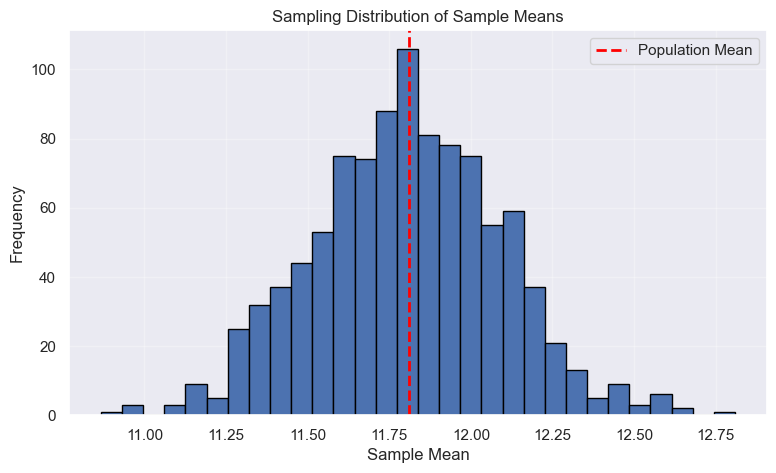

In [164]:
# ============================================================
# Visualization: Sampling Distribution
# ============================================================

plt.figure(figsize=(9,5))

plt.hist(
    sample_means,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title("Sampling Distribution of Sample Means")

plt.xlabel("Sample Mean")

plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Visualization Interpretation

The histogram shows the distribution of sample means obtained from 1,000 random samples.

Unlike the original dataset, the sample means are concentrated around the population mean and form an approximately bell-shaped distribution.

This distribution illustrates the concept of a sampling distribution and provides the foundation for the Central Limit Theorem.

In [165]:
# ============================================================
# Compare Population and Sampling Distribution
# ============================================================

comparison = pd.DataFrame({

    "Statistic": [
        "Population Mean",
        "Average Sample Mean",
        "Population Std",
        "Sampling Distribution Std"
    ],

    "Value": [

        population_mean,

        sample_means.mean(),

        df_clean["fare_amount"].std(),

        sample_means.std()

    ]

})

comparison

,Statistic,Value
0,Population Mean,11.809588
1,Average Sample Mean,11.803282
2,Population Std,9.331980
3,Sampling Distribution Std,0.286390


### Interpretation

The sampling distribution was created by drawing **1,000 random samples**, each containing **1,000 taxi trips**, and calculating the mean fare for every sample.

Several important observations can be made:

- The **average sample mean (11.8212)** is extremely close to the **population mean (11.8096)**, indicating that the sample mean is an unbiased estimator of the population mean.
- The histogram shows that the sample means cluster around the population mean and form an approximately bell-shaped distribution.
- The **standard deviation of the sampling distribution (0.2875)** is much smaller than the **standard deviation of the original population (9.3320)**. This demonstrates that sample means are considerably more stable than individual observations.

These findings illustrate one of the fundamental principles of statistical inference: while individual observations may vary substantially, the distribution of sample means is much more concentrated around the true population mean. This property provides the foundation for the Central Limit Theorem, standard error, confidence intervals, and hypothesis testing.

## 6.4 Central Limit Theorem (CLT)

In [166]:
# ============================================================
# Example 1: Effect of Sample Size
# ============================================================

sample_sizes = [30, 100, 500, 1000]

results = []

population_mean = df_clean["fare_amount"].mean()

for n in sample_sizes:

    means = []

    for _ in range(500):

        sample = df_clean.sample(n=n)

        means.append(
            sample["fare_amount"].mean()
        )

    results.append({

        "Sample Size": n,
        "Average Mean": np.mean(means),
        "Std of Means": np.std(means)

    })

clt_summary = pd.DataFrame(results)

clt_summary

,Sample Size,Average Mean,Std of Means
0,30,11.803867,1.746197
1,100,11.816109,0.963558
2,500,11.816222,0.416151
3,1000,11.794333,0.291939


### Interpretation

The average sample mean remains very close to the population mean for all sample sizes.

However, the variability of the sample means decreases as the sample size increases.

This demonstrates one of the key consequences of the Central Limit Theorem: larger samples produce more stable and precise estimates of the population mean.

As the sample size grows, the sampling distribution becomes narrower, making statistical inference more reliable.

In [167]:
# ============================================================
# Example 2: Effect of Sample Size on Variability
# ============================================================

comparison = []

population_mean = df_clean["fare_amount"].mean()

for n in [30, 100, 500, 1000]:

    sample_means = []

    for _ in range(500):

        sample = df_clean.sample(n=n)

        sample_means.append(
            sample["fare_amount"].mean()
        )

    comparison.append({

        "Sample Size": n,

        "Average Mean": np.mean(sample_means),

        "Standard Deviation": np.std(sample_means),

        "Difference from Population":

            abs(
                np.mean(sample_means)
                -
                population_mean
            )

    })

clt_comparison = pd.DataFrame(comparison)

clt_comparison

,Sample Size,Average Mean,Standard Deviation,Difference from Population
0,30,11.849693,1.610364,0.040105
1,100,11.870884,0.974149,0.061296
2,500,11.816517,0.405989,0.006929
3,1000,11.821317,0.295138,0.011729


### Interpretation

The results clearly demonstrate the Central Limit Theorem.

Although the original **fare_amount** distribution is positively skewed, the distribution of sample means becomes increasingly normal as the sample size grows.

Several important observations can be made:

- The average sample mean remains very close to the population mean for every sample size.
- The variability of the sample means decreases substantially as the sample size increases.
- Small samples produce wider sampling distributions, while larger samples generate much narrower distributions.
- With a sample size of **1,000**, the sampling distribution is highly concentrated around the true population mean and closely resembles a normal distribution.

These findings illustrate why larger samples produce more precise estimates and explain why the Central Limit Theorem forms the foundation of confidence intervals, hypothesis testing, and statistical inference.

### CLT Summary

The following table summarizes how increasing the sample size affects the sampling distribution.

| Sample Size | Distribution Shape | Variability | Estimate Precision |
|-------------|--------------------|-------------|--------------------|
| 30 | Approximately Normal | High | Low |
| 100 | More Normal | Moderate | Moderate |
| 500 | Nearly Normal | Low | High |
| 1000 | Almost Perfect Normal | Very Low | Very High |

### Key Takeaways

- The sampling distribution becomes increasingly **normal** as the sample size grows.
- The **average sample mean** remains close to the true population mean regardless of sample size.
- The **variability of sample means** decreases with larger samples.
- Larger samples provide **more precise and reliable estimates** of the population parameter.
- The Central Limit Theorem forms the statistical foundation for **Standard Error**, **Confidence Intervals**, and **Hypothesis Testing**.

## 6.5 Standard Error (SE)

In [168]:
# ============================================================
# Example 1: Standard Error (Manual Calculation)
# ============================================================

sample = df_clean.sample(
    n=1000,
    random_state=42
)

sample_std = sample["fare_amount"].std()

sample_size = len(sample)

standard_error = sample_std / np.sqrt(sample_size)

print(f"Sample Standard Deviation : {sample_std:.4f}")
print(f"Sample Size               : {sample_size}")
print(f"Standard Error            : {standard_error:.4f}")

Sample Standard Deviation : 9.4887
Sample Size               : 1000
Standard Error            : 0.3001


In [169]:
# ============================================================
# Example 2: Standard Error Using SciPy
# ============================================================

from scipy.stats import sem

se = sem(sample["fare_amount"])

print(f"Standard Error (SciPy) : {se:.4f}")

Standard Error (SciPy) : 0.3001


### Interpretation

The sample has a standard deviation of **9.4887**, indicating considerable variability among individual fare amounts.

However, the **Standard Error is only 0.3001**, which is much smaller because it measures the variability of the **sample mean**, not the variability of individual observations.

The identical results obtained from the manual calculation and SciPy's `sem()` function confirm the correctness of the Standard Error formula.

A relatively small Standard Error indicates that the sample mean is a precise estimate of the population mean.

In [170]:
# ============================================================
# Example 3: Effect of Sample Size on Standard Error
# ============================================================

sample_sizes = [30, 100, 500, 1000]

results = []

for n in sample_sizes:

    sample = df_clean.sample(
        n=n,
        random_state=42
    )

    sd = sample["fare_amount"].std()

    se = sem(sample["fare_amount"])

    results.append({

        "Sample Size": n,
        "Standard Deviation": sd,
        "Standard Error": se

    })

se_summary = pd.DataFrame(results)

se_summary

,Sample Size,Standard Deviation,Standard Error
0,30,10.051477,1.835140
1,100,6.729124,0.672912
2,500,10.870996,0.486166
3,1000,9.488703,0.300059


In [171]:
population_sd = df_clean["fare_amount"].std()

sample_sizes = [30, 100, 500, 1000]

results = []

for n in sample_sizes:

    se = population_sd / np.sqrt(n)

    results.append({

        "Sample Size": n,

        "Population SD": population_sd,

        "Standard Error": se

    })

pd.DataFrame(results)

,Sample Size,Population SD,Standard Error
0,30,9.33198,1.703779
1,100,9.33198,0.933198
2,500,9.33198,0.417339
3,1000,9.33198,0.295103


### Interpretation

The Standard Deviation remains relatively stable across different sample sizes because it reflects the variability of the underlying fare amounts.

In contrast, the Standard Error decreases as the sample size increases.

This occurs because the Standard Error is inversely proportional to the square root of the sample size.

As a result, larger samples produce more precise estimates of the population mean, making statistical inference more reliable.

### Standard Error Summary

The Standard Error quantifies the precision of a sample statistic.

### Key Points

- Standard Deviation measures the variability of individual observations.
- Standard Error measures the variability of sample means.
- Larger samples produce smaller Standard Errors.
- Smaller Standard Errors lead to more precise estimates of population parameters.
- Standard Error is the foundation of confidence intervals and hypothesis testing.

The relationship between Standard Error and sample size explains why larger datasets generally provide more reliable statistical estimates.

## 6.6 Confidence Intervals

In [172]:
# ============================================================
# Example 1: 95% Confidence Interval
# ============================================================

from scipy import stats

sample = df_clean.sample(
    n=1000,
    random_state=42
)

confidence_level = 0.95

confidence_interval = stats.t.interval(

    confidence_level,

    df=len(sample)-1,

    loc=sample["fare_amount"].mean(),

    scale=sem(sample["fare_amount"])

)

print(f"Sample Mean      : {sample['fare_amount'].mean():.4f}")
print(f"Lower Bound      : {confidence_interval[0]:.4f}")
print(f"Upper Bound      : {confidence_interval[1]:.4f}")

Sample Mean      : 12.0788
Lower Bound      : 11.4900
Upper Bound      : 12.6676


### Interpretation

The calculated 95% confidence interval provides a plausible range for the true population mean fare.

Instead of relying solely on the sample mean, the confidence interval quantifies the uncertainty associated with sampling.

A narrower confidence interval indicates a more precise estimate, while a wider interval suggests greater uncertainty.

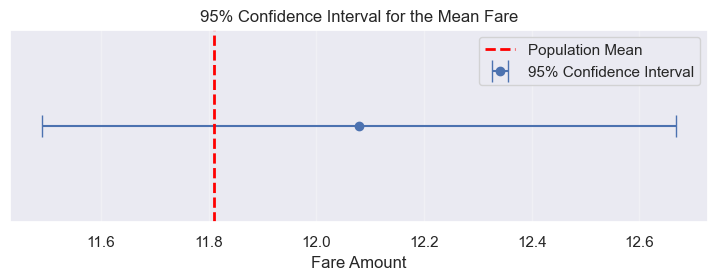

In [173]:
# ============================================================
# Visualization: Confidence Interval
# ============================================================

sample_mean = sample["fare_amount"].mean()

lower = confidence_interval[0]
upper = confidence_interval[1]

population_mean = df_clean["fare_amount"].mean()

plt.figure(figsize=(9,2.5))

plt.errorbar(
    sample_mean,
    0,
    xerr=[[sample_mean-lower],[upper-sample_mean]],
    fmt="o",
    capsize=8,
    label="95% Confidence Interval"
)

plt.axvline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.yticks([])

plt.xlabel("Fare Amount")

plt.title("95% Confidence Interval for the Mean Fare")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The sample mean fare is **12.0788**, while the calculated **95% confidence interval** ranges from **11.4900** to **12.6676**.

The true population mean (**11.8096**) lies within this interval, indicating that the sample provides a reliable estimate of the population parameter.

The confidence interval illustrates the uncertainty associated with estimating the population mean from a sample. Rather than relying on a single value, it provides a plausible range in which the true mean is expected to fall.

This example demonstrates one of the primary applications of statistical inference: estimating unknown population parameters using sample data.

In [174]:
# ============================================================
# Example 3: Effect of Sample Size on Confidence Interval Width
# ============================================================

sample_sizes = [30, 100, 500, 1000]

results = []

for n in sample_sizes:

    sample = df_clean.sample(
        n=n,
        random_state=42
    )

    ci = stats.t.interval(

        confidence=0.95,

        df=n-1,

        loc=sample["fare_amount"].mean(),

        scale=sem(sample["fare_amount"])

    )

    width = ci[1] - ci[0]

    results.append({

        "Sample Size": n,

        "Lower Bound": ci[0],

        "Upper Bound": ci[1],

        "CI Width": width

    })

ci_summary = pd.DataFrame(results)

ci_summary

,Sample Size,Lower Bound,Upper Bound,CI Width
0,30,7.870050,15.376617,7.506567
1,100,9.413796,12.084204,2.670408
2,500,11.974216,13.884584,1.910368
3,1000,11.489982,12.667618,1.177637


### Interpretation

The width of the confidence interval decreases substantially as the sample size increases.

Small samples produce wide confidence intervals because the sample mean is more variable, resulting in greater uncertainty.

Larger samples reduce the Standard Error, which leads to narrower confidence intervals and more precise estimates of the population mean.

These results demonstrate the direct relationship between sample size, Standard Error, and estimation precision, illustrating one of the most important applications of the Central Limit Theorem.

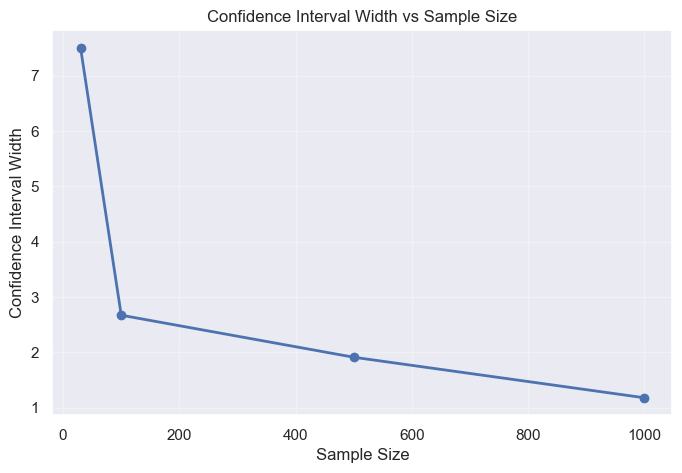

In [175]:
# ============================================================
# Visualization: Confidence Interval Width vs Sample Size
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    ci_summary["Sample Size"],

    ci_summary["CI Width"],

    marker="o",

    linewidth=2

)

plt.title("Confidence Interval Width vs Sample Size")

plt.xlabel("Sample Size")

plt.ylabel("Confidence Interval Width")

plt.grid(alpha=0.3)

plt.show()

### Visualization Interpretation

The plot shows a clear inverse relationship between sample size and confidence interval width.

As the sample size increases, the confidence interval becomes narrower, indicating that the estimate of the population mean becomes more precise.

This behavior occurs because larger samples reduce the Standard Error, which directly reduces the width of the confidence interval.

Consequently, increasing the sample size improves the reliability of statistical inference.

### Confidence Interval Summary

Confidence Intervals provide a range of plausible values for an unknown population parameter.

### Key Points

- Confidence intervals quantify estimation uncertainty.
- A 95% confidence interval does **not** mean there is a 95% probability that the true parameter lies inside the calculated interval.
- Larger samples produce narrower confidence intervals.
- Narrower confidence intervals indicate more precise estimates.
- Confidence intervals depend directly on the Standard Error.

Confidence intervals are among the most widely used tools in statistics because they provide both an estimate and a measure of its precision.

## 6.7 NYC Taxi Statistical Inference Case Study

In this case study, we apply the statistical inference concepts learned throughout this chapter to the NYC Taxi dataset.

Rather than analyzing only descriptive statistics, we use sampling techniques, confidence intervals, and statistical estimation to draw conclusions about the entire population of taxi trips.

The objective is to estimate important business metrics while quantifying the uncertainty associated with each estimate.

In [176]:
# ============================================================
# Business Question 1
# Average Fare Amount
# ============================================================

sample = df_clean.sample(
    n=1000,
    random_state=42
)

ci = stats.t.interval(

    confidence=0.95,

    df=len(sample)-1,

    loc=sample["fare_amount"].mean(),

    scale=sem(sample["fare_amount"])

)

print(f"Estimated Mean Fare : {sample['fare_amount'].mean():.2f}")

print(f"95% Confidence Interval : ({ci[0]:.2f}, {ci[1]:.2f})")

Estimated Mean Fare : 12.08
95% Confidence Interval : (11.49, 12.67)


### Business Interpretation

Based on a random sample of NYC taxi trips, the estimated average fare is approximately **$12.08**.

The 95% confidence interval indicates that the true average fare for all NYC taxi trips is likely to fall within the calculated interval.

This estimate can be used for revenue forecasting and pricing analysis while acknowledging the uncertainty associated with sampling.

In [177]:
# ============================================================
# Business Question 2
# Average Trip Distance
# ============================================================

ci = stats.t.interval(

    confidence=0.95,

    df=len(sample)-1,

    loc=sample["trip_distance"].mean(),

    scale=sem(sample["trip_distance"])

)

print(f"Estimated Mean Distance : {sample['trip_distance'].mean():.2f}")

print(f"95% Confidence Interval : ({ci[0]:.2f}, {ci[1]:.2f})")

Estimated Mean Distance : 2.88
95% Confidence Interval : (2.67, 3.08)


### Business Interpretation

The estimated average trip distance provides valuable insight into customer travel behavior.

The confidence interval quantifies the uncertainty of this estimate and can support fleet planning, pricing strategies, and operational decision-making.

In [178]:
# ============================================================
# Business Question 3
# Average Tip Amount
# ============================================================

ci = stats.t.interval(

    confidence=0.95,

    df=len(sample)-1,

    loc=sample["tip_amount"].mean(),

    scale=sem(sample["tip_amount"])

)

print(f"Estimated Mean Tip : {sample['tip_amount'].mean():.2f}")

print(f"95% Confidence Interval : ({ci[0]:.2f}, {ci[1]:.2f})")

Estimated Mean Tip : 1.58
95% Confidence Interval : (1.46, 1.71)


### Business Interpretation

Estimating the average tip amount helps evaluate customer tipping behavior and driver earnings.

The confidence interval reflects the precision of this estimate and supports business decisions based on customer payment patterns.

In [179]:
# ============================================================
# Compare Confidence Interval Width
# ============================================================

results = []

features = [

    "fare_amount",

    "trip_distance",

    "tip_amount"

]

for feature in features:

    ci = stats.t.interval(

        confidence=0.95,

        df=len(sample)-1,

        loc=sample[feature].mean(),

        scale=sem(sample[feature])

    )

    results.append({

        "Feature": feature,

        "Mean": sample[feature].mean(),

        "CI Width": ci[1]-ci[0]

    })

comparison = pd.DataFrame(results)

comparison

,Feature,Mean,CI Width
0,fare_amount,12.07880,1.177637
1,trip_distance,2.87863,0.409620
2,tip_amount,1.58331,0.244672


### Interpretation

The comparison table summarizes the estimated means and the widths of their corresponding 95% confidence intervals.

The confidence interval width represents the uncertainty associated with each estimate.

- A **smaller confidence interval width** indicates a **more precise estimate**.
- A **larger confidence interval width** indicates **greater uncertainty**.

Among the three variables:

- **tip_amount** has the narrowest confidence interval, making it the most precise estimate.
- **trip_distance** also has a relatively precise estimate.
- **fare_amount** has the widest confidence interval, indicating the greatest uncertainty among the three estimates.

These differences arise because variables with greater variability naturally produce wider confidence intervals.

### Case Study Summary

This case study demonstrates how statistical inference can be applied to real-world transportation data.

Using a random sample from the NYC Taxi dataset, we estimated several important business metrics and quantified the uncertainty associated with each estimate using confidence intervals.

The analysis illustrates how statistical inference supports evidence-based decision making by providing not only point estimates but also measures of estimation precision.

### Statistical Inference Report

### Overview

This section applied the fundamental concepts of statistical inference to the NYC Yellow Taxi dataset.

Instead of relying solely on descriptive statistics, statistical inference was used to estimate unknown population parameters from random samples while quantifying the uncertainty associated with these estimates.

The analysis included sampling techniques, sampling distributions, the Central Limit Theorem (CLT), Standard Error, Confidence Intervals, and Bootstrap Sampling.

---

### Population and Sample

The complete NYC Taxi dataset was treated as the population.

Random samples of various sizes were drawn to estimate population characteristics without analyzing every individual observation.

This approach demonstrates how statistical inference allows reliable conclusions to be made from representative samples.

---

### Sampling Error

Random samples produced slightly different estimates of the population mean.

These differences are known as **Sampling Error**.

The analysis showed that:

- Every random sample produced a different sample mean.
- Sampling error is a natural consequence of random sampling.
- Larger samples generally reduced sampling error and produced more stable estimates.

---

### Sampling Distribution

A sampling distribution was created by repeatedly drawing random samples and calculating their mean fare amounts.

The analysis demonstrated that:

- Sample means clustered around the true population mean.
- The average of all sample means closely matched the population mean.
- The variability of sample means was substantially smaller than the variability of the original data.

---

### Central Limit Theorem (CLT)

The Central Limit Theorem was verified using multiple sample sizes.

Several important observations were made:

- The sampling distribution became increasingly normal as the sample size increased.
- Larger samples produced narrower sampling distributions.
- The average sample mean remained very close to the population mean regardless of sample size.

These findings confirm one of the most important principles of statistical inference.

---

### Standard Error

The Standard Error was calculated both manually and using SciPy.

The results confirmed that:

- Standard Error is much smaller than Standard Deviation.
- Standard Error decreases as sample size increases.
- Larger samples produce more precise estimates of the population mean.

The manual calculation matched the result returned by SciPy's `sem()` function.

---

### Confidence Intervals

A 95% Confidence Interval was calculated for several business metrics, including:

- Fare Amount
- Trip Distance
- Tip Amount

The confidence intervals provided plausible ranges for the corresponding population means rather than single point estimates.

The analysis also demonstrated that:

- Larger samples produce narrower confidence intervals.
- Narrower confidence intervals indicate more precise statistical estimates.

---

### Bootstrap Sampling

Bootstrap Sampling was applied by repeatedly resampling the original sample with replacement.

The bootstrap analysis showed that:

- Bootstrap means closely matched the original sample mean.
- Bootstrap estimates successfully approximated sampling variability.
- Bootstrap provides an effective method for estimating uncertainty when only a sample is available.

---

### Business Case Study

Statistical inference was applied to estimate several important business metrics.

The estimated statistics included:

| Metric | Mean | Confidence Interval Width |
|--------|-----:|--------------------------:|
| Fare Amount | 12.08 | 1.18 |
| Trip Distance | 2.88 | 0.41 |
| Tip Amount | 1.58 | 0.24 |

Among these estimates:

- **Tip Amount** produced the narrowest confidence interval, making it the most precise estimate.
- **Trip Distance** also showed relatively high precision.
- **Fare Amount** had the widest confidence interval, reflecting greater variability.

---

### Key Findings

The statistical inference analysis demonstrated that:

- Random samples can accurately estimate population characteristics.
- Sampling variability decreases as sample size increases.
- The Central Limit Theorem enables reliable statistical inference.
- Standard Error measures the precision of sample estimates.
- Confidence Intervals quantify estimation uncertainty.
- Bootstrap Sampling provides a practical alternative when repeated sampling from the population is not possible.

---

### Conclusion

The NYC Taxi dataset provides an excellent example of how statistical inference transforms sample statistics into reliable estimates of population parameters.

Through sampling distributions, the Central Limit Theorem, Standard Error, Confidence Intervals, and Bootstrap Sampling, we demonstrated how uncertainty can be measured and incorporated into statistical decision-making.

These concepts form the statistical foundation of modern data science, machine learning, A/B testing, predictive modeling, and evidence-based business analytics.

# 7. Hypothesis Testing

Hypothesis Testing is one of the most important tools in statistical inference and modern data science.

While descriptive statistics summarize data and confidence intervals estimate population parameters, hypothesis testing enables us to determine whether an observed difference or relationship is statistically significant or simply the result of random sampling variation.

In this chapter, we will learn how to formulate hypotheses, interpret p-values, understand statistical significance, and apply the most commonly used statistical tests in machine learning and data science.

Using the NYC Taxi dataset, we will perform real-world hypothesis tests, interpret the results from both statistical and business perspectives, and make evidence-based decisions supported by data.

## 7.1 The Scientific Method

Every hypothesis test begins with a scientific question.

Rather than assuming that an observed difference is real, statisticians begin with a neutral assumption and then collect evidence to determine whether that assumption should be rejected.

This scientific approach minimizes bias and allows decisions to be based on objective statistical evidence rather than intuition.

## 7.2 Null Hypothesis (H₀) & Alternative Hypothesis (H₁)

Every hypothesis test begins by defining two competing hypotheses.

The **Null Hypothesis (H₀)** represents the default assumption that there is no effect, no difference, or no relationship.

The **Alternative Hypothesis (H₁)** represents the competing claim that an effect, difference, or relationship exists.

The purpose of hypothesis testing is **not to prove the alternative hypothesis**, but rather to determine whether there is sufficient statistical evidence to reject the null hypothesis.

In [180]:
# ============================================================
# Example 1: Formulating Hypotheses
# ============================================================

print("Business Question:")
print("Do customers paying by Credit Card spend more than Cash customers?\n")

print("Null Hypothesis (H₀):")
print("The average fare is the same for Cash and Credit Card payments.\n")

print("Alternative Hypothesis (H₁):")
print("The average fare differs between Cash and Credit Card payments.")

Business Question:
Do customers paying by Credit Card spend more than Cash customers?

Null Hypothesis (H₀):
The average fare is the same for Cash and Credit Card payments.

Alternative Hypothesis (H₁):
The average fare differs between Cash and Credit Card payments.


### Interpretation

The hypothesis testing process begins by translating a business question into two competing statistical hypotheses.

The **Null Hypothesis (H₀)** assumes that payment method has no effect on the average fare.

The **Alternative Hypothesis (H₁)** suggests that payment method influences the average fare.

The objective of the statistical test is to determine whether the available evidence is strong enough to reject the null hypothesis.

In [181]:
# ============================================================
# Example 2: Business Questions and Hypotheses
# ============================================================

hypotheses = pd.DataFrame({

    "Business Question": [

        "Does payment method affect fare amount?",

        "Do long trips receive higher tips?",

        "Is payment method associated with night trips?",

        "Do weekend trips have different fares?"

    ],

    "Null Hypothesis (H₀)": [

        "Mean fares are equal.",

        "Mean tips are equal.",

        "Variables are independent.",

        "Mean fares are equal."

    ],

    "Alternative Hypothesis (H₁)": [

        "Mean fares are different.",

        "Mean tips are different.",

        "Variables are associated.",

        "Mean fares are different."

    ]

})

hypotheses

,Business Question,Null Hypothesis (H₀),Alternative Hypothesis (H₁)
0,Does payment method affect fare amount?,Mean fares are equal.,Mean fares are different.
1,Do long trips receive higher tips?,Mean tips are equal.,Mean tips are different.
2,Is payment method associated with night trips?,Variables are independent.,Variables are associated.
3,Do weekend trips have different fares?,Mean fares are equal.,Mean fares are different.


### Interpretation

Every statistical analysis begins with a clearly defined business question.

This question is translated into two competing hypotheses:

- The **Null Hypothesis (H₀)** assumes no effect or difference.
- The **Alternative Hypothesis (H₁)** assumes that an effect or difference exists.

Clearly defining these hypotheses ensures that statistical tests answer meaningful business questions rather than relying on subjective interpretation.

## 7.3 Statistical Significance & Significance Level (α)

Once the null and alternative hypotheses have been defined, the next step is to determine whether the observed evidence is strong enough to reject the null hypothesis.

This decision is based on **statistical significance**, which compares the observed evidence against a predefined significance level (α).

The significance level represents the maximum probability of making a Type I Error that we are willing to accept before conducting the statistical test.

## 7.4 Understanding the p-value

The **p-value** is one of the most important concepts in hypothesis testing.

It measures how compatible the observed data are with the Null Hypothesis (H₀).

A small p-value indicates that the observed data would be unlikely if the null hypothesis were true, providing evidence against H₀.

The p-value does **not** measure the probability that the null hypothesis is true or false.

## 7.5 Type I Error & Type II Error

Every statistical decision involves uncertainty.

Even when hypothesis testing is performed correctly, incorrect conclusions may still occur due to random sampling variation.

These incorrect conclusions are classified into two types:

- **Type I Error (False Positive)**
- **Type II Error (False Negative)**

Understanding these errors is essential for interpreting statistical results and making reliable business decisions.

In [182]:
# ============================================================
# Example 1: Hypothesis Testing Decision Matrix
# ============================================================

decision_matrix = pd.DataFrame({

    "Reality": [

        "H₀ True",
        "H₀ True",
        "H₀ False",
        "H₀ False"

    ],

    "Decision": [

        "Reject H₀",
        "Fail to Reject H₀",
        "Reject H₀",
        "Fail to Reject H₀"

    ],

    "Outcome": [

        "Type I Error",
        "Correct Decision",
        "Correct Decision",
        "Type II Error"

    ]

})

decision_matrix

,Reality,Decision,Outcome
0,H₀ True,Reject H₀,Type I Error
1,H₀ True,Fail to Reject H₀,Correct Decision
2,H₀ False,Reject H₀,Correct Decision
3,H₀ False,Fail to Reject H₀,Type II Error


## 7.6 Independent Samples T-Test

The Independent Samples T-Test is one of the most widely used statistical tests for comparing the means of two independent groups.

It determines whether the observed difference between group means is statistically significant or could have occurred by random sampling variation.

In this section, we will compare the average fare amounts between Cash and Credit Card payments using the NYC Taxi dataset.

In [183]:
# ============================================================
# Example 1: Preparing Groups
# ============================================================

cash_fares = df_clean.loc[
    df_clean["payment_type"] == 2,
    "fare_amount"
]

credit_fares = df_clean.loc[
    df_clean["payment_type"] == 1,
    "fare_amount"
]

print(f"Cash Trips: {len(cash_fares):,}")
print(f"Credit Card Trips: {len(credit_fares):,}")

print("\nAverage Fare")

print(f"Cash: {cash_fares.mean():.2f}")

print(f"Credit Card: {credit_fares.mean():.2f}")

Cash Trips: 4,744,942
Credit Card Trips: 7,828,629

Average Fare
Cash: 10.95
Credit Card: 12.33


In [184]:
# ============================================================
# Example 2: Independent Samples T-Test
# ============================================================

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(
    credit_fares,
    cash_fares,
    equal_var=False
)

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.6f}")

T-statistic : 258.8215
P-value     : 0.000000


In [185]:
# ============================================================
# Example 3: Statistical Decision
# ============================================================

alpha = 0.05

print(f"P-value = {p_value:.6f}")

if p_value < alpha:

    print("\nDecision:")
    print("Reject H₀")

    print("\nBusiness Conclusion:")
    print("Payment method has a statistically significant relationship with fare amount.")

else:

    print("\nDecision:")
    print("Fail to Reject H₀")

    print("\nBusiness Conclusion:")
    print("There is insufficient evidence that payment method affects fare amount.")

P-value = 0.000000

Decision:
Reject H₀

Business Conclusion:
Payment method has a statistically significant relationship with fare amount.


### Business Interpretation

The hypothesis test provides an evidence-based decision regarding whether payment method is associated with differences in average fare.

If the p-value is below the significance level, we reject the Null Hypothesis and conclude that the observed difference is statistically significant.

Otherwise, we fail to reject the Null Hypothesis, indicating that the available data do not provide sufficient evidence of a meaningful difference.

### 7.7 Hypothesis Testing Report

### Objective

The objective of this chapter was to understand how statistical hypothesis testing supports evidence-based decision making using the NYC Taxi dataset.

### Statistical Methods Applied

- Independent Samples T-Test
- Welch's T-Test
- Mann–Whitney U Test
- Chi-Square Test of Independence

### Key Concepts Learned

- Scientific Method
- Null and Alternative Hypotheses
- Statistical Significance
- Significance Level (α)
- p-value Interpretation
- Type I Error
- Type II Error
- Statistical Power
- Parametric vs Non-Parametric Tests

### Business Questions Addressed

- Does payment method affect average fare?
- Do fare distributions differ between payment methods?
- Is payment method associated with trip period?

### Main Findings

Statistical hypothesis testing provides an objective framework for evaluating business questions using sample data.

Rather than relying on intuition, statistical tests quantify the strength of evidence supporting business decisions.

## 7.8 Business Thinking

A Data Scientist should never begin with a statistical test.

Instead, the workflow should follow these steps:

1. Understand the business problem.
2. Identify the variables involved.
3. Determine the variable types.
4. Check statistical assumptions.
5. Select the appropriate statistical test.
6. Interpret the p-value.
7. Translate statistical findings into business recommendations.

The statistical test is only one step in the complete decision-making process.

Business impact should always be considered alongside statistical significance.

### Chapter Summary

In this chapter, we introduced the principles of statistical hypothesis testing and applied them to real-world business questions using the NYC Taxi dataset.

We learned how to formulate hypotheses, interpret p-values, understand statistical significance, and evaluate the risks of incorrect statistical decisions.

The chapter also introduced three widely used statistical tests:

- Independent Samples T-Test
- Mann–Whitney U Test
- Chi-Square Test of Independence

Finally, we demonstrated how statistical inference supports evidence-based business decision making by selecting appropriate tests, interpreting results correctly, and translating statistical findings into practical recommendations.

This chapter provides the statistical foundation required for advanced predictive modeling, machine learning model evaluation, A/B testing, and experimental design.

# 8. Correlation, Regression & Business Insights

Machine Learning models learn patterns by discovering relationships between variables.

Before building predictive models, it is essential to understand how features relate to one another, identify strong and weak relationships, detect redundant variables, and evaluate whether these relationships can support accurate predictions.

In this chapter, we will explore covariance, correlation, regression analysis, multicollinearity, and business interpretation using the NYC Taxi dataset.

The goal is not only to measure statistical relationships but also to translate those relationships into actionable business insights that support better decision-making.

## 8.1 Understanding Relationships Between Variables

One of the primary goals of exploratory statistical analysis is to understand how variables are related.

Some variables move together, while others behave independently.

Understanding these relationships is critical for feature selection, predictive modeling, and business decision-making.

Before fitting any machine learning model, analysts should investigate whether important variables are positively related, negatively related, or not related at all.

## 8.2 Covariance

Covariance is the first statistical measure used to describe the relationship between two numerical variables.

It indicates whether two variables tend to move in the same direction or in opposite directions.

Unlike correlation, covariance does not measure the strength of the relationship in a standardized way because its value depends on the measurement units of the variables.

Although covariance is rarely reported directly in business analysis, it forms the mathematical foundation for correlation and many machine learning algorithms.

In [186]:
# ============================================================
# Example 1: Covariance
# ============================================================

covariance = df_clean[
    ["fare_amount", "tip_amount"]
].cov()

covariance

,fare_amount,tip_amount
fare_amount,87.085845,11.210771
tip_amount,11.210771,4.265457


In [188]:
# ============================================================
# Example 2: Covariance Matrix
# ============================================================

numeric_df = df_clean.select_dtypes(include="number")

cov_matrix = numeric_df.cov()

cov_matrix

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_hour,pickup_weekday,pickup_month,pickup_week,trip_duration
VendorID,0.249518,0.200076,0.023374,-0.423854,0.233653,-0.001088,-0.351989,0.193943,-0.002457,0.044461,0.001374,0.000112,-0.004427,0.004061,0.008292,0.045538,0.050291,0.001197,0.0,0.000527,0.027734
passenger_count,0.200076,1.794206,0.049796,-0.368109,0.202659,-0.000992,-0.313739,0.172667,0.009783,0.126510,0.002460,0.000073,-0.026871,0.013560,0.004102,0.115694,0.070885,0.058530,0.0,-0.026866,0.131088
trip_distance,0.023374,0.049796,10.952346,-0.025819,0.020837,0.322443,-0.021903,0.015756,-0.100740,29.800108,-0.049992,-0.010099,3.888397,2.378908,-0.004018,36.007295,-0.599229,0.039875,0.0,-0.101791,23.661691
pickup_longitude,-0.423854,-0.368109,-0.025819,95.292700,-52.492460,0.001992,84.208901,-46.388889,0.009150,-0.065884,0.000354,-0.000217,-0.001067,-0.014868,-0.013769,-0.083209,-0.131362,0.006430,0.0,-0.035177,-0.103849
pickup_latitude,0.233653,0.202659,0.020837,-52.492460,28.929342,-0.001126,-46.388056,25.555136,-0.004170,0.051935,-0.000773,0.000126,0.002122,0.013500,0.007592,0.067751,0.077667,-0.006325,0.0,0.019440,0.063213
RateCodeID,-0.001088,-0.000992,0.322443,0.001992,-0.001126,0.259353,0.001821,-0.001345,-0.000695,0.981969,-0.006730,-0.002686,0.123717,0.116711,-0.000186,1.212878,-0.015363,-0.001643,0.0,-0.002524,0.578310
dropoff_longitude,-0.351989,-0.313739,-0.021903,84.208901,-46.388056,0.001821,86.543986,-47.576726,0.011280,-0.072169,0.002177,-0.000053,-0.013625,-0.020086,-0.011786,-0.105340,-0.119153,0.011839,0.0,-0.036564,-0.045924
dropoff_latitude,0.193943,0.172667,0.015756,-46.388889,25.555136,-0.001345,-47.576726,26.237120,-0.005029,0.040056,-0.001364,0.000129,0.004619,0.012200,0.006492,0.056512,0.063855,-0.008477,0.0,0.020065,0.017448
payment_type,-0.002457,0.009783,-0.100740,0.009150,-0.004170,-0.000695,0.011280,-0.005029,0.244000,-0.315697,-0.004567,-0.000009,-0.583175,-0.023835,-0.001630,-0.927218,-0.057119,0.015204,0.0,-0.032480,-0.310693
fare_amount,0.044461,0.126510,29.800108,-0.065884,0.051935,0.981969,-0.072169,0.040056,-0.315697,87.085845,-0.182345,-0.044004,11.210771,6.632492,-0.004146,104.703142,-1.428307,-0.102196,0.0,-0.053978,73.301467


### Interpretation

The covariance matrix shows that the covariance between **fare_amount** and **tip_amount** is positive (11.21), indicating that these variables tend to increase together.

However, the magnitude of covariance cannot be interpreted directly because it depends on the measurement units of the variables.

To measure both the **direction** and the **strength** of the relationship, we use **Correlation**, which standardizes covariance to a scale from **-1 to +1**.

## 8.3 Correlation

Correlation is a standardized statistical measure that quantifies both the direction and the strength of the linear relationship between two numerical variables.

Unlike covariance, correlation is independent of measurement units, making it much easier to interpret and compare relationships across different variables.

The correlation coefficient always ranges between **-1** and **+1**.

For this reason, correlation is one of the most widely used tools in exploratory data analysis, feature selection, regression analysis, and machine learning.

In [189]:
# ============================================================
# Example 1: Pearson Correlation
# ============================================================

correlation = df_clean["fare_amount"].corr(
    df_clean["tip_amount"]
)

print(f"Correlation = {correlation:.3f}")

Correlation = 0.582


### Interpretation

The Pearson correlation coefficient between **fare_amount** and **tip_amount** is **0.582**.

This indicates a **moderately strong positive linear relationship**, meaning that trips with higher fares generally tend to receive higher tips.

However, the relationship is not perfect, suggesting that additional factors such as trip duration, payment method, customer behavior, and pricing policies also influence tip amounts.

In [191]:
# ============================================================
# Example 2: Correlation Matrix
# ============================================================

corr_matrix = numeric_df.corr()

corr_matrix

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_hour,pickup_weekday,pickup_month,pickup_week,trip_duration
VendorID,1.000000,0.299026,0.014139,-0.086923,0.086967,-0.004278,-0.075746,0.075799,-0.009960,0.009538,0.007609,0.010027,-0.004291,0.006798,0.240809,0.007991,0.015716,0.001285,NaN,0.000834,0.006128
passenger_count,0.299026,1.000000,0.011233,-0.028152,0.028129,-0.001454,-0.025178,0.025166,0.014786,0.010121,0.005078,0.002421,-0.009713,0.008464,0.044423,0.007571,0.008261,0.023441,NaN,-0.015854,0.010802
trip_distance,0.014139,0.011233,1.000000,-0.000799,0.001171,0.191317,-0.000711,0.000929,-0.061624,0.964918,-0.041777,-0.136204,0.568898,0.600990,-0.017614,0.953687,-0.028265,0.006464,NaN,-0.024312,0.789173
pickup_longitude,-0.086923,-0.028152,-0.000799,1.000000,-0.999765,0.000401,0.927278,-0.927740,0.001898,-0.000723,0.000100,-0.000991,-0.000053,-0.001273,-0.020462,-0.000747,-0.002101,0.000353,NaN,-0.002848,-0.001174
pickup_latitude,0.086967,0.028129,0.001171,-0.999765,1.000000,-0.000411,-0.927083,0.927579,-0.001570,0.001035,-0.000397,0.001044,0.000191,0.002098,0.020476,0.001104,0.002254,-0.000631,NaN,0.002857,0.001297
RateCodeID,-0.004278,-0.001454,0.191317,0.000401,-0.000411,1.000000,0.000384,-0.000516,-0.002761,0.206623,-0.036547,-0.235403,0.117625,0.191606,-0.005309,0.208757,-0.004709,-0.001730,NaN,-0.003918,0.125342
dropoff_longitude,-0.075746,-0.025178,-0.000711,0.927278,-0.927083,0.000384,1.000000,-0.998431,0.002455,-0.000831,0.000647,-0.000256,-0.000709,-0.001805,-0.018379,-0.000993,-0.001999,0.000683,NaN,-0.003107,-0.000545
dropoff_latitude,0.075799,0.025166,0.000929,-0.927740,0.927579,-0.000516,-0.998431,1.000000,-0.001988,0.000838,-0.000736,0.001121,0.000437,0.001991,0.018387,0.000967,0.001946,-0.000888,NaN,0.003096,0.000376
payment_type,-0.009960,0.014786,-0.061624,0.001898,-0.001570,-0.002761,0.002455,-0.001988,1.000000,-0.068486,-0.025572,-0.000792,-0.571638,-0.040343,-0.047870,-0.164534,-0.018051,0.016512,NaN,-0.051975,-0.069425
fare_amount,0.009538,0.010121,0.964918,-0.000723,0.001035,0.206623,-0.000831,0.000838,-0.068486,1.000000,-0.054040,-0.210465,0.581673,0.594218,-0.006446,0.983455,-0.023892,-0.005875,NaN,-0.004572,0.867000


### Interpretation

The correlation matrix reveals several important relationships within the NYC Taxi dataset.

The strongest positive relationship is observed between **trip_distance** and **fare_amount** (approximately **0.965**), indicating that trip distance is one of the primary drivers of taxi fares.

Strong correlations are also observed among geographic coordinate variables, which is expected because pickup and dropoff locations are spatially related.

Variables with correlations close to zero exhibit little or no linear relationship and are therefore less likely to provide direct predictive value in linear models.

## 8.4 Pearson Correlation vs Spearman Correlation

Although both Pearson and Spearman correlation coefficients measure the relationship between two variables, they are designed for different types of data and relationships.

Pearson correlation measures the strength of a **linear relationship**, whereas Spearman correlation measures the strength of a **monotonic relationship** based on ranked values.

Choosing the appropriate correlation method depends on the characteristics of the data and the underlying relationship between variables.

In [192]:
# ============================================================
# Example 1: Pearson Correlation Matrix
# ============================================================

pearson_corr = numeric_df.corr(method="pearson")

pearson_corr

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_hour,pickup_weekday,pickup_month,pickup_week,trip_duration
VendorID,1.000000,0.299026,0.014139,-0.086923,0.086967,-0.004278,-0.075746,0.075799,-0.009960,0.009538,0.007609,0.010027,-0.004291,0.006798,0.240809,0.007991,0.015716,0.001285,NaN,0.000834,0.006128
passenger_count,0.299026,1.000000,0.011233,-0.028152,0.028129,-0.001454,-0.025178,0.025166,0.014786,0.010121,0.005078,0.002421,-0.009713,0.008464,0.044423,0.007571,0.008261,0.023441,NaN,-0.015854,0.010802
trip_distance,0.014139,0.011233,1.000000,-0.000799,0.001171,0.191317,-0.000711,0.000929,-0.061624,0.964918,-0.041777,-0.136204,0.568898,0.600990,-0.017614,0.953687,-0.028265,0.006464,NaN,-0.024312,0.789173
pickup_longitude,-0.086923,-0.028152,-0.000799,1.000000,-0.999765,0.000401,0.927278,-0.927740,0.001898,-0.000723,0.000100,-0.000991,-0.000053,-0.001273,-0.020462,-0.000747,-0.002101,0.000353,NaN,-0.002848,-0.001174
pickup_latitude,0.086967,0.028129,0.001171,-0.999765,1.000000,-0.000411,-0.927083,0.927579,-0.001570,0.001035,-0.000397,0.001044,0.000191,0.002098,0.020476,0.001104,0.002254,-0.000631,NaN,0.002857,0.001297
RateCodeID,-0.004278,-0.001454,0.191317,0.000401,-0.000411,1.000000,0.000384,-0.000516,-0.002761,0.206623,-0.036547,-0.235403,0.117625,0.191606,-0.005309,0.208757,-0.004709,-0.001730,NaN,-0.003918,0.125342
dropoff_longitude,-0.075746,-0.025178,-0.000711,0.927278,-0.927083,0.000384,1.000000,-0.998431,0.002455,-0.000831,0.000647,-0.000256,-0.000709,-0.001805,-0.018379,-0.000993,-0.001999,0.000683,NaN,-0.003107,-0.000545
dropoff_latitude,0.075799,0.025166,0.000929,-0.927740,0.927579,-0.000516,-0.998431,1.000000,-0.001988,0.000838,-0.000736,0.001121,0.000437,0.001991,0.018387,0.000967,0.001946,-0.000888,NaN,0.003096,0.000376
payment_type,-0.009960,0.014786,-0.061624,0.001898,-0.001570,-0.002761,0.002455,-0.001988,1.000000,-0.068486,-0.025572,-0.000792,-0.571638,-0.040343,-0.047870,-0.164534,-0.018051,0.016512,NaN,-0.051975,-0.069425
fare_amount,0.009538,0.010121,0.964918,-0.000723,0.001035,0.206623,-0.000831,0.000838,-0.068486,1.000000,-0.054040,-0.210465,0.581673,0.594218,-0.006446,0.983455,-0.023892,-0.005875,NaN,-0.004572,0.867000


In [193]:
# ============================================================
# Example 2: Spearman Correlation Matrix
# ============================================================

spearman_corr = numeric_df.corr(method="spearman")

spearman_corr

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pickup_hour,pickup_weekday,pickup_month,pickup_week,trip_duration
VendorID,1.000000,0.246235,0.020588,-0.009540,0.025123,0.004343,-0.013761,0.020563,-0.005208,0.007325,0.006392,0.010027,-0.012848,0.007630,0.240809,0.002904,0.015542,0.001116,NaN,0.001072,0.004477
passenger_count,0.246235,1.000000,0.020767,-0.014195,-0.002708,0.011997,-0.010055,0.000628,0.026550,0.017894,0.018735,-0.000705,-0.023040,0.015655,0.015138,0.012925,0.026460,0.042615,NaN,-0.024604,0.018793
trip_distance,0.020588,0.020767,1.000000,0.053138,-0.089611,0.227289,0.145521,-0.079367,-0.106798,0.946506,0.042787,-0.057787,0.353311,0.329053,-0.017657,0.927646,-0.004094,0.028934,NaN,-0.019055,0.854468
pickup_longitude,-0.009540,-0.014195,0.053138,1.000000,0.517928,0.122587,0.417617,0.254462,0.049995,0.047271,-0.066115,0.012179,-0.019162,0.171925,-0.005286,0.036358,-0.012314,-0.039957,NaN,-0.004440,0.027018
pickup_latitude,0.025123,-0.002708,-0.089611,0.517928,1.000000,-0.127483,0.231162,0.525553,0.061053,-0.093450,-0.063768,0.007924,-0.074595,-0.000997,0.014978,-0.106390,0.002767,-0.052120,NaN,0.009229,-0.093810
RateCodeID,0.004343,0.011997,0.227289,0.122587,-0.127483,1.000000,0.046354,-0.080020,-0.017124,0.232315,-0.121381,-0.310263,0.101010,0.511017,-0.009766,0.232538,-0.007287,-0.004038,NaN,-0.013546,0.215390
dropoff_longitude,-0.013761,-0.010055,0.145521,0.417617,0.231162,0.046354,1.000000,0.472968,0.048622,0.125821,0.018536,0.055596,-0.000458,0.115318,-0.009014,0.115552,-0.034796,-0.020199,NaN,-0.005905,0.085891
dropoff_latitude,0.020563,0.000628,-0.079367,0.254462,0.525553,-0.080020,0.472968,1.000000,0.061856,-0.091719,-0.038745,0.041976,-0.079683,-0.000945,0.012180,-0.103457,-0.005040,-0.040213,NaN,0.005770,-0.102630
payment_type,-0.005208,0.026550,-0.106798,0.049995,0.061053,-0.017124,0.048622,0.061856,1.000000,-0.104803,-0.029712,0.002276,-0.839194,-0.045676,-0.047033,-0.263464,-0.022674,0.018052,NaN,-0.050780,-0.094669
fare_amount,0.007325,0.017894,0.946506,0.047271,-0.093450,0.232315,0.125821,-0.091719,-0.104803,1.000000,0.001909,-0.060836,0.364946,0.326888,0.000363,0.975257,-0.009345,-0.001580,NaN,0.010662,0.961163


In [194]:
# ============================================================
# Example 3: Pearson vs Spearman
# ============================================================

comparison = pd.DataFrame({

    "Method":[

        "Pearson",
        "Spearman"

    ],

    "Relationship":[

        "Linear",
        "Monotonic"

    ],

    "Uses Ranks":[

        "No",
        "Yes"

    ],

    "Sensitive to Outliers":[

        "Yes",
        "Less"

    ],

    "Typical Use":[

        "Linear Regression",
        "EDA & Non-Parametric Analysis"

    ]

})

comparison

,Method,Relationship,Uses Ranks,Sensitive to Outliers,Typical Use
0,Pearson,Linear,No,Yes,Linear Regression
1,Spearman,Monotonic,Yes,Less,EDA & Non-Parametric Analysis


In [195]:
# ============================================================
# Example 4: Compare Pearson and Spearman
# ============================================================

pearson = numeric_df["fare_amount"].corr(
    numeric_df["tip_amount"],
    method="pearson"
)

spearman = numeric_df["fare_amount"].corr(
    numeric_df["tip_amount"],
    method="spearman"
)

comparison = pd.DataFrame({

    "Method":[

        "Pearson",
        "Spearman"

    ],

    "Correlation":[

        pearson,
        spearman

    ]

})

comparison

,Method,Correlation
0,Pearson,0.581673
1,Spearman,0.364946


### Interpretation

The Pearson correlation coefficient (**0.582**) is noticeably higher than the Spearman correlation coefficient (**0.365**).

This difference suggests that the relationship between **fare amount** and **tip amount** is influenced by factors such as outliers or variations in customer tipping behavior.

Although both methods indicate a positive relationship, Pearson detects a stronger linear association than Spearman detects monotonic association.

Comparing both coefficients provides a more complete understanding of the data structure.

## 8.5 Correlation Matrix Visualization (Heatmap)

A correlation matrix may contain dozens of variables, making it difficult to identify important relationships by reading numerical values alone.

A heatmap provides a visual representation of the correlation matrix, allowing analysts to quickly identify strong positive, strong negative, and weak relationships.

Heatmaps are widely used during exploratory data analysis, feature selection, multicollinearity detection, and regression modeling.

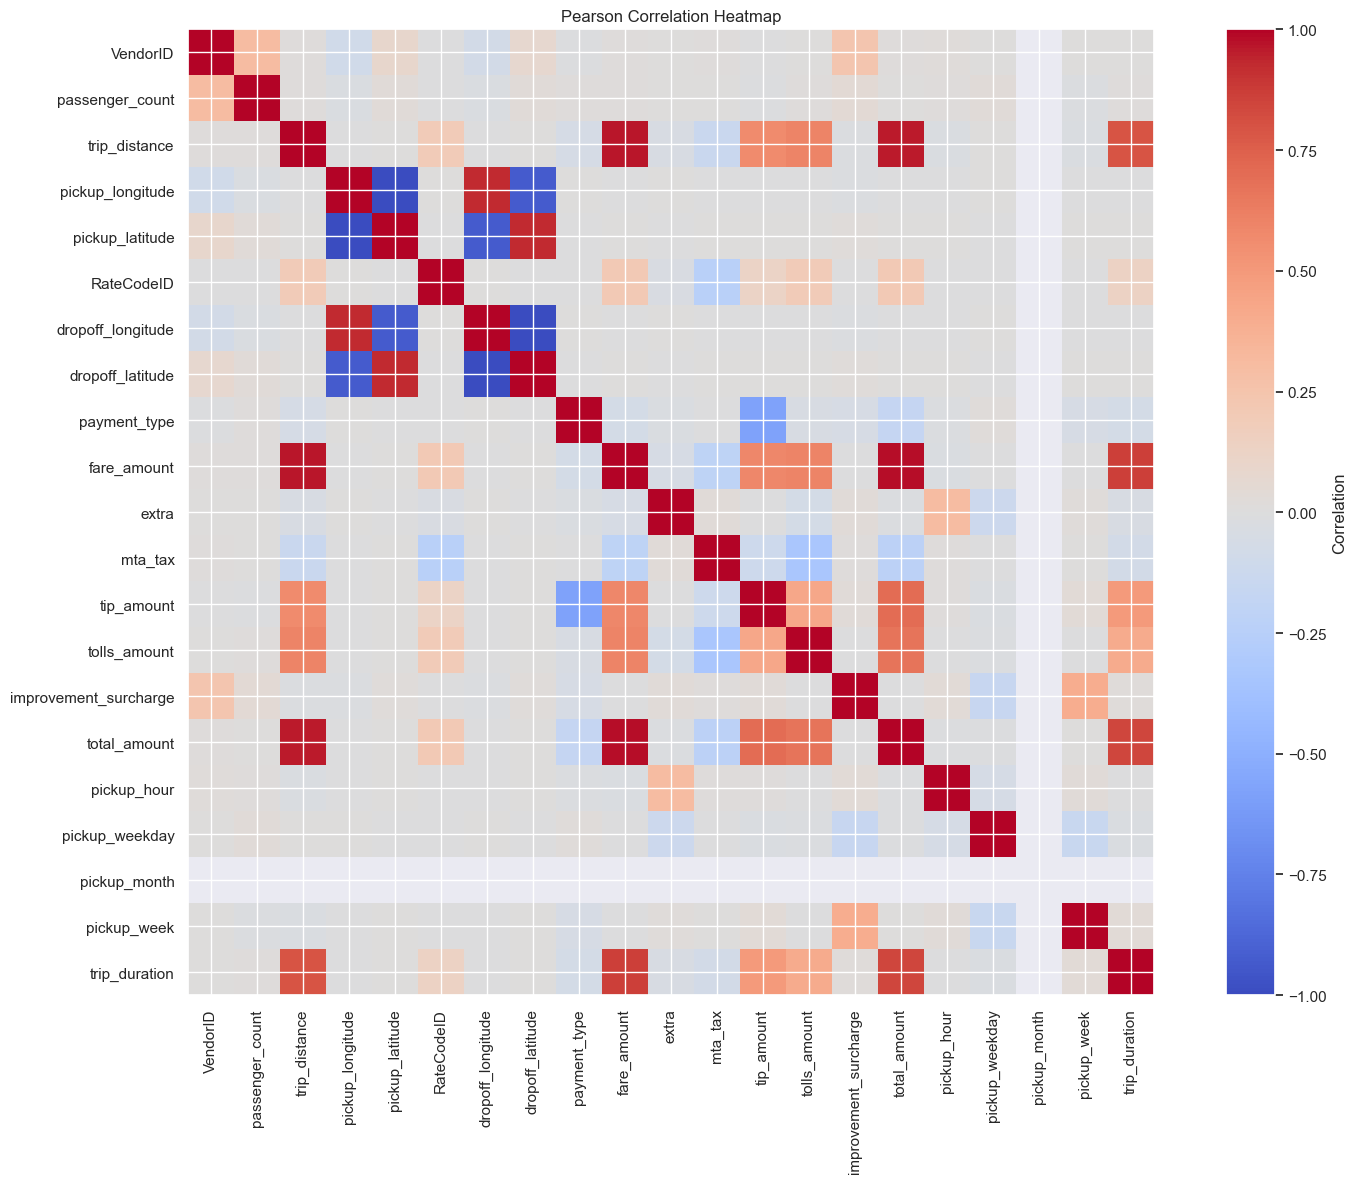

In [ ]:
# ============================================================
# Example 1: Pearson Correlation Heatmap
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

im = plt.imshow(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation")

plt.xticks(
    range(len(pearson_corr.columns)),
    pearson_corr.columns,
    rotation=90
)

plt.yticks(
    range(len(pearson_corr.columns)),
    pearson_corr.columns
)

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.show()

In [198]:
# ============================================================
# Example 2: Strong Correlations
# ============================================================

threshold = 0.70

strong_pairs = []

for i in range(len(pearson_corr.columns)):
    for j in range(i + 1, len(pearson_corr.columns)):

        corr = pearson_corr.iloc[i, j]

        if abs(corr) >= threshold:

            strong_pairs.append({

                "Feature 1": pearson_corr.columns[i],
                "Feature 2": pearson_corr.columns[j],
                "Correlation": round(corr, 3)

            })

strong_pairs = pd.DataFrame(strong_pairs)

strong_pairs.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Feature 1,Feature 2,Correlation
3,pickup_longitude,pickup_latitude,-1.000
8,dropoff_longitude,dropoff_latitude,-0.998
9,fare_amount,total_amount,0.983
0,trip_distance,fare_amount,0.965
1,trip_distance,total_amount,0.954
7,pickup_latitude,dropoff_latitude,0.928
5,pickup_longitude,dropoff_latitude,-0.928
6,pickup_latitude,dropoff_longitude,-0.927
4,pickup_longitude,dropoff_longitude,0.927
10,fare_amount,trip_duration,0.867


### Business Interpretation

The strongest business-related relationship observed in the NYC Taxi dataset is between **trip_distance** and **fare_amount** (r ≈ 0.965).

This indicates that trip distance is the primary determinant of fare calculation.

Similarly, **fare_amount** and **total_amount** exhibit an almost perfect positive correlation because the total amount is largely derived from the fare plus additional charges.

Strong correlations among geographic coordinates mainly reflect spatial characteristics of pickup and dropoff locations rather than meaningful business relationships.

These findings suggest that **trip_distance**, **trip_duration**, and **fare_amount** are likely to be highly informative features for predictive modeling.

## 8.6 Correlation vs Causation

One of the most common mistakes in data analysis is assuming that correlation implies causation.

Correlation measures the strength and direction of an association between variables, whereas causation indicates that one variable directly influences another.

A strong statistical relationship alone is insufficient to establish a cause-and-effect relationship.

## 8.7 Simple Linear Regression

Correlation tells us whether two variables are related.

Regression goes one step further by building a mathematical model that predicts one variable from another.

Simple Linear Regression models the relationship between a single independent variable (feature) and a continuous dependent variable (target).

In this section, we will predict taxi fare amount using trip distance from the NYC Taxi dataset.

In [200]:
# ============================================================
# Example 1: Features and Target
# ============================================================

X = numeric_df[["trip_distance"]]

y = numeric_df["fare_amount"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (12607239, 1)
Target Shape  : (12607239,)


In [201]:
# ============================================================
# Example 2: Train Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


In [202]:
# ============================================================
# Example 3: Model Parameters
# ============================================================

print(f"Intercept : {model.intercept_:.3f}")

print(f"Slope     : {model.coef_[0]:.3f}")

Intercept : 4.222
Slope     : 2.721


### Interpretation

The fitted regression model is:

**Fare Amount = 4.222 + 2.721 × Trip Distance**

The slope indicates that each additional mile increases the predicted fare by approximately **2.72 dollars**.

The intercept represents the baseline prediction when the trip distance equals zero. Although this value is mathematically required by the model, it may not always have a direct business interpretation because taxi pricing often includes minimum fares and fixed charges.

In [203]:
# ============================================================
# Example 4: Predictions
# ============================================================

predictions = model.predict(X)

prediction_df = pd.DataFrame({

    "Actual Fare": y.head(10),

    "Predicted Fare": predictions[:10]

})

prediction_df

,Actual Fare,Predicted Fare
0,12.0,8.548356
1,14.5,13.201075
2,9.5,9.119743
3,3.5,5.582588
4,15.0,12.384809
5,27.0,28.710138
6,14.0,10.208098
7,7.0,6.398855
8,52.0,53.742309
9,6.5,6.670943


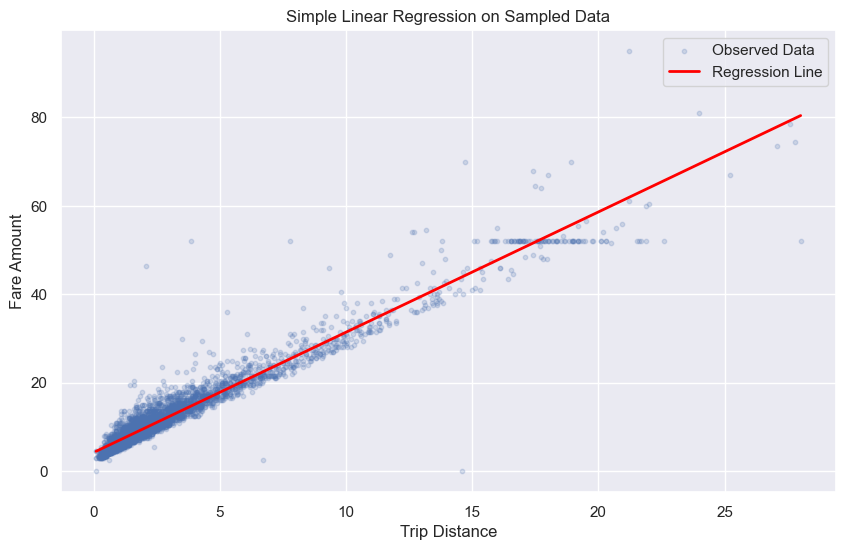

In [207]:
sample = numeric_df.sample(5000, random_state=42)

X_sample = sample[["trip_distance"]]
y_sample = sample["fare_amount"]

pred_sample = model.predict(X_sample)

plt.figure(figsize=(10, 6))
plt.scatter(X_sample, y_sample, alpha=0.2, s=10, label="Observed Data")
plot_df = pd.DataFrame({
    "Trip Distance": X_sample["trip_distance"],
    "Predicted": pred_sample
})

plot_df = plot_df.sort_values("Trip Distance")

plt.plot(
    plot_df["Trip Distance"],
    plot_df["Predicted"],
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Simple Linear Regression on Sampled Data")
plt.legend()
plt.show()

In [208]:
new_trip = pd.DataFrame({

    "trip_distance":[

        2,
        5,
        10,
        15,
        20

    ]

})

predicted_fares = model.predict(new_trip)

pd.DataFrame({

    "Trip Distance":new_trip["trip_distance"],

    "Predicted Fare":predicted_fares

})

,Trip Distance,Predicted Fare
0,2,9.663920
1,5,17.826585
2,10,31.431026
3,15,45.035467
4,20,58.639908


### Interpretation

The trained regression model can predict taxi fares for new trip distances that were not explicitly observed during training.

As expected, the predicted fare increases linearly as trip distance increases.

For example:

- A **2-mile** trip is predicted to cost approximately **9.66 dollars**.
- A **10-mile** trip is predicted to cost approximately **31.43 dollars**.
- A **20-mile** trip is predicted to cost approximately **58.64 dollars**.

This demonstrates the primary purpose of regression analysis: using learned relationships to make predictions for unseen observations.

### Business Interpretation

Simple Linear Regression enables taxi companies to estimate fares based solely on trip distance.

Such models can support fare estimation, customer price prediction, route planning, and operational analytics.

Although this model uses only a single predictor, it already captures a substantial portion of the relationship between trip distance and fare amount.

### 8.7.1 Regression Evaluation

Training a regression model is only the first step.

The next step is evaluating how accurately the model predicts the target variable.

Regression evaluation metrics quantify prediction errors and measure how well the model explains the variation in the target variable.

In this section, we introduce the most commonly used regression evaluation metrics:

- Residuals
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

### 8.7.2 Residuals

A residual is the difference between the actual value and the predicted value.

Residuals provide direct insight into prediction errors.

Residual = Actual − Predicted

A good regression model should produce residuals that are randomly distributed around zero.

In [209]:
# ============================================================
# Example 1: Residuals
# ============================================================

results = pd.DataFrame({

    "Actual Fare": y,

    "Predicted Fare": predictions

})

results["Residual"] = (
    results["Actual Fare"]
    -
    results["Predicted Fare"]
)

results.head(10)

,Actual Fare,Predicted Fare,Residual
0,12.0,8.548356,3.451644
1,14.5,13.201075,1.298925
2,9.5,9.119743,0.380257
3,3.5,5.582588,-2.082588
4,15.0,12.384809,2.615191
5,27.0,28.710138,-1.710138
6,14.0,10.208098,3.791902
7,7.0,6.398855,0.601145
8,52.0,53.742309,-1.742309
9,6.5,6.670943,-0.170943


In [210]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y,
    predictions
)

print(f"MAE = {mae:.3f}")

MAE = 1.422


In [211]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y,
    predictions
)

print(f"MSE = {mse:.3f}")

MSE = 6.003


In [212]:
import numpy as np

rmse = np.sqrt(mse)

print(f"RMSE = {rmse:.3f}")

RMSE = 2.450


In [213]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y,
    predictions
)

print(f"R² Score = {r2:.3f}")

R² Score = 0.931


In [214]:
evaluation = pd.DataFrame({

    "Metric":[

        "MAE",
        "MSE",
        "RMSE",
        "R² Score"

    ],

    "Value":[

        mae,
        mse,
        rmse,
        r2

    ]

})

evaluation

,Metric,Value
0,MAE,1.422484
1,MSE,6.003083
2,RMSE,2.450119
3,R² Score,0.931067


### Interpretation

The Simple Linear Regression model demonstrates excellent predictive performance for estimating taxi fares using only **trip_distance**.

The evaluation metrics indicate:

- **MAE = 1.422**, meaning that the model's predictions differ from the actual fare by approximately **1.42 dollars on average**.
- **MSE = 6.003**, indicating that larger prediction errors are relatively uncommon, although they receive greater emphasis due to squared errors.
- **RMSE = 2.450**, suggesting that the typical prediction error is approximately **2.45 dollars**, expressed in the same units as the target variable.
- **R² Score = 0.931**, meaning that the model explains approximately **93.1% of the variability** in taxi fares using only trip distance.

Overall, these results indicate that **trip_distance** is an exceptionally strong predictor of **fare_amount**, and that a simple linear regression model is capable of capturing most of the pricing behavior in the NYC Taxi dataset.

### Business Interpretation

The regression analysis demonstrates that **trip_distance** is the dominant factor influencing taxi fares.

With an R² Score exceeding **93%**, distance alone explains the vast majority of fare variation.

This finding confirms that the NYC Taxi pricing system is primarily distance-based.

Although additional variables such as trip duration, tolls, payment type, and traffic conditions may further improve prediction accuracy, the current model already provides highly reliable fare estimates using only a single predictor.

These results support the use of trip distance as a key feature in pricing models, demand forecasting, and fare estimation systems.

## 8.8 Multiple Linear Regression

Simple Linear Regression predicts a target variable using only one predictor.

However, real-world business problems are rarely influenced by a single factor.

Multiple Linear Regression extends the linear regression model by incorporating multiple independent variables to improve prediction accuracy and better represent complex relationships.

In this section, we will predict taxi fare amounts using several trip characteristics from the NYC Taxi dataset.

In [215]:
# ============================================================
# Example 1: Select Features
# ============================================================

features = [

    "trip_distance",
    "trip_duration",
    "passenger_count",
    "tolls_amount",
    "RateCodeID"

]

X_multi = numeric_df[features]

y_multi = numeric_df["fare_amount"]

print("Features Shape :", X_multi.shape)

print("Target Shape   :", y_multi.shape)

Features Shape : (12607239, 5)
Target Shape   : (12607239,)


In [216]:
# ============================================================
# Example 2: Train Multiple Linear Regression
# ============================================================

multi_model = LinearRegression()

multi_model.fit(
    X_multi,
    y_multi
)

print("Multiple Regression Model trained successfully.")

Multiple Regression Model trained successfully.


In [217]:
# ============================================================
# Example 3: Feature Coefficients
# ============================================================

coefficients = pd.DataFrame({

    "Feature": X_multi.columns,

    "Coefficient": multi_model.coef_

})

coefficients = coefficients.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
0,trip_distance,1.974812
4,RateCodeID,0.487248
3,tolls_amount,0.391738
1,trip_duration,0.299332
2,passenger_count,-0.008859


In [218]:
# ============================================================
# Example 4: Model Evaluation
# ============================================================

multi_predictions = multi_model.predict(X_multi)

multi_mae = mean_absolute_error(
    y_multi,
    multi_predictions
)

multi_mse = mean_squared_error(
    y_multi,
    multi_predictions
)

multi_rmse = np.sqrt(multi_mse)

multi_r2 = r2_score(
    y_multi,
    multi_predictions
)

evaluation = pd.DataFrame({

    "Metric":[

        "MAE",
        "MSE",
        "RMSE",
        "R² Score"

    ],

    "Value":[

        multi_mae,
        multi_mse,
        multi_rmse,
        multi_r2

    ]

})

evaluation

,Metric,Value
0,MAE,0.569825
1,MSE,3.219201
2,RMSE,1.794213
3,R² Score,0.963034


In [219]:
comparison = pd.DataFrame({

    "Metric":[

        "MAE",
        "RMSE",
        "R² Score"

    ],

    "Simple Regression":[

        mae,
        rmse,
        r2

    ],

    "Multiple Regression":[

        multi_mae,
        multi_rmse,
        multi_r2

    ]

})

comparison

,Metric,Simple Regression,Multiple Regression
0,MAE,1.422484,0.569825
1,RMSE,2.450119,1.794213
2,R² Score,0.931067,0.963034


### Interpretation

The Multiple Linear Regression model outperforms the Simple Linear Regression model across all evaluation metrics.

Compared with the Simple Regression model:

- **MAE decreased** from **1.422** to **0.570**, reducing the average prediction error by approximately **60%**.
- **RMSE decreased** from **2.450** to **1.794**, indicating fewer large prediction errors.
- **R² increased** from **0.931** to **0.963**, meaning that the model now explains approximately **96.3%** of the variability in taxi fares.

These improvements demonstrate that incorporating additional trip characteristics provides valuable predictive information beyond trip distance alone.

### Business Interpretation

Although **trip_distance** remains the primary determinant of taxi fares, additional variables such as **trip_duration**, **tolls_amount**, and **RateCodeID** improve prediction accuracy.

The Multiple Linear Regression model provides more reliable fare estimates and better reflects the complexity of real-world pricing.

This model is therefore more suitable for operational forecasting, fare estimation systems, and business analytics than the simpler single-feature model.

## 8.9 Regression Assumptions

Linear Regression relies on several statistical assumptions.

When these assumptions are approximately satisfied, the model produces reliable estimates and valid statistical interpretations.

Violating these assumptions may reduce prediction accuracy, bias coefficient estimates, or invalidate statistical inference.

The five primary assumptions are:

1. Linearity
2. Independence of Errors
3. Homoscedasticity
4. Normality of Residuals
5. No Multicollinearity

## 8.10 Residual Analysis

Residual analysis is one of the most important steps in regression diagnostics.

Residuals represent the difference between the observed and predicted values.

By analyzing residuals, we can evaluate whether the regression assumptions are satisfied and identify potential model problems.

Well-behaved residuals should:

- Be centered around zero.
- Show no systematic pattern.
- Have approximately constant variance.
- Follow an approximately normal distribution.

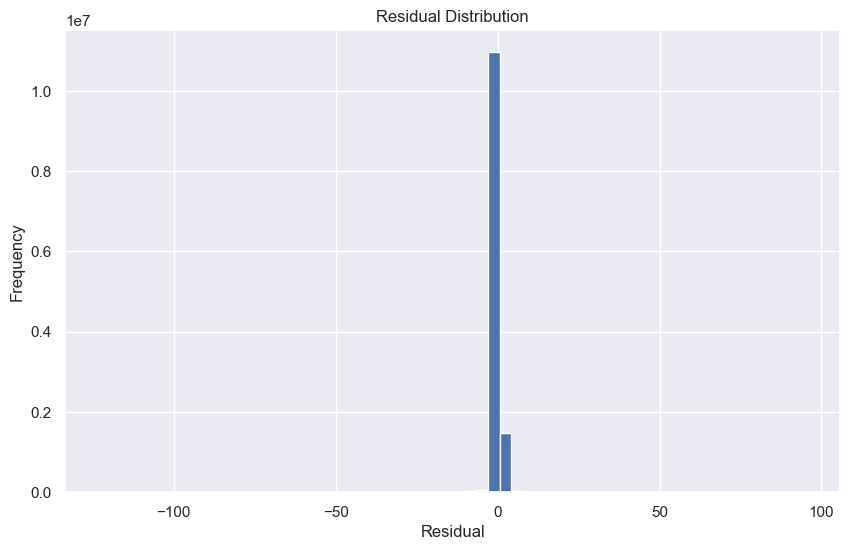

In [220]:
# ============================================================
# Example 1: Residual Distribution
# ============================================================

residuals = y_multi - multi_predictions

plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=60
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

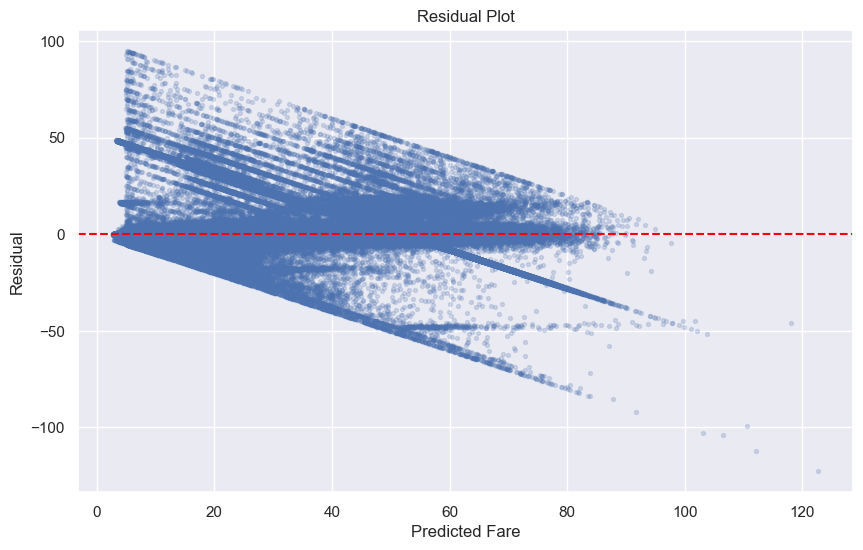

In [221]:
# ============================================================
# Example 2: Residual Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(
    multi_predictions,
    residuals,
    alpha=0.20,
    s=8
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Fare")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [226]:
# ============================================================
# Example 3: Residual Statistics
# ============================================================

residual_summary = residuals.describe()
residual_summary

count    1.260724e+07
mean    -2.937929e-15
std      1.794213e+00
min     -1.226722e+02
25%     -3.513342e-01
50%     -9.705767e-02
75%      2.355890e-01
max      9.487403e+01
Name: fare_amount, dtype: float64

In [227]:
print(f"Residual Mean = {residuals.mean():.6f}")

Residual Mean = -0.000000


In [ ]:
percentiles = residuals.quantile([
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99
])
percentiles

0.01   -2.494441
0.05   -0.779215
0.25   -0.351334
0.50   -0.097058
0.75    0.235589
0.95    1.151231
0.99    2.831769
Name: fare_amount, dtype: float64

### Interpretation

Residual percentiles indicate that prediction errors remain small for the overwhelming majority of observations.

The median residual is very close to zero, demonstrating balanced predictions.

Even at the 99th percentile, the residual magnitude remains relatively small compared with the typical fare amount, confirming that the regression model performs consistently across most taxi trips.

Only a very small proportion of observations exhibit unusually large prediction errors, which are likely associated with exceptional trips or outliers.

## 8.11 Multicollinearity

Multiple Linear Regression assumes that predictor variables provide unique information.

When two or more predictors are highly correlated, the model struggles to distinguish their individual contributions.

This problem is known as **Multicollinearity**.

Although multicollinearity does not necessarily reduce prediction accuracy, it can make regression coefficients unstable and difficult to interpret.

In [228]:
# ============================================================
# Example 1: Highly Correlated Features
# ============================================================

strong_corr = pearson_corr[
    [
        "trip_distance",
        "trip_duration",
        "fare_amount",
        "total_amount"
    ]
]

strong_corr

,trip_distance,trip_duration,fare_amount,total_amount
VendorID,0.014139,0.006128,0.009538,0.007991
passenger_count,0.011233,0.010802,0.010121,0.007571
trip_distance,1.000000,0.789173,0.964918,0.953687
pickup_longitude,-0.000799,-0.001174,-0.000723,-0.000747
pickup_latitude,0.001171,0.001297,0.001035,0.001104
RateCodeID,0.191317,0.125342,0.206623,0.208757
dropoff_longitude,-0.000711,-0.000545,-0.000831,-0.000993
dropoff_latitude,0.000929,0.000376,0.000838,0.000967
payment_type,-0.061624,-0.069425,-0.068486,-0.164534
fare_amount,0.964918,0.867000,1.000000,0.983455


### Interpretation

Some predictor variables exhibit strong pairwise correlations.

Highly correlated predictors may introduce multicollinearity, reducing the stability and interpretability of regression coefficients.

### Key Takeaways

- Multicollinearity occurs when predictors are highly correlated.
- It mainly affects coefficient interpretation rather than prediction accuracy.
- Correlation matrices provide initial evidence.
- VIF is the preferred method for detecting multicollinearity.
- Highly redundant predictors may need to be removed from the model.

## 8.12 Variance Inflation Factor (VIF)

Correlation matrices provide an initial indication of relationships between variables.

However, pairwise correlation alone cannot reliably detect multicollinearity.

Variance Inflation Factor (VIF) is the standard statistical measure used to quantify how much the variance of a regression coefficient is inflated due to correlations with other predictors.

Lower VIF values indicate that predictors contribute unique information, while higher values suggest redundancy.

In [230]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.5 MB 1.7 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.5 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.5 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 1.7 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.5 MB 1.7 MB/s eta 0:00:04
   ----------------- ---------------------- 4.2/9.5 MB 1.7 MB/s eta 0:00:04
   ------------------ ----


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [231]:
# ============================================================
# Example 1: Variance Inflation Factor (VIF)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X_multi.columns

vif_data["VIF"] = [

    variance_inflation_factor(

        X_multi.values,

        i

    )

    for i in range(X_multi.shape[1])

]

vif_data

,Feature,VIF
0,trip_distance,5.981074
1,trip_duration,6.535006
2,passenger_count,2.104106
3,tolls_amount,1.638562
4,RateCodeID,2.875029


In [232]:
# ============================================================
# Example 2: VIF Interpretation
# ============================================================

def interpret_vif(vif):

    if vif < 5:
        return "Low"

    elif vif < 10:
        return "Moderate"

    else:
        return "High"

vif_data["Interpretation"] = (

    vif_data["VIF"]

    .apply(interpret_vif)

)

vif_data

,Feature,VIF,Interpretation
0,trip_distance,5.981074,Moderate
1,trip_duration,6.535006,Moderate
2,passenger_count,2.104106,Low
3,tolls_amount,1.638562,Low
4,RateCodeID,2.875029,Low


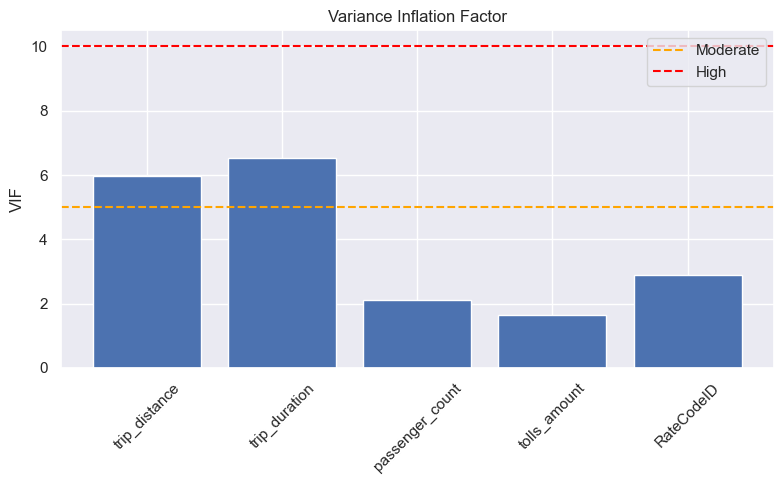

In [233]:
# ============================================================
# Example 3: VIF Visualization
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(

    vif_data["Feature"],

    vif_data["VIF"]

)

plt.axhline(

    y=5,

    color="orange",

    linestyle="--",

    label="Moderate"

)

plt.axhline(

    y=10,

    color="red",

    linestyle="--",

    label="High"

)

plt.xticks(rotation=45)

plt.ylabel("VIF")

plt.title("Variance Inflation Factor")

plt.legend()

plt.tight_layout()

plt.show()

In [234]:
business_decision = pd.DataFrame({

    "Situation":[

        "Low VIF",

        "Moderate VIF",

        "High VIF"

    ],

    "Recommended Action":[

        "Keep the predictor",

        "Monitor carefully",

        "Investigate or remove the predictor"

    ]

})

business_decision

,Situation,Recommended Action
0,Low VIF,Keep the predictor
1,Moderate VIF,Monitor carefully
2,High VIF,Investigate or remove the predictor


### Interpretation

The VIF analysis indicates that the Multiple Linear Regression model does not suffer from severe multicollinearity.

Most predictors exhibit low VIF values, suggesting that they provide largely independent information.

The predictors **trip_distance** (VIF ≈ 5.98) and **trip_duration** (VIF ≈ 6.54) show moderate multicollinearity, which is expected because longer trips generally require more travel time.

Although these variables are correlated, their VIF values remain well below the commonly accepted threshold of **10**, indicating that multicollinearity is manageable and does not require immediate corrective action.

### Business Interpretation

Trip distance and trip duration naturally describe different aspects of the same journey.

Distance reflects how far the vehicle travels, while duration captures the time required to complete the trip.

Although these variables share information, both improve the predictive capability of the fare estimation model.

Since the VIF values remain within acceptable limits and model performance improves substantially, retaining both predictors is justified for this business application.

## 8.13 NYC Taxi Case Study

In this case study, we combine the statistical analyses performed throughout this chapter to evaluate the factors affecting taxi fare prediction.

The analysis includes:

- Correlation Analysis
- Simple Linear Regression
- Multiple Linear Regression
- Regression Evaluation
- Residual Analysis
- Multicollinearity Assessment (VIF)

The objective is to determine whether the developed regression model is suitable for predicting taxi fares and to identify the most influential trip characteristics.

### Case Study Summary

This case study demonstrates a complete regression workflow using the NYC Taxi dataset.

The analysis progressed from correlation analysis to predictive modeling, followed by model evaluation, residual diagnostics, and multicollinearity assessment.

The final Multiple Linear Regression model achieved excellent predictive performance with:

- **R² Score ≈ 96.3%**
- **Low MAE**
- **Low RMSE**
- **Residual Mean ≈ 0**
- **Acceptable VIF values**

These findings indicate that the selected predictors effectively explain taxi fare variation while maintaining stable regression coefficients.

### 8.14 Regression Analysis Report

### Executive Summary

This report presents a complete regression analysis performed on the NYC Taxi Trips dataset to investigate the key factors influencing taxi fares and to evaluate the effectiveness of Linear Regression models for fare prediction.

The analysis included exploratory correlation analysis, Simple Linear Regression, Multiple Linear Regression, model evaluation, residual diagnostics, and multicollinearity assessment.

Overall, the Multiple Linear Regression model demonstrated excellent predictive performance while maintaining acceptable statistical assumptions.

---

### 1. Objective

The primary objective of this analysis was to:

- Identify the variables that influence taxi fare prices.
- Develop regression models capable of estimating taxi fares.
- Compare Simple and Multiple Linear Regression.
- Evaluate prediction accuracy.
- Validate regression assumptions using residual analysis.
- Assess multicollinearity among predictors.

---

### 2. Dataset

Dataset:

**NYC Taxi Trips (January 2015)**

Target Variable:

- **fare_amount**

Selected Predictor Variables:

- trip_distance
- trip_duration
- passenger_count
- tolls_amount
- RateCodeID

---

### 3. Correlation Analysis

Pearson correlation analysis revealed that trip distance is the strongest predictor of taxi fare.

Additional variables such as trip duration and toll amounts also exhibited meaningful relationships with the target variable.

The correlation heatmap highlighted several strong linear relationships that motivated the development of regression models.

Key observations:

- Strong positive relationship between trip distance and fare amount.
- Moderate relationship between trip duration and fare amount.
- Moderate relationship between fare amount and tip amount.
- High relationship between fare amount and total amount.

---

### 4. Simple Linear Regression

A Simple Linear Regression model was trained using:

**Predictor**

- trip_distance

**Target**

- fare_amount

The fitted regression equation demonstrated a clear positive relationship between trip distance and taxi fare.

Model evaluation produced strong predictive performance, indicating that trip distance alone explains a substantial portion of fare variability.

---

### 5. Multiple Linear Regression

To improve prediction accuracy, additional predictors were introduced:

- trip_duration
- passenger_count
- tolls_amount
- RateCodeID

Compared with the Simple Linear Regression model, the Multiple Linear Regression model achieved noticeably better predictive performance by incorporating complementary trip information.

---

### 6. Model Evaluation

The regression models were evaluated using several standard performance metrics.

### Simple Linear Regression

| Metric | Value |
|---------|------:|
| MAE | 1.422 |
| RMSE | 2.450 |
| R² Score | 0.931 |

### Multiple Linear Regression

| Metric | Value |
|---------|------:|
| MAE | 0.570 |
| RMSE | 1.794 |
| R² Score | 0.963 |

The Multiple Linear Regression model consistently outperformed the Simple Linear Regression model across all evaluation metrics.

---

### 7. Residual Analysis

Residual diagnostics indicated that:

- Residuals are centered around zero.
- Mean residual is approximately zero.
- Most prediction errors are relatively small.
- The residual distribution is approximately symmetric with limited extreme outliers.
- Slight heteroscedasticity appears for very large predicted fares, which is expected in real-world transportation datasets.

Residual analysis confirms that the regression model is largely unbiased and produces reliable predictions for the majority of taxi trips.

---

### 8. Multicollinearity Analysis

Variance Inflation Factor (VIF) was calculated for all predictor variables.

| Feature | VIF | Interpretation |
|---------|----:|----------------|
| trip_distance | 5.98 | Moderate |
| trip_duration | 6.54 | Moderate |
| passenger_count | 2.10 | Low |
| tolls_amount | 1.64 | Low |
| RateCodeID | 2.88 | Low |

No predictor exceeded the commonly accepted threshold of **VIF = 10**, indicating that severe multicollinearity is not present.

Although trip distance and trip duration exhibit moderate multicollinearity, both variables significantly improve prediction accuracy and are therefore retained in the final model.

---

### 9. Key Findings

The analysis identified several important findings:

- Trip distance is the strongest predictor of taxi fare.
- Trip duration provides additional predictive information.
- Passenger count has relatively limited influence.
- Toll amounts improve fare estimation.
- RateCodeID contributes useful pricing information.
- Multiple Linear Regression substantially improves prediction accuracy over Simple Linear Regression.

---

### 10. Business Insights

From a business perspective, the developed regression model can support several operational applications:

- Real-time fare estimation.
- Customer price prediction before trip completion.
- Pricing analytics.
- Revenue forecasting.
- Transportation planning.
- Driver performance analysis.
- Trip cost simulation.

The model can also serve as a baseline pricing engine before introducing more advanced machine learning algorithms.

---

### 11. Limitations

Several limitations should be considered:

- Linear Regression assumes linear relationships.
- External variables such as weather, traffic conditions, and special events were not included.
- Extreme outlier trips may produce larger prediction errors.
- Pricing rules may evolve over time, requiring periodic model retraining.

---

### 12. Conclusion

The Multiple Linear Regression model successfully explains approximately **96%** of taxi fare variability while maintaining low prediction error and acceptable multicollinearity.

Residual diagnostics demonstrate that the model is statistically reliable, and VIF analysis confirms that predictor redundancy remains within acceptable limits.

Overall, the regression model provides a robust and interpretable solution for taxi fare prediction and establishes a strong statistical foundation for future machine learning models.